### Relevant old-vs-new post-pre effect

$$
C_{\mathrm{rel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

### Irrelevant old-vs-new post-pre effect

$$
C_{\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

### Difference between relevant and irrelevant old-vs-new effects

$$
C_{\mathrm{rel-vs-new>irrel-vs-new}}
=
C_{\mathrm{rel-vs-new}} - C_{\mathrm{irrel-vs-new}}.
$$

Expanded:

$$
C_{\mathrm{rel-vs-new>irrel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}}).
$$

In [1]:
# ============================================================
# 1. Setup: relevance-split old/new pre-post GLM
# ============================================================

from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn.image import load_img, resample_to_img
from nilearn.datasets import load_mni152_template
from nilearn.plotting import plot_design_matrix, plot_stat_map
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm.second_level import SecondLevelModel
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.glm.thresholding import threshold_stats_img
from nilearn.reporting import get_clusters_table

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
DATA_DIR = PROJECT_ROOT / "data"

BIDS_DIR = DATA_DIR / "bids_ackbar"
FMRIPREP_DIR = DATA_DIR / "fmriprep_output"

# Previous validated old/new analysis
OLD_NEW_ANALYSIS_NAME = "pre_post_old_new_viewing_glm"
OLD_NEW_OUT_DIR = DATA_DIR / "processed" / "glm" / OLD_NEW_ANALYSIS_NAME
OLD_NEW_EVENTS_DIR = DATA_DIR / "preprocessed" / "relabeled_events_pre_post_old_new"
OLD_NEW_TABLE_DIR = OLD_NEW_OUT_DIR / "tables"
OLD_NEW_RESTART_DIR = OLD_NEW_OUT_DIR / "restart"

old_new_manifest_path = (
    OLD_NEW_RESTART_DIR
    / f"{OLD_NEW_ANALYSIS_NAME}_restart_manifest.json"
)

assert old_new_manifest_path.exists(), f"Missing old/new manifest: {old_new_manifest_path}"

with open(old_new_manifest_path, "r") as f:
    old_new_manifest = json.load(f)

subjects = old_new_manifest["subjects"]

print("Loaded old/new manifest:")
print(old_new_manifest_path)
print("N subjects:", len(subjects))
print("Previous main contrast:", old_new_manifest["main_contrast"])

# ------------------------------------------------------------
# New relevance-split analysis
# ------------------------------------------------------------

ANALYSIS_NAME = "pre_post_relevance_old_new_viewing_glm"

OUT_DIR = DATA_DIR / "processed" / "glm" / ANALYSIS_NAME
EVENTS_DIR = DATA_DIR / "preprocessed" / "relabeled_events_pre_post_relevance_old_new"

FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
QC_DIR = OUT_DIR / "qc"

for path in [
    OUT_DIR,
    EVENTS_DIR,
    FIG_DIR,
    TABLE_DIR,
    QC_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

PRE_SESSION = "ses-01"
POST_SESSION = "ses-05"
VIEWING_TASK = "viewing"
VIEWING_RUN = "01"
BOLD_SPACE = "MNI152NLin2009cAsym"

SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"

FIRST_LEVEL_DIR = OUT_DIR / f"first_level_{SMOOTHING_LABEL}"
FIRST_LEVEL_MAPS_DIR = FIRST_LEVEL_DIR / "maps"
FIRST_LEVEL_DESIGN_DIR = FIRST_LEVEL_DIR / "design_matrices"
FIRST_LEVEL_FIG_DIR = FIRST_LEVEL_DIR / "figures"

SECOND_LEVEL_DIR = OUT_DIR / f"second_level_from_{SMOOTHING_LABEL}"
SECOND_LEVEL_MAPS_DIR = SECOND_LEVEL_DIR / "maps"
SECOND_LEVEL_FIG_DIR = SECOND_LEVEL_DIR / "figures"

for path in [
    FIRST_LEVEL_DIR,
    FIRST_LEVEL_MAPS_DIR,
    FIRST_LEVEL_DESIGN_DIR,
    FIRST_LEVEL_FIG_DIR,
    SECOND_LEVEL_DIR,
    SECOND_LEVEL_MAPS_DIR,
    SECOND_LEVEL_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("\nNew analysis output:")
print(OUT_DIR)

Loaded old/new manifest:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/restart/pre_post_old_new_viewing_glm_restart_manifest.json
N subjects: 27
Previous main contrast: old_gt_new_post_gt_pre

New analysis output:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm


In [2]:
# ============================================================
# 2. Helper paths
# ============================================================

def get_old_new_events_path(subject):
    """
    Previous validated old/new event file from notebook 09.
    """
    return OLD_NEW_EVENTS_DIR / f"{subject}_task-{VIEWING_TASK}_pre_post_old_new_events.tsv"


def get_relevance_old_new_events_path(subject):
    """
    New relevance-split event file.
    """
    return EVENTS_DIR / f"{subject}_task-{VIEWING_TASK}_pre_post_relevance_old_new_events.tsv"


def get_bold_file(subject, session, run=VIEWING_RUN, space=BOLD_SPACE):
    return (
        FMRIPREP_DIR
        / subject
        / session
        / "func"
        / f"{subject}_{session}_task-{VIEWING_TASK}_run-{run}_space-{space}_desc-preproc_bold.nii.gz"
    )


def get_first_level_z_map_path(subject, contrast_name):
    return (
        FIRST_LEVEL_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
    )


def get_first_level_effect_map_path(subject, contrast_name):
    return (
        FIRST_LEVEL_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
    )


def get_group_z_map_path(contrast_name):
    return (
        SECOND_LEVEL_MAPS_DIR
        / f"group_pre_post_relevance_old_new_{contrast_name}_from_{SMOOTHING_LABEL}_zmap.nii.gz"
    )


def get_group_effect_map_path(contrast_name):
    return (
        SECOND_LEVEL_MAPS_DIR
        / f"group_pre_post_relevance_old_new_{contrast_name}_from_{SMOOTHING_LABEL}_effect.nii.gz"
    )


def infer_tr_from_bold(bold_path):
    img = nib.load(str(bold_path))
    return float(img.header.get_zooms()[3])


# Quick checks
for subject in subjects[:3]:
    print(subject)
    print("  old/new events:", get_old_new_events_path(subject).exists())
    print("  pre BOLD:", get_bold_file(subject, PRE_SESSION).exists())
    print("  post BOLD:", get_bold_file(subject, POST_SESSION).exists())

assert all(get_old_new_events_path(subject).exists() for subject in subjects)

sub-P10
  old/new events: True
  pre BOLD: True
  post BOLD: True
sub-P12
  old/new events: True
  pre BOLD: True
  post BOLD: True
sub-P13
  old/new events: True
  pre BOLD: True
  post BOLD: True


In [3]:
# ============================================================
# 3. Explicit relevance-split design and contrast definitions
# ============================================================

DESIGN_DESCRIPTION = """
Relevance-split old/new pre-post first-level GLM
================================================

This analysis extends the validated old/new pre-post GLM.

Previous model:
    pre_old, pre_new, post_old, post_new

New model:
    pre_oldRel, pre_oldIrrel, pre_new
    post_oldRel, post_oldIrrel, post_new

Run 1 = pre-viewing, ses-01
Run 2 = post-viewing, ses-05

New images remain a neutral control baseline.
Old images are split according to whether they were goal-relevant or goal-irrelevant
during the island task.
"""

print(DESIGN_DESCRIPTION)


RELEVANCE_CONTRASTS = {
    # Main relevance-specific old-vs-new effects
    "rel_old_vs_new_post_gt_pre": {
        "post_oldRel": +1.0,
        "pre_oldRel": -1.0,
        "post_new": -1.0,
        "pre_new": +1.0,
    },
    
    "irrel_old_vs_new_post_gt_pre": {
        "post_oldIrrel": +1.0,
        "pre_oldIrrel": -1.0,
        "post_new": -1.0,
        "pre_new": +1.0,
    },
    
    # Difference between the two old-vs-new effects.
    # The new baseline cancels algebraically, but these two effects
    # should still be interpreted as rel-vs-new > irrel-vs-new.
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre": {
        "post_oldRel": +1.0,
        "pre_oldRel": -1.0,
        "post_oldIrrel": -1.0,
        "pre_oldIrrel": +1.0,
    },
    
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre": {
        "post_oldIrrel": +1.0,
        "pre_oldIrrel": -1.0,
        "post_oldRel": -1.0,
        "pre_oldRel": +1.0,
    },
    
    # Descriptive old-only post-pre effects
    "oldRel_post_gt_pre": {
        "post_oldRel": +1.0,
        "pre_oldRel": -1.0,
    },
    
    "oldIrrel_post_gt_pre": {
        "post_oldIrrel": +1.0,
        "pre_oldIrrel": -1.0,
    },
    
    # Post-only old-vs-new descriptive checks
    "post_oldRel_gt_new": {
        "post_oldRel": +1.0,
        "post_new": -1.0,
    },
    
    "post_oldIrrel_gt_new": {
        "post_oldIrrel": +1.0,
        "post_new": -1.0,
    },
    
    # Pre-only old-vs-new baseline checks
    "pre_oldRel_gt_new": {
        "pre_oldRel": +1.0,
        "pre_new": -1.0,
    },
    
    "pre_oldIrrel_gt_new": {
        "pre_oldIrrel": +1.0,
        "pre_new": -1.0,
    },
}


CONTRAST_PRIORITY = {
    "rel_old_vs_new_post_gt_pre": "primary_relevance_specific",
    "irrel_old_vs_new_post_gt_pre": "primary_relevance_specific",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre": "primary_interaction",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre": "reverse_interaction",
    "oldRel_post_gt_pre": "descriptive_old_post_pre",
    "oldIrrel_post_gt_pre": "descriptive_old_post_pre",
    "post_oldRel_gt_new": "descriptive_post_only",
    "post_oldIrrel_gt_new": "descriptive_post_only",
    "pre_oldRel_gt_new": "baseline_pre_only",
    "pre_oldIrrel_gt_new": "baseline_pre_only",
}


CONTRAST_FORMULAS = {
    "rel_old_vs_new_post_gt_pre": (
        r"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})"
        r"-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$$"
    ),
    "irrel_old_vs_new_post_gt_pre": (
        r"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})"
        r"-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$$"
    ),
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre": (
        r"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})"
        r"-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})]"
        r"-[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})"
        r"-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})]$$"
    ),
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre": (
        r"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})"
        r"-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})]"
        r"-[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})"
        r"-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})]$$"
    ),
    "oldRel_post_gt_pre": (
        r"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}}$$"
    ),
    "oldIrrel_post_gt_pre": (
        r"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}}$$"
    ),
    "post_oldRel_gt_new": (
        r"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{post,new}}$$"
    ),
    "post_oldIrrel_gt_new": (
        r"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{post,new}}$$"
    ),
    "pre_oldRel_gt_new": (
        r"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{pre,new}}$$"
    ),
    "pre_oldIrrel_gt_new": (
        r"$$\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm{pre,new}}$$"
    ),
}


contrast_rows = []

for contrast_name, weights in RELEVANCE_CONTRASTS.items():
    row = {
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "pre_oldRel": weights.get("pre_oldRel", 0.0),
        "pre_oldIrrel": weights.get("pre_oldIrrel", 0.0),
        "pre_new": weights.get("pre_new", 0.0),
        "post_oldRel": weights.get("post_oldRel", 0.0),
        "post_oldIrrel": weights.get("post_oldIrrel", 0.0),
        "post_new": weights.get("post_new", 0.0),
    }
    contrast_rows.append(row)

contrast_table = pd.DataFrame(contrast_rows)

display(contrast_table)

contrast_table_path = TABLE_DIR / "pre_post_relevance_old_new_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

print("Saved:", contrast_table_path)


Relevance-split old/new pre-post first-level GLM

This analysis extends the validated old/new pre-post GLM.

Previous model:
    pre_old, pre_new, post_old, post_new

New model:
    pre_oldRel, pre_oldIrrel, pre_new
    post_oldRel, post_oldIrrel, post_new

Run 1 = pre-viewing, ses-01
Run 2 = post-viewing, ses-05

New images remain a neutral control baseline.
Old images are split according to whether they were goal-relevant or goal-irrelevant
during the island task.



,contrast,priority,formula,pre_oldRel,pre_oldIrrel,pre_new,post_oldRel,post_oldIrrel,post_new
0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",-1.0,0.0,1.0,1.0,0.0,-1.0
1,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",0.0,-1.0,1.0,0.0,1.0,-1.0
2,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",-1.0,1.0,0.0,1.0,-1.0,0.0
3,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",1.0,-1.0,0.0,-1.0,1.0,0.0
4,oldRel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{...",-1.0,0.0,0.0,1.0,0.0,0.0
5,oldIrrel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",0.0,-1.0,0.0,0.0,1.0,0.0
6,post_oldRel_gt_new,descriptive_post_only,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{...",0.0,0.0,0.0,1.0,0.0,-1.0
7,post_oldIrrel_gt_new,descriptive_post_only,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",0.0,0.0,0.0,0.0,1.0,-1.0
8,pre_oldRel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{p...",1.0,0.0,-1.0,0.0,0.0,0.0
9,pre_oldIrrel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm...",0.0,1.0,-1.0,0.0,0.0,0.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_contrast_definitions.csv



# Relevance-split old/new pre-post GLM

This analysis extends the validated old/new pre-post model by splitting old images according to their goal relevance during the island task.

The first-level regressors are:

$$
\beta_{\mathrm{pre,oldRel}},\quad
\beta_{\mathrm{pre,oldIrrel}},\quad
\beta_{\mathrm{pre,new}},\quad
\beta_{\mathrm{post,oldRel}},\quad
\beta_{\mathrm{post,oldIrrel}},\quad
\beta_{\mathrm{post,new}}.
$$

The relevant old-vs-new post-pre effect is:

$$
C_{\mathrm{rel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

The irrelevant old-vs-new post-pre effect is:

$$
C_{\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

To test whether the relevant old-vs-new effect is stronger than the irrelevant old-vs-new effect, we compute:

$$
C_{\mathrm{rel-vs-new}>\mathrm{irrel-vs-new}}
=
C_{\mathrm{rel-vs-new}} - C_{\mathrm{irrel-vs-new}}.
$$

Expanded:

$$
C_{\mathrm{rel-vs-new}>\mathrm{irrel-vs-new}}
=
\left[
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})
\right]
-
\left[
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})
\right].
$$

Because the same new-image baseline is used in both terms, the new-image component cancels algebraically:

$$
C_{\mathrm{rel-vs-new}>\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}}).
$$

Thus, new images are central for defining the two relevance-specific old-vs-new effects, even though the new-image term cancels in the final relevant-versus-irrelevant comparison.

In [5]:
# ============================================================
# 5. Classify previous old/new events into oldRel / oldIrrel / new
# ============================================================

def classify_relevance_old_new_from_filename(image_file):
    """
    Classify each image into:
    - new
    - oldRel
    - oldIrrel
    
    Expected examples:
        maya_3_e3_6_r_h_v1_old.jpg      -> oldRel
        wealth_5_e3_7_nr_o_v1_old.jpg   -> oldIrrel
        viking_11_new.jpg                -> new
    
    Important:
    Check '_nr_' before '_r_' to avoid misclassifying irrelevant images
    as relevant.
    """
    image_file = str(image_file)
    
    if "_new" in image_file:
        return "new"
    
    if "_old" in image_file:
        if "_nr_" in image_file:
            return "oldIrrel"
        if "_r_" in image_file:
            return "oldRel"
    
    return "unclassified"


def make_relevance_trial_type(phase, relevance_old_new):
    """
    Convert phase and category to GLM trial_type.
    """
    if phase == "pre" and relevance_old_new == "oldRel":
        return "pre_oldRel"
    if phase == "pre" and relevance_old_new == "oldIrrel":
        return "pre_oldIrrel"
    if phase == "pre" and relevance_old_new == "new":
        return "pre_new"
    
    if phase == "post" and relevance_old_new == "oldRel":
        return "post_oldRel"
    if phase == "post" and relevance_old_new == "oldIrrel":
        return "post_oldIrrel"
    if phase == "post" and relevance_old_new == "new":
        return "post_new"
    
    return "unclassified"


# ------------------------------------------------------------
# Test classifier on examples
# ------------------------------------------------------------

test_names = [
    "maya_3_e3_6_r_h_v1_old.jpg",
    "wealth_5_e3_7_nr_o_v1_old.jpg",
    "viking_11_new.jpg",
]

for name in test_names:
    print(name, "->", classify_relevance_old_new_from_filename(name))

assert classify_relevance_old_new_from_filename("maya_3_e3_6_r_h_v1_old.jpg") == "oldRel"
assert classify_relevance_old_new_from_filename("wealth_5_e3_7_nr_o_v1_old.jpg") == "oldIrrel"
assert classify_relevance_old_new_from_filename("viking_11_new.jpg") == "new"

maya_3_e3_6_r_h_v1_old.jpg -> oldRel
wealth_5_e3_7_nr_o_v1_old.jpg -> oldIrrel
viking_11_new.jpg -> new


In [6]:
# ============================================================
# 6. Build relevance-split event files from previous old/new event files
# ============================================================

all_relevance_events = []
event_qc_rows = []
identity_qc_rows = []

for subject in subjects:
    old_new_path = get_old_new_events_path(subject)
    assert old_new_path.exists(), f"Missing old/new events: {old_new_path}"
    
    events = pd.read_csv(old_new_path, sep="\t")
    
    required_cols = [
        "onset",
        "duration",
        "image_file",
        "phase",
        "session",
        "run",
        "trial_type",
        "modulation",
    ]
    
    missing = [col for col in required_cols if col not in events.columns]
    assert len(missing) == 0, f"{subject}: missing columns {missing}"
    
    # We only need the actual presentation rows from previous old/new model.
    # Previous old/new event files should already contain one row per presented image.
    events = events.copy()
    
    events["relevance_old_new"] = events["image_file"].apply(
        classify_relevance_old_new_from_filename
    )
    
    events["new_trial_type"] = events.apply(
        lambda row: make_relevance_trial_type(
            row["phase"],
            row["relevance_old_new"],
        ),
        axis=1,
    )
    
    unclassified = events.loc[
        (events["relevance_old_new"] == "unclassified")
        | (events["new_trial_type"] == "unclassified")
    ].copy()
    
    assert unclassified.empty, (
        f"{subject}: found unclassified images/trials:\n"
        f"{unclassified[['image_file', 'phase', 'relevance_old_new', 'new_trial_type']].head()}"
    )
    
    # Create the GLM event file.
    clean = events[
        [
            "onset",
            "duration",
            "image_file",
            "phase",
            "session",
            "run",
            "relevance_old_new",
            "new_trial_type",
            "modulation",
        ]
    ].copy()
    
    clean = clean.rename(columns={"new_trial_type": "trial_type"})
    
    clean["subject"] = subject
    clean["modulation"] = 1.0
    
    clean = clean.sort_values(["phase", "onset"]).reset_index(drop=True)
    
    out_path = get_relevance_old_new_events_path(subject)
    clean.to_csv(out_path, sep="\t", index=False)
    
    all_relevance_events.append(clean)
    
    counts = (
        clean
        .groupby(["phase", "trial_type"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    flat_counts = {"subject": subject, "events_path": str(out_path)}
    
    for _, row in counts.iterrows():
        phase = row["phase"]
        for col in counts.columns:
            if col == "phase":
                continue
            flat_counts[f"{phase}_{col}_n"] = int(row[col])
    
    event_qc_rows.append(flat_counts)
    
    # Identity matching pre vs post within each category
    identity_row = {"subject": subject}
    
    for category in ["oldRel", "oldIrrel", "new"]:
        pre_set = set(
            clean.loc[
                (clean["phase"] == "pre")
                & (clean["relevance_old_new"] == category),
                "image_file",
            ]
        )
        
        post_set = set(
            clean.loc[
                (clean["phase"] == "post")
                & (clean["relevance_old_new"] == category),
                "image_file",
            ]
        )
        
        identity_row[f"n_pre_{category}_unique"] = len(pre_set)
        identity_row[f"n_post_{category}_unique"] = len(post_set)
        identity_row[f"same_{category}_image_set_pre_post"] = pre_set == post_set
        identity_row[f"n_{category}_pre_only"] = len(pre_set - post_set)
        identity_row[f"n_{category}_post_only"] = len(post_set - pre_set)
    
    identity_qc_rows.append(identity_row)

all_relevance_events_long = pd.concat(all_relevance_events, ignore_index=True)
event_qc = pd.DataFrame(event_qc_rows)
identity_qc = pd.DataFrame(identity_qc_rows)

all_events_path = EVENTS_DIR / "all_subjects_pre_post_relevance_old_new_events_long.tsv"
all_relevance_events_long.to_csv(all_events_path, sep="\t", index=False)

event_qc_path = TABLE_DIR / "pre_post_relevance_old_new_event_count_qc.csv"
identity_qc_path = TABLE_DIR / "pre_post_relevance_old_new_image_identity_qc.csv"

event_qc.to_csv(event_qc_path, index=False)
identity_qc.to_csv(identity_qc_path, index=False)

print("Saved all events:", all_events_path)
print("Saved event QC:", event_qc_path)
print("Saved identity QC:", identity_qc_path)

print("\nOverall trial-type counts:")
display(
    all_relevance_events_long
    .groupby(["phase", "trial_type"])
    .size()
    .reset_index(name="n_rows")
)

print("\nSubject-level event counts:")
display(event_qc)

print("\nImage identity QC:")
display(identity_qc)

# Basic checks
assert all_relevance_events_long["trial_type"].isin(
    [
        "pre_oldRel",
        "pre_oldIrrel",
        "pre_new",
        "post_oldRel",
        "post_oldIrrel",
        "post_new",
    ]
).all()

assert identity_qc[
    [
        "same_oldRel_image_set_pre_post",
        "same_oldIrrel_image_set_pre_post",
        "same_new_image_set_pre_post",
    ]
].all().all(), "Some pre/post image sets do not match."

print("\nRelevance-split event files created successfully.")

Saved all events: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_relevance_old_new/all_subjects_pre_post_relevance_old_new_events_long.tsv
Saved event QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_event_count_qc.csv
Saved identity QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_image_identity_qc.csv

Overall trial-type counts:


,phase,trial_type,n_rows
0,post,post_new,2592
1,post,post_oldIrrel,3888
2,post,post_oldRel,3888
3,pre,pre_new,2592
4,pre,pre_oldIrrel,3888
5,pre,pre_oldRel,3888



Subject-level event counts:


,subject,events_path,post_post_new_n,post_post_oldIrrel_n,post_post_oldRel_n,post_pre_new_n,post_pre_oldIrrel_n,post_pre_oldRel_n,pre_post_new_n,pre_post_oldIrrel_n,pre_post_oldRel_n,pre_pre_new_n,pre_pre_oldIrrel_n,pre_pre_oldRel_n
0,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
1,sub-P12,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
2,sub-P13,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
3,sub-P14,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
4,sub-P15,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
5,sub-P16,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
6,sub-P17,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
7,sub-P18,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
8,sub-P19,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144
9,sub-P21,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,96,144,144,0,0,0,0,0,0,96,144,144



Image identity QC:


,subject,n_pre_oldRel_unique,n_post_oldRel_unique,same_oldRel_image_set_pre_post,n_oldRel_pre_only,n_oldRel_post_only,n_pre_oldIrrel_unique,n_post_oldIrrel_unique,same_oldIrrel_image_set_pre_post,n_oldIrrel_pre_only,n_oldIrrel_post_only,n_pre_new_unique,n_post_new_unique,same_new_image_set_pre_post,n_new_pre_only,n_new_post_only
0,sub-P10,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
1,sub-P12,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
2,sub-P13,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
3,sub-P14,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
4,sub-P15,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
5,sub-P16,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
6,sub-P17,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
7,sub-P18,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
8,sub-P19,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0
9,sub-P21,24,24,True,0,0,24,24,True,0,0,16,16,True,0,0



Relevance-split event files created successfully.


In [7]:
# ============================================================
# 7. Compact sanity checks for relevance-split design
# ============================================================

expected_trial_types = [
    "pre_oldRel",
    "pre_oldIrrel",
    "pre_new",
    "post_oldRel",
    "post_oldIrrel",
    "post_new",
]

count_table = (
    all_relevance_events_long
    .groupby(["subject", "trial_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure all expected columns exist
for trial_type in expected_trial_types:
    if trial_type not in count_table.columns:
        count_table[trial_type] = 0

count_table = count_table[["subject"] + expected_trial_types]

display(count_table)

print("\nSummary across subjects:")
display(
    count_table[expected_trial_types]
    .describe()
    .T
    .rename_axis("trial_type")
    .reset_index()
)

# Checks inherited from old/new model:
# Each subject should have 96 new images per phase.
assert (count_table["pre_new"] == 96).all()
assert (count_table["post_new"] == 96).all()

# Old relevant + old irrelevant should equal 288 per phase.
assert (
    count_table["pre_oldRel"] + count_table["pre_oldIrrel"] == 288
).all()

assert (
    count_table["post_oldRel"] + count_table["post_oldIrrel"] == 288
).all()

# Pre/post counts should match by category.
assert (count_table["pre_oldRel"] == count_table["post_oldRel"]).all()
assert (count_table["pre_oldIrrel"] == count_table["post_oldIrrel"]).all()
assert (count_table["pre_new"] == count_table["post_new"]).all()

print("\nAll relevance-split event-count checks passed.")

count_table_path = TABLE_DIR / "pre_post_relevance_old_new_subject_trial_type_counts.csv"
count_table.to_csv(count_table_path, index=False)

print("Saved:", count_table_path)

trial_type,subject,pre_oldRel,pre_oldIrrel,pre_new,post_oldRel,post_oldIrrel,post_new
0,sub-P10,144,144,96,144,144,96
1,sub-P12,144,144,96,144,144,96
2,sub-P13,144,144,96,144,144,96
3,sub-P14,144,144,96,144,144,96
4,sub-P15,144,144,96,144,144,96
5,sub-P16,144,144,96,144,144,96
6,sub-P17,144,144,96,144,144,96
7,sub-P18,144,144,96,144,144,96
8,sub-P19,144,144,96,144,144,96
9,sub-P21,144,144,96,144,144,96



Summary across subjects:


,trial_type,count,mean,std,min,25%,50%,75%,max
0,pre_oldRel,27.0,144.0,0.0,144.0,144.0,144.0,144.0,144.0
1,pre_oldIrrel,27.0,144.0,0.0,144.0,144.0,144.0,144.0,144.0
2,pre_new,27.0,96.0,0.0,96.0,96.0,96.0,96.0,96.0
3,post_oldRel,27.0,144.0,0.0,144.0,144.0,144.0,144.0,144.0
4,post_oldIrrel,27.0,144.0,0.0,144.0,144.0,144.0,144.0,144.0
5,post_new,27.0,96.0,0.0,96.0,96.0,96.0,96.0,96.0



All relevance-split event-count checks passed.
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_subject_trial_type_counts.csv


In [8]:
# ============================================================
# 8. First-level helpers for relevance-split GLM
# ============================================================

def load_pre_post_relevance_events_for_glm(subject):
    """
    Load one subject's relevance-split pre/post events and split them by phase.
    
    Returns
    -------
    pre_events, post_events : pandas DataFrame
        Columns needed by Nilearn:
        onset, duration, trial_type, modulation
    """
    events_path = get_relevance_old_new_events_path(subject)
    assert events_path.exists(), f"Missing relevance event file: {events_path}"
    
    events = pd.read_csv(events_path, sep="\t")
    
    required_cols = ["onset", "duration", "trial_type", "modulation", "phase"]
    missing_cols = [col for col in required_cols if col not in events.columns]
    assert len(missing_cols) == 0, f"{subject}: missing columns {missing_cols}"
    
    pre_events = events.loc[events["phase"] == "pre"].copy()
    post_events = events.loc[events["phase"] == "post"].copy()
    
    pre_events = pre_events[["onset", "duration", "trial_type", "modulation"]].copy()
    post_events = post_events[["onset", "duration", "trial_type", "modulation"]].copy()
    
    pre_events = pre_events.sort_values("onset").reset_index(drop=True)
    post_events = post_events.sort_values("onset").reset_index(drop=True)
    
    return pre_events, post_events


def load_basic_confounds_for_bold(bold_path):
    """
    Load fMRIPrep confounds using the same strategy as previous notebooks.
    """
    confounds, sample_mask = load_confounds(
        str(bold_path),
        strategy=["motion", "wm_csf", "high_pass"],
        motion="full",
        wm_csf="basic",
    )
    
    confounds = confounds.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    
    return confounds, sample_mask


def prepare_sample_masks_for_two_runs(pre_sample_mask, post_sample_mask):
    """
    Nilearn does not accept [None, None] as sample_masks.
    If both masks are None, return None.
    Otherwise, return list and convert None to full index masks.
    """
    if pre_sample_mask is None and post_sample_mask is None:
        return None
    
    prepared = []
    
    for sample_mask in [pre_sample_mask, post_sample_mask]:
        if sample_mask is None:
            prepared.append(None)
        else:
            prepared.append(sample_mask)
    
    return prepared


def build_contrast_vector_from_design(design_columns, contrast_weights):
    """
    Build one contrast vector for one run's design matrix.
    
    Missing task regressors are expected because run 1 only has pre regressors
    and run 2 only has post regressors.
    """
    vector = np.zeros(len(design_columns), dtype=float)
    missing_regressors = []
    
    for regressor, weight in contrast_weights.items():
        if regressor in design_columns:
            vector[list(design_columns).index(regressor)] = weight
        else:
            missing_regressors.append(regressor)
    
    return vector, missing_regressors


def build_two_run_contrast_vectors(design_matrices, contrast_weights):
    """
    Build contrast vectors for the two-run model.
    """
    run_vectors = []
    qc_rows = []
    
    for run_idx, design_matrix in enumerate(design_matrices, start=1):
        vector, missing = build_contrast_vector_from_design(
            design_matrix.columns,
            contrast_weights,
        )
        
        nonzero_idx = np.where(vector != 0)[0]
        nonzero_regressors = [design_matrix.columns[i] for i in nonzero_idx]
        nonzero_weights = [vector[i] for i in nonzero_idx]
        
        run_vectors.append(vector)
        
        qc_rows.append({
            "run": run_idx,
            "n_design_columns": len(design_matrix.columns),
            "n_nonzero_weights": len(nonzero_idx),
            "nonzero_regressors": ";".join(nonzero_regressors),
            "nonzero_weights": ";".join([str(w) for w in nonzero_weights]),
            "missing_regressors_expected": ";".join(missing),
            "is_null_vector": bool(np.all(vector == 0)),
        })
    
    return run_vectors, pd.DataFrame(qc_rows)

[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Design preview subject: sub-P15

Preview QC:


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_is_none,post_sample_mask_is_none,n_design_columns_run_1,n_design_columns_run_2
0,sub-P15,1.3,1986,1995,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,65,65,True,True,69,69



Pre events:


,onset,duration,trial_type,modulation
0,4.631,3.033,pre_oldIrrel,1.0
1,11.214,3.016,pre_oldRel,1.0
2,17.397,3.017,pre_oldIrrel,1.0
3,24.047,3.017,pre_oldRel,1.0
4,30.314,3.016,pre_oldRel,1.0



Post events:


...

,trial_type,count
0,post_oldIrrel,144
1,post_oldRel,144
2,post_new,96



Task-regressor presence in design matrices:


,subject,run,regressor,present_in_design
0,sub-P15,1,pre_oldRel,True
1,sub-P15,2,pre_oldRel,False
2,sub-P15,1,pre_oldIrrel,True
3,sub-P15,2,pre_oldIrrel,False
4,sub-P15,1,pre_new,True
5,sub-P15,2,pre_new,False
6,sub-P15,1,post_oldRel,False
7,sub-P15,2,post_oldRel,True
8,sub-P15,1,post_oldIrrel,False
9,sub-P15,2,post_oldIrrel,True



Design-matrix task regressors are exactly as expected.

Run 1 design matrix columns:
['pre_new', 'pre_oldIrrel', 'pre_oldRel', 'cosine00', 'cosine01', 'cosine02', 'cosine03', 'cosine04', 'cosine05', 'cosine06', 'cosine07', 'cosine08', 'cosine09', 'cosine10', 'cosine11', 'cosine12', 'cosine13', 'cosine14', 'cosine15', 'cosine16', 'cosine17', 'cosine18', 'cosine19', 'cosine20', 'cosine21', 'cosine22', 'cosine23', 'cosine24', 'cosine25', 'cosine26', 'cosine27', 'cosine28', 'cosine29', 'cosine30', 'cosine31', 'cosine32', 'cosine33', 'cosine34', 'cosine35', 'cosine36', 'cosine37', 'cosine38', 'csf', 'rot_x', 'rot_x_derivative1', 'rot_x_derivative1_power2', 'rot_x_power2', 'rot_y', 'rot_y_derivative1', 'rot_y_derivative1_power2', 'rot_y_power2', 'rot_z', 'rot_z_derivative1', 'rot_z_derivative1_power2', 'rot_z_power2', 'trans_x', 'trans_x_derivative1', 'trans_x_derivative1_power2', 'trans_x_power2', 'trans_y', 'trans_y_derivative1', 'trans_y_derivative1_power2', 'trans_y_power2', 'trans_z', 

/tmp/ipykernel_657410/2867884701.py:161: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


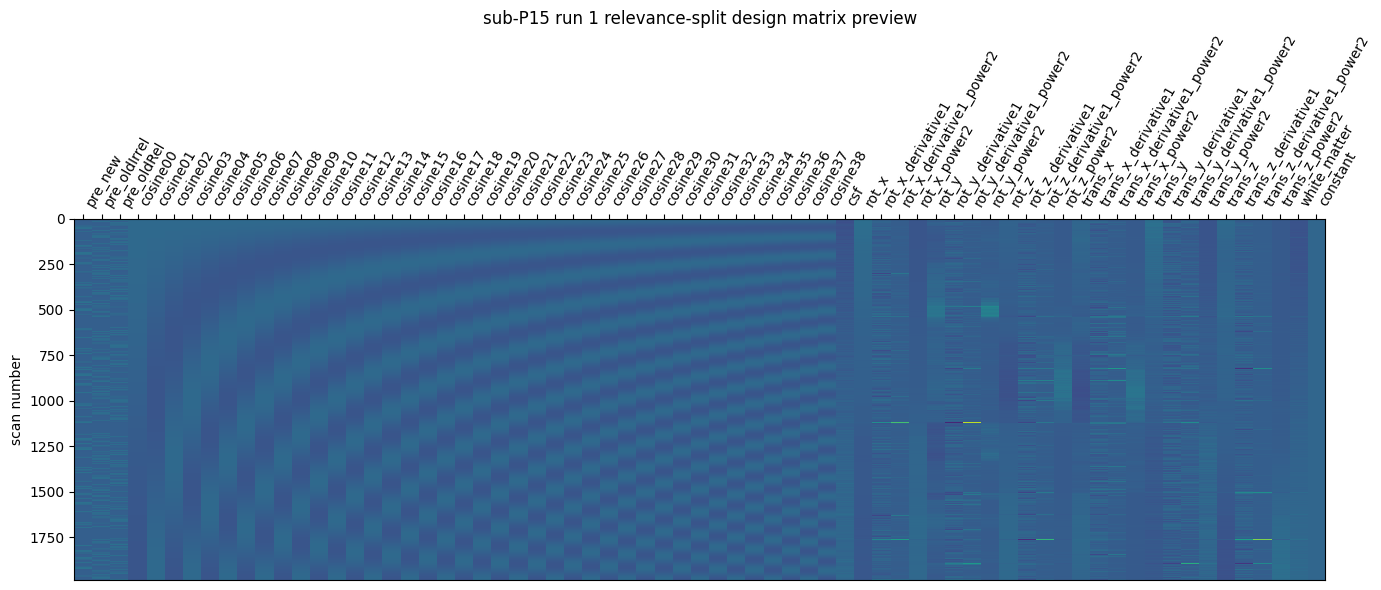

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/figures/sub-P15_run-1_design_matrix_preview_smoothed5mm.png

Run 2 design matrix columns:
['post_new', 'post_oldIrrel', 'post_oldRel', 'cosine00', 'cosine01', 'cosine02', 'cosine03', 'cosine04', 'cosine05', 'cosine06', 'cosine07', 'cosine08', 'cosine09', 'cosine10', 'cosine11', 'cosine12', 'cosine13', 'cosine14', 'cosine15', 'cosine16', 'cosine17', 'cosine18', 'cosine19', 'cosine20', 'cosine21', 'cosine22', 'cosine23', 'cosine24', 'cosine25', 'cosine26', 'cosine27', 'cosine28', 'cosine29', 'cosine30', 'cosine31', 'cosine32', 'cosine33', 'cosine34', 'cosine35', 'cosine36', 'cosine37', 'cosine38', 'csf', 'rot_x', 'rot_x_derivative1', 'rot_x_derivative1_power2', 'rot_x_power2', 'rot_y', 'rot_y_derivative1', 'rot_y_derivative1_power2', 'rot_y_power2', 'rot_z', 'rot_z_derivative1', 'rot_z_derivative1_power2', 'rot_z_power2', 'trans

/tmp/ipykernel_657410/2867884701.py:161: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


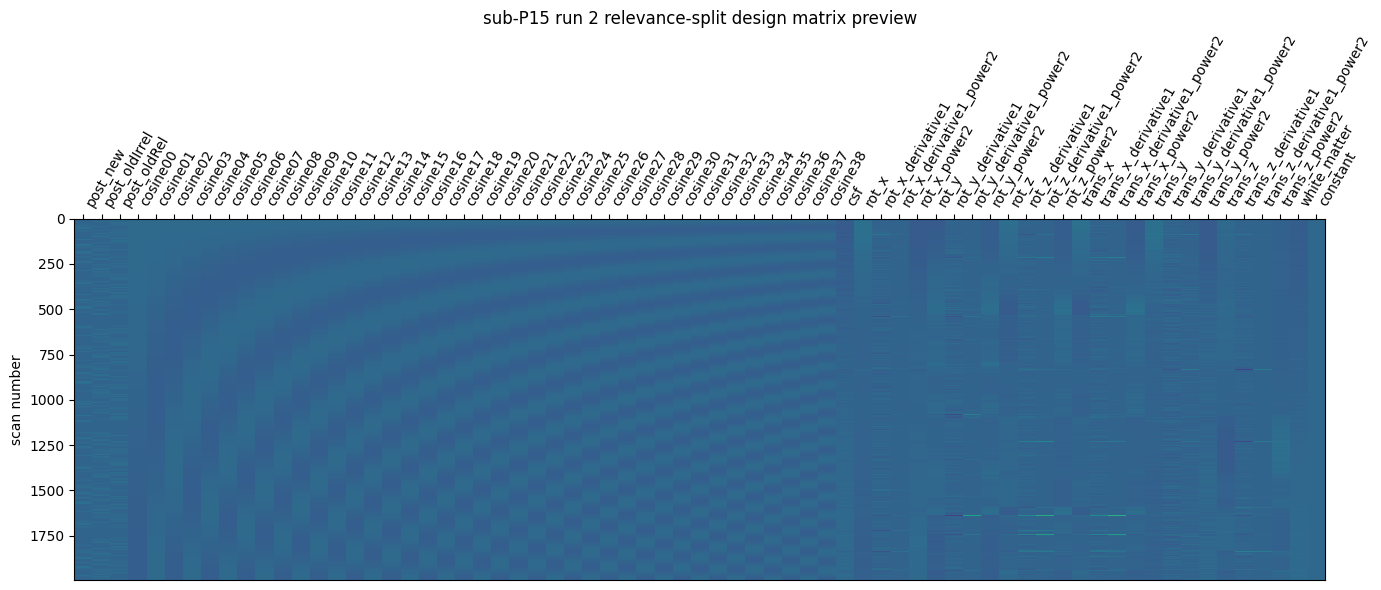

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/first_level_smoothed5mm/figures/sub-P15_run-2_design_matrix_preview_smoothed5mm.png


In [9]:
# ============================================================
# 9. Preview one subject's design matrix
# ============================================================

preview_subject = "sub-P15"

pre_bold = get_bold_file(preview_subject, PRE_SESSION)
post_bold = get_bold_file(preview_subject, POST_SESSION)

pre_events, post_events = load_pre_post_relevance_events_for_glm(preview_subject)

pre_confounds, pre_sample_mask = load_basic_confounds_for_bold(pre_bold)
post_confounds, post_sample_mask = load_basic_confounds_for_bold(post_bold)

tr_pre = infer_tr_from_bold(pre_bold)
tr_post = infer_tr_from_bold(post_bold)

assert np.isclose(tr_pre, tr_post)

sample_masks_for_fit = prepare_sample_masks_for_two_runs(
    pre_sample_mask,
    post_sample_mask,
)

preview_model = FirstLevelModel(
    t_r=tr_pre,
    hrf_model="spm",
    drift_model=None,
    noise_model="ar1",
    standardize=False,
    signal_scaling=0,
    smoothing_fwhm=SMOOTHING_FWHM,
    minimize_memory=False,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    preview_model = preview_model.fit(
        run_imgs=[str(pre_bold), str(post_bold)],
        events=[pre_events, post_events],
        confounds=[pre_confounds, post_confounds],
        sample_masks=sample_masks_for_fit,
    )

preview_design_matrices = preview_model.design_matrices_

preview_qc = pd.DataFrame([
    {
        "subject": preview_subject,
        "tr": tr_pre,
        "n_pre_scans": nib.load(str(pre_bold)).shape[-1],
        "n_post_scans": nib.load(str(post_bold)).shape[-1],
        "n_pre_events": len(pre_events),
        "n_post_events": len(post_events),
        "pre_event_types": ";".join(sorted(pre_events["trial_type"].unique())),
        "post_event_types": ";".join(sorted(post_events["trial_type"].unique())),
        "n_pre_confounds": pre_confounds.shape[1],
        "n_post_confounds": post_confounds.shape[1],
        "pre_sample_mask_is_none": pre_sample_mask is None,
        "post_sample_mask_is_none": post_sample_mask is None,
        "n_design_columns_run_1": preview_design_matrices[0].shape[1],
        "n_design_columns_run_2": preview_design_matrices[1].shape[1],
    }
])

print("Design preview subject:", preview_subject)

print("\nPreview QC:")
display(preview_qc)

print("\nPre events:")
display(pre_events.head())

print("\nPost events:")
display(post_events.head())

print("\nPre event counts:")
display(pre_events["trial_type"].value_counts().reset_index())

print("\nPost event counts:")
display(post_events["trial_type"].value_counts().reset_index())


# Task-regressor presence check
expected_run_1 = ["pre_oldRel", "pre_oldIrrel", "pre_new"]
expected_run_2 = ["post_oldRel", "post_oldIrrel", "post_new"]

presence_rows = []

for regressor in expected_run_1 + expected_run_2:
    presence_rows.append({
        "subject": preview_subject,
        "run": 1,
        "regressor": regressor,
        "present_in_design": regressor in preview_design_matrices[0].columns,
    })
    
    presence_rows.append({
        "subject": preview_subject,
        "run": 2,
        "regressor": regressor,
        "present_in_design": regressor in preview_design_matrices[1].columns,
    })

presence_table = pd.DataFrame(presence_rows)

print("\nTask-regressor presence in design matrices:")
display(presence_table)

assert all(
    presence_table.loc[
        (presence_table["run"] == 1)
        & (presence_table["regressor"].isin(expected_run_1)),
        "present_in_design",
    ]
)

assert not any(
    presence_table.loc[
        (presence_table["run"] == 1)
        & (presence_table["regressor"].isin(expected_run_2)),
        "present_in_design",
    ]
)

assert all(
    presence_table.loc[
        (presence_table["run"] == 2)
        & (presence_table["regressor"].isin(expected_run_2)),
        "present_in_design",
    ]
)

assert not any(
    presence_table.loc[
        (presence_table["run"] == 2)
        & (presence_table["regressor"].isin(expected_run_1)),
        "present_in_design",
    ]
)

print("\nDesign-matrix task regressors are exactly as expected.")

# Save and plot design matrices
for run_idx, design_matrix in enumerate(preview_design_matrices, start=1):
    design_path = (
        FIRST_LEVEL_DESIGN_DIR
        / f"{preview_subject}_run-{run_idx}_design_matrix_preview_{SMOOTHING_LABEL}.csv"
    )
    
    design_matrix.to_csv(design_path)
    
    print(f"\nRun {run_idx} design matrix columns:")
    print(list(design_matrix.columns))
    print("Saved:", design_path)
    
    plot_design_matrix(design_matrix)
    fig = plt.gcf()
    fig.set_size_inches(14, 6)
    plt.title(f"{preview_subject} run {run_idx} relevance-split design matrix preview")
    plt.tight_layout()
    
    fig_path = (
        FIRST_LEVEL_FIG_DIR
        / f"{preview_subject}_run-{run_idx}_design_matrix_preview_{SMOOTHING_LABEL}.png"
    )
    
    fig.savefig(fig_path, dpi=250, bbox_inches="tight")
    plt.show()
    
    print("Saved figure:", fig_path)

In [10]:
# ============================================================
# 10. Preview contrast vectors for relevance-split design
# ============================================================

contrast_vector_qc_rows = []

for contrast_name, contrast_weights in RELEVANCE_CONTRASTS.items():
    run_vectors, run_qc = build_two_run_contrast_vectors(
        preview_design_matrices,
        contrast_weights,
    )
    
    run_qc["contrast"] = contrast_name
    run_qc["priority"] = CONTRAST_PRIORITY[contrast_name]
    run_qc["formula"] = CONTRAST_FORMULAS[contrast_name]
    
    contrast_vector_qc_rows.append(run_qc)

contrast_vector_qc = pd.concat(contrast_vector_qc_rows, ignore_index=True)

cols = [
    "contrast",
    "priority",
    "run",
    "n_design_columns",
    "n_nonzero_weights",
    "nonzero_regressors",
    "nonzero_weights",
    "missing_regressors_expected",
    "is_null_vector",
]

display(contrast_vector_qc[cols])

contrast_vector_qc_path = TABLE_DIR / "pre_post_relevance_old_new_contrast_vector_preview_qc.csv"
contrast_vector_qc.to_csv(contrast_vector_qc_path, index=False)

print("Saved:", contrast_vector_qc_path)

# Key sanity checks
for contrast_name in [
    "rel_old_vs_new_post_gt_pre",
    "irrel_old_vs_new_post_gt_pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
]:
    this_qc = contrast_vector_qc.loc[
        contrast_vector_qc["contrast"] == contrast_name
    ]
    
    assert len(this_qc) == 2
    assert not this_qc["is_null_vector"].any(), (
        f"{contrast_name}: one run has a null vector unexpectedly."
    )

print("\nAll key contrast vectors are valid.")

,contrast,priority,run,n_design_columns,n_nonzero_weights,nonzero_regressors,nonzero_weights,missing_regressors_expected,is_null_vector
0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,1,69,2,pre_new;pre_oldRel,1.0;-1.0,post_oldRel;post_new,False
1,rel_old_vs_new_post_gt_pre,primary_relevance_specific,2,69,2,post_new;post_oldRel,-1.0;1.0,pre_oldRel;pre_new,False
2,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,1,69,2,pre_new;pre_oldIrrel,1.0;-1.0,post_oldIrrel;post_new,False
3,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,2,69,2,post_new;post_oldIrrel,-1.0;1.0,pre_oldIrrel;pre_new,False
4,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,1,69,2,pre_oldIrrel;pre_oldRel,1.0;-1.0,post_oldRel;post_oldIrrel,False
5,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,2,69,2,post_oldIrrel;post_oldRel,-1.0;1.0,pre_oldRel;pre_oldIrrel,False
6,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,1,69,2,pre_oldIrrel;pre_oldRel,-1.0;1.0,post_oldIrrel;post_oldRel,False
7,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,2,69,2,post_oldIrrel;post_oldRel,1.0;-1.0,pre_oldIrrel;pre_oldRel,False
8,oldRel_post_gt_pre,descriptive_old_post_pre,1,69,1,pre_oldRel,-1.0,post_oldRel,False
9,oldRel_post_gt_pre,descriptive_old_post_pre,2,69,1,post_oldRel,1.0,pre_oldRel,False


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_contrast_vector_preview_qc.csv

All key contrast vectors are valid.


In [11]:
# ============================================================
# 11. Full first-level relevance-split GLM for all subjects
# ============================================================

import gc
import traceback


def fit_relevance_first_level_subject(
    subject,
    save_outputs=True,
    make_design_plot=False,
):
    """
    Fit the two-run pre/post relevance-split first-level GLM for one subject.
    
    Run 1 = pre-viewing
    Run 2 = post-viewing
    
    Task regressors:
        pre_oldRel, pre_oldIrrel, pre_new
        post_oldRel, post_oldIrrel, post_new
    """
    
    pre_bold = get_bold_file(subject, PRE_SESSION)
    post_bold = get_bold_file(subject, POST_SESSION)
    
    assert pre_bold.exists(), f"Missing pre BOLD: {pre_bold}"
    assert post_bold.exists(), f"Missing post BOLD: {post_bold}"
    
    pre_events, post_events = load_pre_post_relevance_events_for_glm(subject)
    
    pre_confounds, pre_sample_mask = load_basic_confounds_for_bold(pre_bold)
    post_confounds, post_sample_mask = load_basic_confounds_for_bold(post_bold)
    
    tr_pre = infer_tr_from_bold(pre_bold)
    tr_post = infer_tr_from_bold(post_bold)
    
    assert np.isclose(tr_pre, tr_post), f"{subject}: pre/post TR mismatch"
    
    sample_masks_for_fit = prepare_sample_masks_for_two_runs(
        pre_sample_mask,
        post_sample_mask,
    )
    
    model = FirstLevelModel(
        t_r=tr_pre,
        hrf_model="spm",
        drift_model=None,
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=SMOOTHING_FWHM,
        minimize_memory=False,
    )
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = model.fit(
            run_imgs=[str(pre_bold), str(post_bold)],
            events=[pre_events, post_events],
            confounds=[pre_confounds, post_confounds],
            sample_masks=sample_masks_for_fit,
        )
    
    design_matrices = model.design_matrices_
    
    subject_qc = {
        "subject": subject,
        "tr": tr_pre,
        "n_pre_scans": nib.load(str(pre_bold)).shape[-1],
        "n_post_scans": nib.load(str(post_bold)).shape[-1],
        "n_pre_events": len(pre_events),
        "n_post_events": len(post_events),
        "pre_event_types": ";".join(sorted(pre_events["trial_type"].unique())),
        "post_event_types": ";".join(sorted(post_events["trial_type"].unique())),
        "n_pre_confounds": pre_confounds.shape[1],
        "n_post_confounds": post_confounds.shape[1],
        "pre_sample_mask_originally_none": pre_sample_mask is None,
        "post_sample_mask_originally_none": post_sample_mask is None,
        "n_design_columns_run_1": design_matrices[0].shape[1],
        "n_design_columns_run_2": design_matrices[1].shape[1],
        "design_columns_run_1": ";".join(design_matrices[0].columns),
        "design_columns_run_2": ";".join(design_matrices[1].columns),
    }
    
    # Save design matrices.
    if save_outputs:
        for run_idx, design_matrix in enumerate(design_matrices, start=1):
            design_path = (
                FIRST_LEVEL_DESIGN_DIR
                / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.csv"
            )
            design_matrix.to_csv(design_path)
            
            if make_design_plot:
                plot_design_matrix(design_matrix)
                fig = plt.gcf()
                fig.set_size_inches(14, 6)
                plt.title(f"{subject} run {run_idx} relevance-split design matrix")
                plt.tight_layout()
                
                fig_path = (
                    FIRST_LEVEL_FIG_DIR
                    / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.png"
                )
                fig.savefig(fig_path, dpi=250, bbox_inches="tight")
                plt.close(fig)
    
    # Compute contrasts.
    contrast_qc_rows = []
    
    for contrast_name, weights in RELEVANCE_CONTRASTS.items():
        run_vectors, run_qc = build_two_run_contrast_vectors(
            design_matrices,
            weights,
        )
        
        with warnings.catch_warnings():
            # Expected for pre-only/post-only descriptive contrasts:
            # one run has a null vector.
            warnings.simplefilter("ignore")
            
            z_map = model.compute_contrast(
                run_vectors,
                output_type="z_score",
            )
            
            effect_map = model.compute_contrast(
                run_vectors,
                output_type="effect_size",
            )
        
        z_path = get_first_level_z_map_path(subject, contrast_name)
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        
        if save_outputs:
            z_map.to_filename(str(z_path))
            effect_map.to_filename(str(effect_path))
        
        for _, row in run_qc.iterrows():
            contrast_qc_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "priority": CONTRAST_PRIORITY[contrast_name],
                "formula": CONTRAST_FORMULAS[contrast_name],
                "run": int(row["run"]),
                "n_design_columns": int(row["n_design_columns"]),
                "n_nonzero_weights": int(row["n_nonzero_weights"]),
                "nonzero_regressors": row["nonzero_regressors"],
                "nonzero_weights": row["nonzero_weights"],
                "missing_regressors_expected": row["missing_regressors_expected"],
                "is_null_vector": bool(row["is_null_vector"]),
                "z_map_saved": z_path.exists(),
                "effect_map_saved": effect_path.exists(),
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
            })
    
    contrast_qc = pd.DataFrame(contrast_qc_rows)
    
    return model, contrast_qc, subject_qc


# ------------------------------------------------------------
# Run all subjects
# ------------------------------------------------------------

first_level_qc_rows = []
first_level_contrast_qc_tables = []
failed_subjects = []

for subject in subjects:
    print("\n" + "=" * 80)
    print("Running first-level relevance-split GLM:", subject)
    
    try:
        model, contrast_qc, subject_qc = fit_relevance_first_level_subject(
            subject,
            save_outputs=True,
            make_design_plot=False,
        )
        
        first_level_qc_rows.append(subject_qc)
        first_level_contrast_qc_tables.append(contrast_qc)
        
        print("Finished:", subject)
        
        del model
        gc.collect()
        
    except Exception as e:
        print("FAILED:", subject)
        print(type(e).__name__, str(e))
        
        failed_subjects.append({
            "subject": subject,
            "error_type": type(e).__name__,
            "error_message": str(e),
            "traceback": traceback.format_exc(),
        })
        
        gc.collect()

first_level_qc = pd.DataFrame(first_level_qc_rows)

if len(first_level_contrast_qc_tables) > 0:
    first_level_contrast_qc = pd.concat(
        first_level_contrast_qc_tables,
        ignore_index=True,
    )
else:
    first_level_contrast_qc = pd.DataFrame()

failed_subjects_df = pd.DataFrame(failed_subjects)

first_level_qc_path = TABLE_DIR / f"pre_post_relevance_old_new_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = TABLE_DIR / f"pre_post_relevance_old_new_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = TABLE_DIR / f"pre_post_relevance_old_new_failed_subjects_{SMOOTHING_LABEL}.csv"

first_level_qc.to_csv(first_level_qc_path, index=False)
first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
failed_subjects_df.to_csv(failed_subjects_path, index=False)

print("\n" + "=" * 80)
print("First-level GLM complete.")
print("Successful subjects:", len(first_level_qc))
print("Failed subjects:", len(failed_subjects_df))

print("\nSaved:")
print(first_level_qc_path)
print(first_level_contrast_qc_path)
print(failed_subjects_path)

display(first_level_qc)
display(failed_subjects_df)

assert len(failed_subjects_df) == 0, "Some subjects failed. Inspect failed_subjects_df."
assert len(first_level_qc) == len(subjects), "Unexpected number of successful subjects."


Running first-level relevance-split GLM: sub-P10
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P10

Running first-level relevance-split GLM: sub-P12
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P12

Running first-level relevance-split GLM: sub-P13
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P13

Running first-level relevance-split GLM: sub-P14
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: 

,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P10,1.3,2026,1994,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,66,65,True,True,70,69,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
1,sub-P12,1.3,1996,1954,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,65,64,True,True,69,68,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
2,sub-P13,1.3,1952,1957,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,64,64,True,True,68,68,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
3,sub-P14,1.3,1967,1922,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,64,64,True,True,68,68,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
4,sub-P15,1.3,1986,1995,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,65,65,True,True,69,69,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
5,sub-P16,1.3,2024,1955,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,66,64,True,True,70,68,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
6,sub-P17,1.3,1906,1946,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,63,64,True,True,67,68,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
7,sub-P18,1.3,1979,1993,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,65,65,True,True,69,69,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
8,sub-P19,1.3,1939,1945,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,64,64,True,True,68,68,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
9,sub-P21,1.3,1956,1961,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,64,64,True,True,68,68,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...


,subject,error_type,error_message,traceback
0,sub-P22,TypeError,'NoneType' object is not iterable,"Traceback (most recent call last):\n File ""/t..."
1,sub-P43,TypeError,'NoneType' object is not iterable,"Traceback (most recent call last):\n File ""/t..."
2,sub-P44,TypeError,'NoneType' object is not iterable,"Traceback (most recent call last):\n File ""/t..."
3,sub-P50,TypeError,'NoneType' object is not iterable,"Traceback (most recent call last):\n File ""/t..."


AssertionError: Some subjects failed. Inspect failed_subjects_df.

In [12]:
# ============================================================
# 11b. Rerun only failed subjects with robust sample-mask handling
# ============================================================

import gc
import traceback

# ------------------------------------------------------------
# Fix sample-mask handling
# ------------------------------------------------------------

def make_full_sample_mask(bold_path):
    """
    Create a full sample mask containing all scan indices.
    Used when one run has a sample_mask and the other run has None.
    """
    n_scans = nib.load(str(bold_path)).shape[-1]
    return np.arange(n_scans, dtype=int)


def prepare_sample_masks_for_two_runs_robust(
    pre_sample_mask,
    post_sample_mask,
    pre_bold_path,
    post_bold_path,
):
    """
    Robust version:
    - If both sample masks are None, return None.
    - If one run has a sample mask and the other is None, replace None
      by a full index mask for that run.
    """
    if pre_sample_mask is None and post_sample_mask is None:
        return None
    
    if pre_sample_mask is None:
        pre_sample_mask = make_full_sample_mask(pre_bold_path)
    
    if post_sample_mask is None:
        post_sample_mask = make_full_sample_mask(post_bold_path)
    
    return [pre_sample_mask, post_sample_mask]


# ------------------------------------------------------------
# Override the subject-level fitting function with robust masks
# ------------------------------------------------------------

def fit_relevance_first_level_subject_robust(
    subject,
    save_outputs=True,
    make_design_plot=False,
):
    """
    Same as Cell 11, but robust to one run having sample_mask=None
    while the other run has a valid sample_mask.
    """
    
    pre_bold = get_bold_file(subject, PRE_SESSION)
    post_bold = get_bold_file(subject, POST_SESSION)
    
    assert pre_bold.exists(), f"Missing pre BOLD: {pre_bold}"
    assert post_bold.exists(), f"Missing post BOLD: {post_bold}"
    
    pre_events, post_events = load_pre_post_relevance_events_for_glm(subject)
    
    pre_confounds, pre_sample_mask = load_basic_confounds_for_bold(pre_bold)
    post_confounds, post_sample_mask = load_basic_confounds_for_bold(post_bold)
    
    tr_pre = infer_tr_from_bold(pre_bold)
    tr_post = infer_tr_from_bold(post_bold)
    
    assert np.isclose(tr_pre, tr_post), f"{subject}: pre/post TR mismatch"
    
    sample_masks_for_fit = prepare_sample_masks_for_two_runs_robust(
        pre_sample_mask=pre_sample_mask,
        post_sample_mask=post_sample_mask,
        pre_bold_path=pre_bold,
        post_bold_path=post_bold,
    )
    
    model = FirstLevelModel(
        t_r=tr_pre,
        hrf_model="spm",
        drift_model=None,
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=SMOOTHING_FWHM,
        minimize_memory=False,
    )
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = model.fit(
            run_imgs=[str(pre_bold), str(post_bold)],
            events=[pre_events, post_events],
            confounds=[pre_confounds, post_confounds],
            sample_masks=sample_masks_for_fit,
        )
    
    design_matrices = model.design_matrices_
    
    subject_qc = {
        "subject": subject,
        "tr": tr_pre,
        "n_pre_scans": nib.load(str(pre_bold)).shape[-1],
        "n_post_scans": nib.load(str(post_bold)).shape[-1],
        "n_pre_events": len(pre_events),
        "n_post_events": len(post_events),
        "pre_event_types": ";".join(sorted(pre_events["trial_type"].unique())),
        "post_event_types": ";".join(sorted(post_events["trial_type"].unique())),
        "n_pre_confounds": pre_confounds.shape[1],
        "n_post_confounds": post_confounds.shape[1],
        "pre_sample_mask_originally_none": pre_sample_mask is None,
        "post_sample_mask_originally_none": post_sample_mask is None,
        "sample_masks_passed_to_nilearn": sample_masks_for_fit is not None,
        "n_design_columns_run_1": design_matrices[0].shape[1],
        "n_design_columns_run_2": design_matrices[1].shape[1],
        "design_columns_run_1": ";".join(design_matrices[0].columns),
        "design_columns_run_2": ";".join(design_matrices[1].columns),
    }
    
    # Save design matrices.
    if save_outputs:
        for run_idx, design_matrix in enumerate(design_matrices, start=1):
            design_path = (
                FIRST_LEVEL_DESIGN_DIR
                / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.csv"
            )
            design_matrix.to_csv(design_path)
            
            if make_design_plot:
                plot_design_matrix(design_matrix)
                fig = plt.gcf()
                fig.set_size_inches(14, 6)
                plt.title(f"{subject} run {run_idx} relevance-split design matrix")
                plt.tight_layout()
                
                fig_path = (
                    FIRST_LEVEL_FIG_DIR
                    / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.png"
                )
                fig.savefig(fig_path, dpi=250, bbox_inches="tight")
                plt.close(fig)
    
    # Compute contrasts.
    contrast_qc_rows = []
    
    for contrast_name, weights in RELEVANCE_CONTRASTS.items():
        run_vectors, run_qc = build_two_run_contrast_vectors(
            design_matrices,
            weights,
        )
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            z_map = model.compute_contrast(
                run_vectors,
                output_type="z_score",
            )
            
            effect_map = model.compute_contrast(
                run_vectors,
                output_type="effect_size",
            )
        
        z_path = get_first_level_z_map_path(subject, contrast_name)
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        
        if save_outputs:
            z_map.to_filename(str(z_path))
            effect_map.to_filename(str(effect_path))
        
        for _, row in run_qc.iterrows():
            contrast_qc_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "priority": CONTRAST_PRIORITY[contrast_name],
                "formula": CONTRAST_FORMULAS[contrast_name],
                "run": int(row["run"]),
                "n_design_columns": int(row["n_design_columns"]),
                "n_nonzero_weights": int(row["n_nonzero_weights"]),
                "nonzero_regressors": row["nonzero_regressors"],
                "nonzero_weights": row["nonzero_weights"],
                "missing_regressors_expected": row["missing_regressors_expected"],
                "is_null_vector": bool(row["is_null_vector"]),
                "z_map_saved": z_path.exists(),
                "effect_map_saved": effect_path.exists(),
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
            })
    
    contrast_qc = pd.DataFrame(contrast_qc_rows)
    
    return model, contrast_qc, subject_qc


# ------------------------------------------------------------
# Identify failed subjects from previous run
# ------------------------------------------------------------

failed_subjects_path = TABLE_DIR / f"pre_post_relevance_old_new_failed_subjects_{SMOOTHING_LABEL}.csv"
assert failed_subjects_path.exists(), f"Missing failed-subjects table: {failed_subjects_path}"

failed_subjects_df = pd.read_csv(failed_subjects_path)

failed_subjects_to_rerun = failed_subjects_df["subject"].tolist()

print("Subjects to rerun:")
print(failed_subjects_to_rerun)

assert len(failed_subjects_to_rerun) > 0, "No failed subjects found to rerun."


# ------------------------------------------------------------
# Rerun failed subjects only
# ------------------------------------------------------------

rerun_qc_rows = []
rerun_contrast_qc_tables = []
rerun_failed = []

for subject in failed_subjects_to_rerun:
    print("\n" + "=" * 80)
    print("Rerunning failed subject:", subject)
    
    try:
        model, contrast_qc, subject_qc = fit_relevance_first_level_subject_robust(
            subject,
            save_outputs=True,
            make_design_plot=False,
        )
        
        rerun_qc_rows.append(subject_qc)
        rerun_contrast_qc_tables.append(contrast_qc)
        
        print("Finished rerun:", subject)
        
        del model
        gc.collect()
        
    except Exception as e:
        print("FAILED AGAIN:", subject)
        print(type(e).__name__, str(e))
        
        rerun_failed.append({
            "subject": subject,
            "error_type": type(e).__name__,
            "error_message": str(e),
            "traceback": traceback.format_exc(),
        })
        
        gc.collect()

rerun_qc = pd.DataFrame(rerun_qc_rows)

if len(rerun_contrast_qc_tables) > 0:
    rerun_contrast_qc = pd.concat(
        rerun_contrast_qc_tables,
        ignore_index=True,
    )
else:
    rerun_contrast_qc = pd.DataFrame()

rerun_failed_df = pd.DataFrame(rerun_failed)

display(rerun_qc)
display(rerun_failed_df)

assert rerun_failed_df.empty, "Some rerun subjects failed again."


# ------------------------------------------------------------
# Merge with previous successful QC tables and save updated files
# ------------------------------------------------------------

first_level_qc_path = TABLE_DIR / f"pre_post_relevance_old_new_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = TABLE_DIR / f"pre_post_relevance_old_new_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"

previous_qc = pd.read_csv(first_level_qc_path)
previous_contrast_qc = pd.read_csv(first_level_contrast_qc_path)

# Remove any stale rows for rerun subjects, then append fresh rows.
updated_qc = pd.concat(
    [
        previous_qc.loc[~previous_qc["subject"].isin(failed_subjects_to_rerun)],
        rerun_qc,
    ],
    ignore_index=True,
)

updated_contrast_qc = pd.concat(
    [
        previous_contrast_qc.loc[
            ~previous_contrast_qc["subject"].isin(failed_subjects_to_rerun)
        ],
        rerun_contrast_qc,
    ],
    ignore_index=True,
)

updated_qc = updated_qc.sort_values("subject").reset_index(drop=True)
updated_contrast_qc = updated_contrast_qc.sort_values(
    ["subject", "contrast", "run"]
).reset_index(drop=True)

updated_qc.to_csv(first_level_qc_path, index=False)
updated_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)

# Save updated failed table as empty if all good.
updated_failed_path = TABLE_DIR / f"pre_post_relevance_old_new_failed_subjects_after_rerun_{SMOOTHING_LABEL}.csv"
rerun_failed_df.to_csv(updated_failed_path, index=False)

print("\nUpdated QC saved:")
print(first_level_qc_path)
print(first_level_contrast_qc_path)
print(updated_failed_path)

print("\nUpdated successful subjects:", updated_qc["subject"].nunique())

assert updated_qc["subject"].nunique() == len(subjects), "Still missing successful subjects."

print("\nRerun complete. All subjects now have first-level QC rows.")

Subjects to rerun:
['sub-P22', 'sub-P43', 'sub-P44', 'sub-P50']

Rerunning failed subject: sub-P22
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished rerun: sub-P22

Rerunning failed subject: sub-P43
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished rerun: sub-P43

Rerunning failed subject: sub-P44
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished rerun: sub-P44

Rerunning failed subject: sub-P50
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data a

,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P22,1.3,1977,2014,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,65,65,False,True,True,69,69,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
1,sub-P43,1.3,1736,1618,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,60,57,True,False,True,64,61,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
2,sub-P44,1.3,1669,1668,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,58,58,True,False,True,62,62,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...
3,sub-P50,1.3,1692,1739,384,384,pre_new;pre_oldIrrel;pre_oldRel,post_new;post_oldIrrel;post_oldRel,59,60,False,True,True,63,64,pre_new;pre_oldIrrel;pre_oldRel;cosine00;cosin...,post_new;post_oldIrrel;post_oldRel;cosine00;co...


""



Updated QC saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_first_level_qc_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_first_level_contrast_qc_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_failed_subjects_after_rerun_smoothed5mm.csv

Updated successful subjects: 27

Rerun complete. All subjects now have first-level QC rows.


In [13]:
# ============================================================
# 12. Verify first-level map completeness
# ============================================================

map_qc_rows = []

for contrast_name in RELEVANCE_CONTRASTS.keys():
    for subject in subjects:
        z_path = get_first_level_z_map_path(subject, contrast_name)
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        
        map_qc_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "z_map_exists": z_path.exists(),
            "effect_map_exists": effect_path.exists(),
            "z_map_path": str(z_path),
            "effect_map_path": str(effect_path),
        })

first_level_map_qc = pd.DataFrame(map_qc_rows)

display(
    first_level_map_qc
    .groupby(["contrast", "priority"])
    .agg(
        n_subjects=("subject", "nunique"),
        n_z_maps=("z_map_exists", "sum"),
        n_effect_maps=("effect_map_exists", "sum"),
    )
    .reset_index()
)

missing_maps = first_level_map_qc.loc[
    (~first_level_map_qc["z_map_exists"])
    | (~first_level_map_qc["effect_map_exists"])
].copy()

print("\nMissing maps:")
display(missing_maps)

first_level_map_qc_path = TABLE_DIR / f"pre_post_relevance_old_new_first_level_map_qc_{SMOOTHING_LABEL}.csv"
first_level_map_qc.to_csv(first_level_map_qc_path, index=False)

print("Saved:", first_level_map_qc_path)

assert missing_maps.empty, "Some first-level maps are missing."

,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,27,27,27
1,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,27,27,27
2,oldIrrel_post_gt_pre,descriptive_old_post_pre,27,27,27
3,oldRel_post_gt_pre,descriptive_old_post_pre,27,27,27
4,post_oldIrrel_gt_new,descriptive_post_only,27,27,27
5,post_oldRel_gt_new,descriptive_post_only,27,27,27
6,pre_oldIrrel_gt_new,baseline_pre_only,27,27,27
7,pre_oldRel_gt_new,baseline_pre_only,27,27,27
8,rel_old_vs_new_post_gt_pre,primary_relevance_specific,27,27,27
9,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,27,27,27



Missing maps:


,subject,contrast,priority,z_map_exists,effect_map_exists,z_map_path,effect_map_path


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_first_level_map_qc_smoothed5mm.csv


In [14]:
# ============================================================
# 13. Second-level group GLM for relevance-split contrasts
# ============================================================

second_level_qc_rows = []

for contrast_name, weights in RELEVANCE_CONTRASTS.items():
    print("\n" + "=" * 80)
    print("Second-level GLM:", contrast_name)
    
    effect_maps = [
        str(get_first_level_effect_map_path(subject, contrast_name))
        for subject in subjects
    ]
    
    missing = [
        path for path in effect_maps
        if not Path(path).exists()
    ]
    
    assert len(missing) == 0, f"Missing first-level effect maps for {contrast_name}: {missing[:5]}"
    
    design_matrix = pd.DataFrame(
        np.ones((len(effect_maps), 1)),
        columns=["intercept"],
    )
    
    second_level_model = SecondLevelModel(
        smoothing_fwhm=None,
        n_jobs=1,
    )
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        second_level_model = second_level_model.fit(
            effect_maps,
            design_matrix=design_matrix,
        )
    
    z_map = second_level_model.compute_contrast(
        "intercept",
        output_type="z_score",
    )
    
    effect_map = second_level_model.compute_contrast(
        "intercept",
        output_type="effect_size",
    )
    
    z_path = get_group_z_map_path(contrast_name)
    effect_path = get_group_effect_map_path(contrast_name)
    
    z_map.to_filename(str(z_path))
    effect_map.to_filename(str(effect_path))
    
    second_level_qc_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "n_subjects": len(effect_maps),
        "z_map_path": str(z_path),
        "effect_map_path": str(effect_path),
        "z_map_exists": z_path.exists(),
        "effect_map_exists": effect_path.exists(),
    })
    
    print("Saved z-map:", z_path)
    print("Saved effect map:", effect_path)

second_level_qc = pd.DataFrame(second_level_qc_rows)

second_level_qc_path = TABLE_DIR / f"pre_post_relevance_old_new_second_level_qc_from_{SMOOTHING_LABEL}.csv"
second_level_qc.to_csv(second_level_qc_path, index=False)

display(second_level_qc)

print("Saved:", second_level_qc_path)

assert second_level_qc["z_map_exists"].all()
assert second_level_qc["effect_map_exists"].all()


Second-level GLM: rel_old_vs_new_post_gt_pre
Saved z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_relevance_old_new_rel_old_vs_new_post_gt_pre_from_smoothed5mm_zmap.nii.gz
Saved effect map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_relevance_old_new_rel_old_vs_new_post_gt_pre_from_smoothed5mm_effect.nii.gz

Second-level GLM: irrel_old_vs_new_post_gt_pre
Saved z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_relevance_old_new_irrel_old_vs_new_post_gt_pre_from_smoothed5mm_zmap.nii.gz
Saved effect map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_re

,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
1,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
2,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
3,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
4,oldRel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
5,oldIrrel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
6,post_oldRel_gt_new,descriptive_post_only,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
7,post_oldIrrel_gt_new,descriptive_post_only,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
8,pre_oldRel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{p...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
9,pre_oldIrrel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_second_level_qc_from_smoothed5mm.csv


In [15]:
# ============================================================
# 14. Whole-brain threshold summary for relevance-split contrasts
# ============================================================

THRESHOLD_DIR = SECOND_LEVEL_DIR / "thresholded_maps"
THRESHOLD_DIR.mkdir(parents=True, exist_ok=True)

threshold_specs = [
    {
        "threshold_label": "uncorrected_p001_one_sided",
        "height_control": None,
        "alpha": 0.001,
        "two_sided": False,
    },
    {
        "threshold_label": "fdr_q05_one_sided",
        "height_control": "fdr",
        "alpha": 0.05,
        "two_sided": False,
    },
    {
        "threshold_label": "fdr_q10_one_sided",
        "height_control": "fdr",
        "alpha": 0.10,
        "two_sided": False,
    },
    {
        "threshold_label": "bonferroni_p05_one_sided",
        "height_control": "bonferroni",
        "alpha": 0.05,
        "two_sided": False,
    },
]

threshold_rows = []

for contrast_name in RELEVANCE_CONTRASTS.keys():
    print("\n" + "=" * 80)
    print("Thresholding:", contrast_name)
    
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    
    for spec in threshold_specs:
        threshold_label = spec["threshold_label"]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            thresholded_img, z_threshold = threshold_stats_img(
                z_img,
                alpha=spec["alpha"],
                height_control=spec["height_control"],
                cluster_threshold=0,
                two_sided=spec["two_sided"],
            )
        
        thresholded_data = thresholded_img.get_fdata()
        nonzero_data = thresholded_data[thresholded_data != 0]
        
        n_nonzero_voxels = int(np.sum(thresholded_data != 0))
        max_z = float(np.nanmax(nonzero_data)) if n_nonzero_voxels > 0 else np.nan
        
        out_path = (
            THRESHOLD_DIR
            / f"group_pre_post_relevance_old_new_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.nii.gz"
        )
        
        thresholded_img.to_filename(str(out_path))
        
        threshold_rows.append({
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "formula": CONTRAST_FORMULAS[contrast_name],
            "threshold_label": threshold_label,
            "height_control": spec["height_control"] if spec["height_control"] is not None else "uncorrected",
            "alpha": spec["alpha"],
            "two_sided": spec["two_sided"],
            "z_threshold": float(z_threshold),
            "n_nonzero_voxels": n_nonzero_voxels,
            "max_z": max_z,
            "thresholded_map_path": str(out_path),
        })

threshold_summary = pd.DataFrame(threshold_rows)

threshold_summary_path = (
    TABLE_DIR
    / f"pre_post_relevance_old_new_whole_brain_threshold_summary_from_{SMOOTHING_LABEL}.csv"
)

threshold_summary.to_csv(threshold_summary_path, index=False)

display(
    threshold_summary.sort_values(
        ["priority", "contrast", "threshold_label"]
    )
)

print("Saved:", threshold_summary_path)

print("\nKey relevance contrasts:")
display(
    threshold_summary.loc[
        threshold_summary["contrast"].isin([
            "rel_old_vs_new_post_gt_pre",
            "irrel_old_vs_new_post_gt_pre",
            "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
            "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
        ])
    ].sort_values(["contrast", "threshold_label"])
)


Thresholding: rel_old_vs_new_post_gt_pre

Thresholding: irrel_old_vs_new_post_gt_pre

Thresholding: rel_vs_new_gt_irrel_vs_new_post_gt_pre

Thresholding: irrel_vs_new_gt_rel_vs_new_post_gt_pre

Thresholding: oldRel_post_gt_pre

Thresholding: oldIrrel_post_gt_pre

Thresholding: post_oldRel_gt_new

Thresholding: post_oldIrrel_gt_new

Thresholding: pre_oldRel_gt_new

Thresholding: pre_oldIrrel_gt_new


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
39,pre_oldIrrel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm...",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
37,pre_oldIrrel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm...",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
38,pre_oldIrrel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm...",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
36,pre_oldIrrel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm...",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,230,4.164601,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
35,pre_oldRel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{p...",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
33,pre_oldRel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{p...",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
34,pre_oldRel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{p...",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
32,pre_oldRel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{p...",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,132,4.130151,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
23,oldIrrel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
21,oldIrrel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_whole_brain_threshold_summary_from_smoothed5mm.csv

Key relevance contrasts:


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
7,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
6,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,76,4.265341,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
15,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
13,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
14,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
12,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,58,3.931434,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


In [16]:
# ============================================================
# 15. Cluster tables for relevance-split contrasts
# Exploratory z > 2.33 and z > 3.00
# ============================================================

CLUSTER_TABLE_DIR = SECOND_LEVEL_DIR / "cluster_tables"
CLUSTER_TABLE_DIR.mkdir(parents=True, exist_ok=True)

cluster_specs = [
    {
        "threshold_label": "z_gt_2.33",
        "stat_threshold": 2.33,
        "cluster_threshold": 10,
    },
    {
        "threshold_label": "z_gt_3.00",
        "stat_threshold": 3.00,
        "cluster_threshold": 10,
    },
]

cluster_summary_rows = []
cluster_detail_tables = []

for contrast_name in RELEVANCE_CONTRASTS.keys():
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    
    for spec in cluster_specs:
        threshold_label = spec["threshold_label"]
        
        print("\n" + "=" * 80)
        print("Contrast:", contrast_name)
        print("Threshold:", threshold_label)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            clusters = get_clusters_table(
                z_img,
                stat_threshold=spec["stat_threshold"],
                cluster_threshold=spec["cluster_threshold"],
                two_sided=False,
            )
        
        # Ensure robust numeric columns.
        if len(clusters) > 0:
            for col in ["Peak Stat", "Cluster Size (mm3)", "X", "Y", "Z"]:
                if col in clusters.columns:
                    clusters[col] = pd.to_numeric(clusters[col], errors="coerce")
            
            clusters["contrast"] = contrast_name
            clusters["priority"] = CONTRAST_PRIORITY[contrast_name]
            clusters["formula"] = CONTRAST_FORMULAS[contrast_name]
            clusters["threshold_label"] = threshold_label
            clusters["stat_threshold"] = spec["stat_threshold"]
            clusters["cluster_threshold_voxels"] = spec["cluster_threshold"]
            
            cluster_detail_tables.append(clusters)
            
            display(clusters)
        else:
            print("No clusters.")
        
        out_path = (
            CLUSTER_TABLE_DIR
            / f"clusters_pre_post_relevance_old_new_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.csv"
        )
        
        clusters.to_csv(out_path, index=False)
        
        if len(clusters) > 0:
            max_peak_stat = float(pd.to_numeric(clusters["Peak Stat"], errors="coerce").max())
            largest_cluster = float(pd.to_numeric(clusters["Cluster Size (mm3)"], errors="coerce").max())
        else:
            max_peak_stat = np.nan
            largest_cluster = np.nan
        
        cluster_summary_rows.append({
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "threshold_label": threshold_label,
            "stat_threshold": spec["stat_threshold"],
            "cluster_threshold_voxels": spec["cluster_threshold"],
            "n_clusters": len(clusters),
            "max_peak_stat": max_peak_stat,
            "largest_cluster_mm3": largest_cluster,
            "cluster_table_path": str(out_path),
        })

cluster_summary = pd.DataFrame(cluster_summary_rows)

if len(cluster_detail_tables) > 0:
    cluster_details = pd.concat(cluster_detail_tables, ignore_index=True)
else:
    cluster_details = pd.DataFrame()

cluster_summary_path = (
    TABLE_DIR
    / f"pre_post_relevance_old_new_cluster_summary_from_{SMOOTHING_LABEL}.csv"
)

cluster_details_path = (
    TABLE_DIR
    / f"pre_post_relevance_old_new_cluster_details_z233_z300_from_{SMOOTHING_LABEL}.csv"
)

cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_details.to_csv(cluster_details_path, index=False)

print("\nCluster summary:")
display(
    cluster_summary.sort_values(
        ["priority", "contrast", "threshold_label"]
    )
)

print("\nTop cluster details:")
if len(cluster_details) > 0:
    display(
        cluster_details.sort_values(
            ["contrast", "threshold_label", "Peak Stat"],
            ascending=[True, True, False],
        ).head(50)
    )

print("Saved:")
print(cluster_summary_path)
print(cluster_details_path)


Contrast: rel_old_vs_new_post_gt_pre
Threshold: z_gt_2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,4.0,-17.0,-15.5,4.887609,765.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
1,2,6.5,35.5,29.5,3.983902,1125.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
2,3,46.5,3.0,-43.0,3.946142,171.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
3,4,46.5,25.5,44.5,3.879742,531.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
4,5,41.5,-54.5,4.5,3.811980,515.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
5,5a,51.5,-54.5,12.0,2.961583,NaN,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
6,6,21.5,58.0,-10.5,3.806724,1921.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
7,6a,29.0,55.5,-3.0,3.080984,NaN,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
8,6b,29.0,65.5,-8.0,3.050663,NaN,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
9,6c,31.5,53.0,-8.0,2.940176,NaN,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10



Contrast: rel_old_vs_new_post_gt_pre
Threshold: z_gt_3.00


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,4.0,-17.0,-15.5,4.887609,375,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_3.00,3.0,10
1,2,6.5,35.5,29.5,3.983902,281,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_3.00,3.0,10
2,3,21.5,58.0,-10.5,3.806724,187,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_3.00,3.0,10
3,4,49.0,-54.5,54.5,3.629020,296,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_3.00,3.0,10



Contrast: irrel_old_vs_new_post_gt_pre
Threshold: z_gt_2.33


...


Cluster summary:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
18,pre_oldIrrel_gt_new,baseline_pre_only,z_gt_2.33,2.33,10,32,4.164601,9546.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
19,pre_oldIrrel_gt_new,baseline_pre_only,z_gt_3.00,3.00,10,6,4.164601,656.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
16,pre_oldRel_gt_new,baseline_pre_only,z_gt_2.33,2.33,10,22,4.130151,1796.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
17,pre_oldRel_gt_new,baseline_pre_only,z_gt_3.00,3.00,10,4,3.747317,265.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
10,oldIrrel_post_gt_pre,descriptive_old_post_pre,z_gt_2.33,2.33,10,13,4.282755,890.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
11,oldIrrel_post_gt_pre,descriptive_old_post_pre,z_gt_3.00,3.00,10,1,4.003841,156.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
8,oldRel_post_gt_pre,descriptive_old_post_pre,z_gt_2.33,2.33,10,25,4.375260,3140.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
9,oldRel_post_gt_pre,descriptive_old_post_pre,z_gt_3.00,3.00,10,1,3.965253,328.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
14,post_oldIrrel_gt_new,descriptive_post_only,z_gt_2.33,2.33,10,15,3.998869,1406.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
15,post_oldIrrel_gt_new,descriptive_post_only,z_gt_3.00,3.00,10,2,3.747695,203.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Top cluster details:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
61,1,21.5,-32.0,-40.5,4.265341,156.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
62,2,6.5,-44.5,-38.0,3.888070,687.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
66,3,9.0,-34.5,-43.0,3.849212,312.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
67,4,14.0,50.5,-5.5,3.640559,203.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
68,5,-38.5,13.0,-18.0,3.538855,375.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
70,6,49.0,-17.0,-10.5,3.405319,609.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
63,2a,14.0,-47.0,-35.5,3.366794,NaN,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
72,7,-18.5,3.0,57.0,3.360205,171.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
74,8,4.0,-12.0,-18.0,3.308798,296.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10
75,9,44.0,8.0,-10.5,3.301398,375.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",z_gt_2.33,2.33,10


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_cluster_summary_from_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_cluster_details_z233_z300_from_smoothed5mm.csv


In [17]:
# ============================================================
# 16. Compact result view for key relevance contrasts
# ============================================================

KEY_RELEVANCE_CONTRASTS = [
    "rel_old_vs_new_post_gt_pre",
    "irrel_old_vs_new_post_gt_pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
]

print("Threshold summary for key relevance contrasts:")
display(
    threshold_summary.loc[
        threshold_summary["contrast"].isin(KEY_RELEVANCE_CONTRASTS)
    ][
        [
            "contrast",
            "priority",
            "threshold_label",
            "height_control",
            "alpha",
            "z_threshold",
            "n_nonzero_voxels",
            "max_z",
        ]
    ].sort_values(["contrast", "threshold_label"])
)

print("\nCluster summary for key relevance contrasts:")
display(
    cluster_summary.loc[
        cluster_summary["contrast"].isin(KEY_RELEVANCE_CONTRASTS)
    ].sort_values(["contrast", "threshold_label"])
)

print("\nTop exploratory clusters for key relevance contrasts, z > 2.33:")
if len(cluster_details) > 0:
    display(
        cluster_details.loc[
            (cluster_details["contrast"].isin(KEY_RELEVANCE_CONTRASTS))
            & (cluster_details["threshold_label"] == "z_gt_2.33")
        ][
            [
                "Cluster ID",
                "X",
                "Y",
                "Z",
                "Peak Stat",
                "Cluster Size (mm3)",
                "contrast",
                "priority",
            ]
        ].sort_values(["contrast", "Peak Stat"], ascending=[True, False])
    )

Threshold summary for key relevance contrasts:


,contrast,priority,threshold_label,height_control,alpha,z_threshold,n_nonzero_voxels,max_z
7,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
5,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,fdr_q05_one_sided,fdr,0.050,inf,0,NaN
6,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,fdr_q10_one_sided,fdr,0.100,inf,0,NaN
4,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,uncorrected_p001_one_sided,uncorrected,0.001,3.000000,76,4.265341
15,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
13,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,fdr_q05_one_sided,fdr,0.050,inf,0,NaN
14,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,fdr_q10_one_sided,fdr,0.100,inf,0,NaN
12,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,uncorrected_p001_one_sided,uncorrected,0.001,3.000000,58,3.931434
3,rel_old_vs_new_post_gt_pre,primary_relevance_specific,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
1,rel_old_vs_new_post_gt_pre,primary_relevance_specific,fdr_q05_one_sided,fdr,0.050,inf,0,NaN



Cluster summary for key relevance contrasts:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
2,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_2.33,2.33,10,24,4.265341,687.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
6,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,z_gt_2.33,2.33,10,11,3.931434,515.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
7,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_2.33,2.33,10,57,4.887609,3046.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,rel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_3.00,3.00,10,4,4.887609,375.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,z_gt_2.33,2.33,10,133,4.567430,7078.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,z_gt_3.00,3.00,10,17,4.567430,2718.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Top exploratory clusters for key relevance contrasts, z > 2.33:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority
61,1,21.5,-32.0,-40.5,4.265341,156.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific
62,2,6.5,-44.5,-38.0,3.888070,687.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific
66,3,9.0,-34.5,-43.0,3.849212,312.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific
67,4,14.0,50.5,-5.5,3.640559,203.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific
68,5,-38.5,13.0,-18.0,3.538855,375.0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific
...,...,...,...,...,...,...,...,...
205,62a,-61.0,-29.5,9.5,2.581573,NaN,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction
103,6b,-41.0,38.0,9.5,2.564782,NaN,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction
201,59a,-43.5,-17.0,64.5,2.547282,NaN,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction
199,58a,4.0,3.0,72.0,2.473049,NaN,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction


### Relevance-split old/new pre-post GLM: preliminary whole-brain result

The relevance-split GLM tested whether the old-vs-new post-pre memory effect differed between goal-relevant and goal-irrelevant old images.

The relevant old-vs-new post-pre contrast was:

$$
C_{\mathrm{rel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

The irrelevant old-vs-new post-pre contrast was:

$$
C_{\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

The main relevance interaction compared these two old-vs-new effects:

$$
C_{\mathrm{rel-vs-new}>\mathrm{irrel-vs-new}}
=
C_{\mathrm{rel-vs-new}} - C_{\mathrm{irrel-vs-new}}.
$$

Expanded:

$$
C_{\mathrm{rel-vs-new}>\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}}).
$$

At the exploratory uncorrected threshold $$p<.001$$ one-sided, the relevant old-vs-new effect showed a stronger whole-brain pattern than the irrelevant old-vs-new effect. The relevant contrast reached a maximum of approximately:

$$
z_{\max}=4.89,
$$

whereas the irrelevant contrast reached:

$$
z_{\max}=4.27.
$$

The direct relevant-greater-than-irrelevant interaction showed the largest exploratory spatial extent among the key contrasts, with:

$$
z_{\max}=4.57.
$$

However, none of the key contrasts survived whole-brain FDR or Bonferroni correction. Therefore, these results should be interpreted as exploratory evidence that goal relevance may amplify the old-vs-new post-pre memory effect.

In [18]:
# ============================================================
# 17. Atlas-label key relevance-split clusters
# ============================================================

from nilearn.datasets import fetch_atlas_harvard_oxford
from nilearn.image import resample_to_img

KEY_RELEVANCE_CONTRASTS = [
    "rel_old_vs_new_post_gt_pre",
    "irrel_old_vs_new_post_gt_pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
]

# Load saved cluster details if needed
cluster_details_path = (
    TABLE_DIR
    / f"pre_post_relevance_old_new_cluster_details_z233_z300_from_{SMOOTHING_LABEL}.csv"
)

cluster_details = pd.read_csv(cluster_details_path)

# Keep main cluster rows only, not secondary local maxima like 1a, 1b, etc.
key_clusters = cluster_details.loc[
    (cluster_details["contrast"].isin(KEY_RELEVANCE_CONTRASTS))
    & (cluster_details["threshold_label"] == "z_gt_2.33")
].copy()

key_clusters["Cluster ID"] = key_clusters["Cluster ID"].astype(str)

main_peak_mask = ~key_clusters["Cluster ID"].str.contains("[a-zA-Z]", regex=True)
key_clusters = key_clusters.loc[main_peak_mask].copy()

# Convert coordinate/stat columns
for col in ["X", "Y", "Z", "Peak Stat", "Cluster Size (mm3)"]:
    key_clusters[col] = pd.to_numeric(key_clusters[col], errors="coerce")

# Fetch Harvard-Oxford atlases
cortical_atlas = fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
subcortical_atlas = fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")

cortical_img = load_img(cortical_atlas.maps)
subcortical_img = load_img(subcortical_atlas.maps)

reference_img = load_img(str(get_group_z_map_path("rel_old_vs_new_post_gt_pre")))

cortical_resampled = resample_to_img(
    cortical_img,
    reference_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

subcortical_resampled = resample_to_img(
    subcortical_img,
    reference_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

cort_data = cortical_resampled.get_fdata().astype(int)
sub_data = subcortical_resampled.get_fdata().astype(int)

affine = reference_img.affine
inv_affine = np.linalg.inv(affine)

def atlas_label_at_coord(coord, atlas_data, atlas_labels):
    ijk = nib.affines.apply_affine(inv_affine, coord)
    ijk = np.round(ijk).astype(int)
    
    if np.any(ijk < 0) or np.any(ijk >= np.array(atlas_data.shape)):
        return "Outside atlas", np.nan
    
    value = int(atlas_data[tuple(ijk)])
    
    if value < len(atlas_labels):
        label = atlas_labels[value]
    else:
        label = "Unknown"
    
    return label, value

label_rows = []

for _, row in key_clusters.iterrows():
    coord = np.array([row["X"], row["Y"], row["Z"]], dtype=float)
    
    cort_label, cort_value = atlas_label_at_coord(
        coord,
        cort_data,
        cortical_atlas.labels,
    )
    
    sub_label, sub_value = atlas_label_at_coord(
        coord,
        sub_data,
        subcortical_atlas.labels,
    )
    
    label_rows.append({
        "contrast": row["contrast"],
        "priority": row["priority"],
        "threshold_label": row["threshold_label"],
        "cluster_id": row["Cluster ID"],
        "x": row["X"],
        "y": row["Y"],
        "z": row["Z"],
        "peak_z": row["Peak Stat"],
        "cluster_size_mm3": row["Cluster Size (mm3)"],
        "harvard_oxford_cortical_label": cort_label,
        "harvard_oxford_cortical_value": cort_value,
        "harvard_oxford_subcortical_label": sub_label,
        "harvard_oxford_subcortical_value": sub_value,
    })

key_cluster_labels = pd.DataFrame(label_rows)

key_cluster_labels_path = (
    TABLE_DIR
    / f"pre_post_relevance_old_new_key_cluster_labels_from_{SMOOTHING_LABEL}.csv"
)

key_cluster_labels.to_csv(key_cluster_labels_path, index=False)

display(
    key_cluster_labels.sort_values(
        ["contrast", "peak_z"],
        ascending=[True, False],
    )
)

print("Saved:", key_cluster_labels_path)

[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,contrast,priority,threshold_label,cluster_id,x,y,z,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
39,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_2.33,1,21.5,-32.0,-40.5,4.265341,156.0,Background,0,Background,0
40,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_2.33,2,6.5,-44.5,-38.0,3.888070,687.0,Background,0,Brain-Stem,8
41,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_2.33,3,9.0,-34.5,-43.0,3.849212,312.0,Background,0,Brain-Stem,8
42,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_2.33,4,14.0,50.5,-5.5,3.640559,203.0,Background,0,Right Cerebral White Matter,12
43,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,z_gt_2.33,5,-38.5,13.0,-18.0,3.538855,375.0,Background,0,Left Cerebral Cortex,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,z_gt_2.33,67,31.5,65.5,2.0,2.824548,156.0,Frontal Pole,1,Right Cerebral Cortex,13
121,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,z_gt_2.33,68,-63.5,-32.0,19.5,2.809175,156.0,Parietal Opercular Cortex,43,Left Cerebral Cortex,2
122,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,z_gt_2.33,69,-33.5,-7.0,52.0,2.759263,156.0,Precentral Gyrus,7,Left Cerebral Cortex,2
123,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,z_gt_2.33,70,9.0,38.0,22.0,2.747722,234.0,Paracingulate Gyrus,28,Right Cerebral Cortex,13


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_key_cluster_labels_from_smoothed5mm.csv


In [19]:
# ============================================================
# 18. Compact labels for the relevant > irrelevant interaction
# ============================================================

REL_INTERACTION = "rel_vs_new_gt_irrel_vs_new_post_gt_pre"

rel_interaction_labels = key_cluster_labels.loc[
    key_cluster_labels["contrast"] == REL_INTERACTION
].copy()

# Sort by peak z
rel_interaction_labels = rel_interaction_labels.sort_values(
    "peak_z",
    ascending=False,
).reset_index(drop=True)

display(
    rel_interaction_labels[
        [
            "cluster_id",
            "x",
            "y",
            "z",
            "peak_z",
            "cluster_size_mm3",
            "harvard_oxford_cortical_label",
            "harvard_oxford_subcortical_label",
        ]
    ].head(20)
)

rel_interaction_labels_path = (
    TABLE_DIR
    / f"rel_vs_new_gt_irrel_vs_new_cluster_labels_from_{SMOOTHING_LABEL}.csv"
)

rel_interaction_labels.to_csv(rel_interaction_labels_path, index=False)

print("Saved:", rel_interaction_labels_path)

,cluster_id,x,y,z,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_subcortical_label
0,1,49.0,45.5,2.0,4.567430,7078.0,Frontal Pole,Right Cerebral Cortex
1,2,1.5,-44.5,44.5,4.211428,2406.0,Precuneous Cortex,Right Cerebral Cortex
2,3,21.5,-32.0,-28.0,4.138272,156.0,Background,Background
3,4,-6.0,-19.5,29.5,4.061832,1531.0,Background,Left Cerebral White Matter
4,5,-28.5,0.5,62.0,4.057786,1484.0,Superior Frontal Gyrus,Left Cerebral Cortex
5,6,-46.0,55.5,2.0,4.048796,984.0,Background,Background
6,7,-41.0,-7.0,32.0,4.031640,343.0,Background,Left Cerebral White Matter
7,8,44.0,-54.5,44.5,3.857484,500.0,Angular Gyrus,Right Cerebral Cortex
8,9,-3.5,-4.5,14.5,3.815634,218.0,Background,Left Lateral Ventricle
9,10,14.0,-99.5,19.5,3.785963,875.0,Occipital Pole,Right Cerebral Cortex


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/rel_vs_new_gt_irrel_vs_new_cluster_labels_from_smoothed5mm.csv


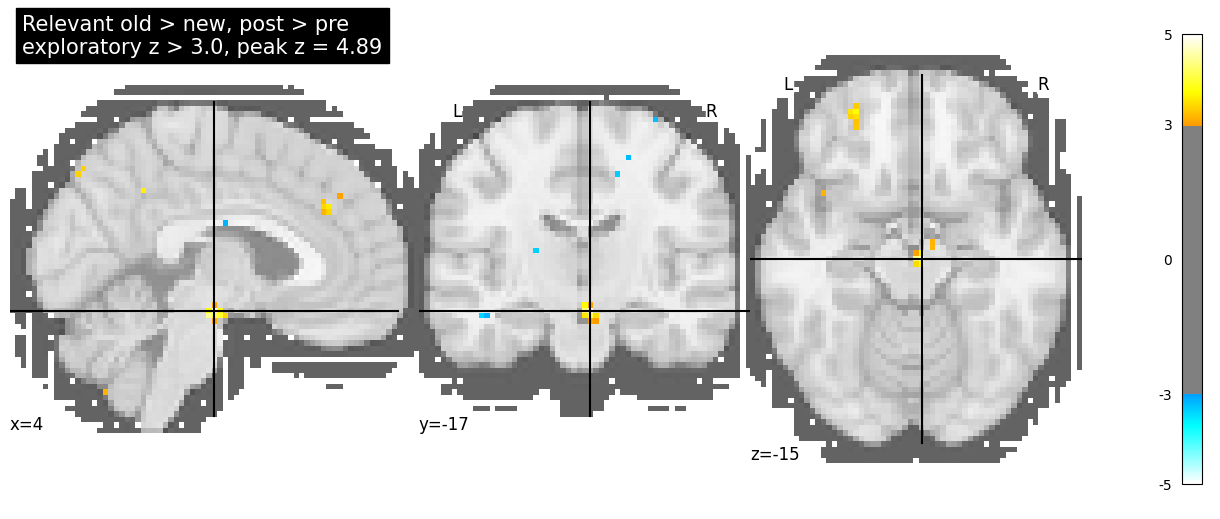

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/key_relevance_contrast_maps/rel_old_vs_new_post_gt_pre_exploratory_zgt_3p0_smoothed5mm.png


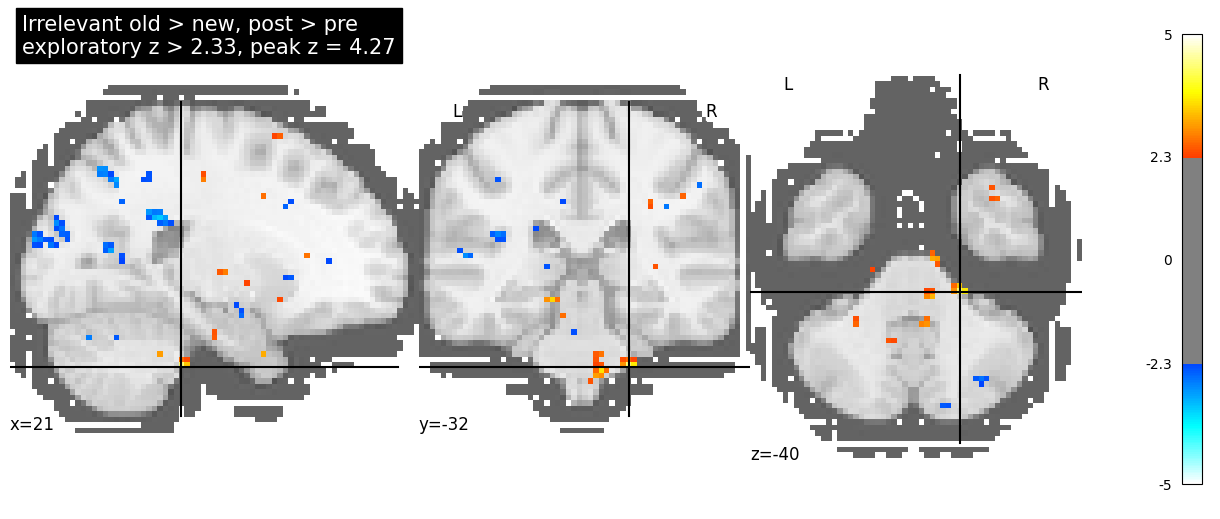

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/key_relevance_contrast_maps/irrel_old_vs_new_post_gt_pre_exploratory_zgt_2p33_smoothed5mm.png


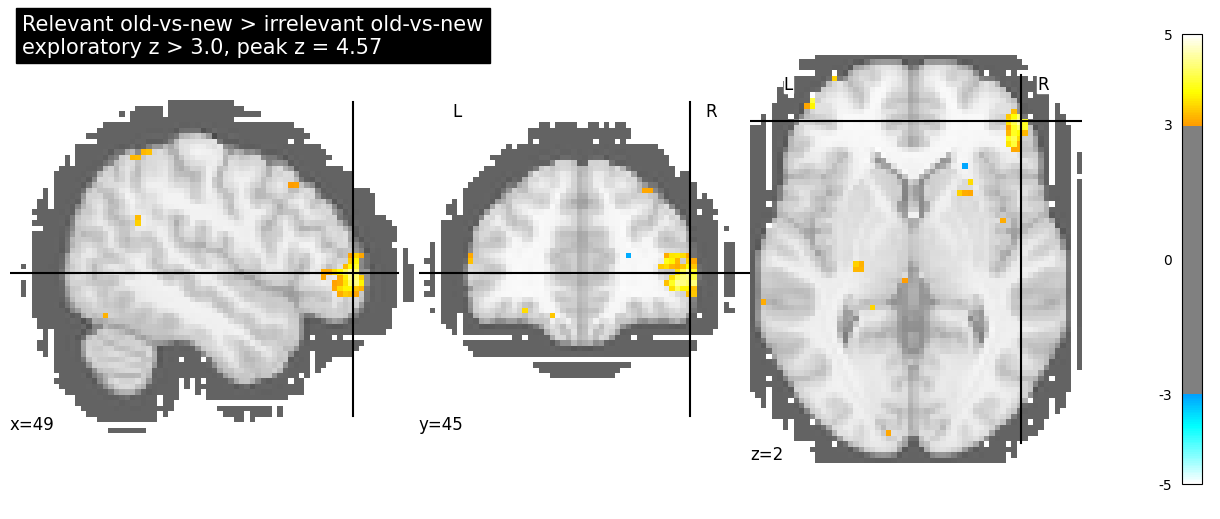

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/key_relevance_contrast_maps/rel_vs_new_gt_irrel_vs_new_post_gt_pre_exploratory_zgt_3p0_smoothed5mm.png


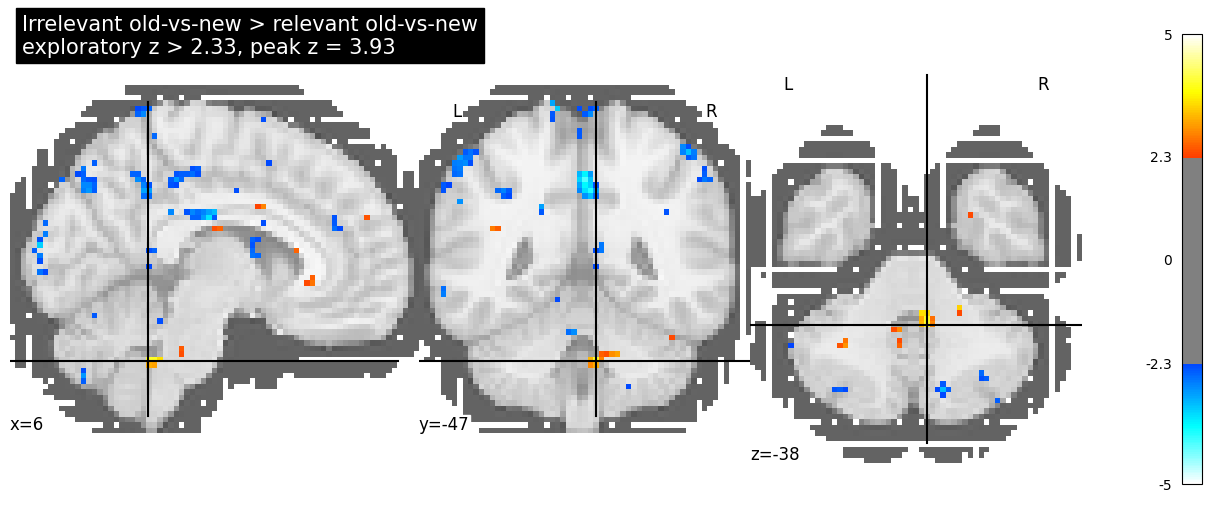

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/figures/key_relevance_contrast_maps/irrel_vs_new_gt_rel_vs_new_post_gt_pre_exploratory_zgt_2p33_smoothed5mm.png


,contrast,title,threshold,cut_coords,peak_z,figure_path
0,rel_old_vs_new_post_gt_pre,"Relevant old > new, post > pre",3.00,"(4.0, -17.0, -15.5)",4.887609,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,irrel_old_vs_new_post_gt_pre,"Irrelevant old > new, post > pre",2.33,"(21.5, -32.0, -40.5)",4.265341,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,rel_vs_new_gt_irrel_vs_new_post_gt_pre,Relevant old-vs-new > irrelevant old-vs-new,3.00,"(49.0, 45.5, 2.0)",4.567430,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,irrel_vs_new_gt_rel_vs_new_post_gt_pre,Irrelevant old-vs-new > relevant old-vs-new,2.33,"(6.5, -47.0, -38.0)",3.931434,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_key_plot_qc_smoothed5mm.csv


In [20]:
# ============================================================
# 19. Plot strongest clusters for key relevance maps
# ============================================================

RELEVANCE_PLOT_DIR = FIG_DIR / "key_relevance_contrast_maps"
RELEVANCE_PLOT_DIR.mkdir(parents=True, exist_ok=True)

mni_template = load_mni152_template(resolution=2)

plot_specs = [
    {
        "contrast": "rel_old_vs_new_post_gt_pre",
        "title": "Relevant old > new, post > pre",
        "threshold": 3.0,
    },
    {
        "contrast": "irrel_old_vs_new_post_gt_pre",
        "title": "Irrelevant old > new, post > pre",
        "threshold": 2.33,
    },
    {
        "contrast": "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
        "title": "Relevant old-vs-new > irrelevant old-vs-new",
        "threshold": 3.0,
    },
    {
        "contrast": "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
        "title": "Irrelevant old-vs-new > relevant old-vs-new",
        "threshold": 2.33,
    },
]

plot_rows = []

for spec in plot_specs:
    contrast_name = spec["contrast"]
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    
    # Use strongest peak from cluster labels if available
    this_clusters = key_cluster_labels.loc[
        key_cluster_labels["contrast"] == contrast_name
    ].copy()
    
    if len(this_clusters) > 0:
        peak_row = this_clusters.sort_values("peak_z", ascending=False).iloc[0]
        cut_coords = (
            float(peak_row["x"]),
            float(peak_row["y"]),
            float(peak_row["z"]),
        )
        peak_z = float(peak_row["peak_z"])
    else:
        cut_coords = None
        peak_z = np.nan
    
    mni_template_resampled = resample_to_img(
        mni_template,
        z_img,
        interpolation="continuous",
        force_resample=True,
        copy_header=True,
    )
    
    fig = plt.figure(figsize=(12, 5))
    
    display_obj = plot_stat_map(
        z_img,
        bg_img=mni_template_resampled,
        display_mode="ortho",
        cut_coords=cut_coords,
        threshold=spec["threshold"],
        vmax=5.0,
        cmap="cold_hot",
        black_bg=False,
        title=(
            f"{spec['title']}\n"
            f"exploratory z > {spec['threshold']}, peak z = {peak_z:.2f}"
        ),
        figure=fig,
    )
    
    fig_path = (
        RELEVANCE_PLOT_DIR
        / f"{contrast_name}_exploratory_zgt_{str(spec['threshold']).replace('.', 'p')}_{SMOOTHING_LABEL}.png"
    )
    
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    plot_rows.append({
        "contrast": contrast_name,
        "title": spec["title"],
        "threshold": spec["threshold"],
        "cut_coords": str(cut_coords),
        "peak_z": peak_z,
        "figure_path": str(fig_path),
    })
    
    print("Saved:", fig_path)

plot_qc = pd.DataFrame(plot_rows)

plot_qc_path = TABLE_DIR / f"pre_post_relevance_old_new_key_plot_qc_{SMOOTHING_LABEL}.csv"
plot_qc.to_csv(plot_qc_path, index=False)

display(plot_qc)
print("Saved:", plot_qc_path)

### Interpretation of the relevance-split GLM

The relevance-split GLM suggests that goal relevance modulated the old-vs-new post-pre memory effect. The relevant old-vs-new contrast showed a stronger and more spatially extended exploratory pattern than the irrelevant old-vs-new contrast. More importantly, the direct interaction:

$$
C_{\mathrm{rel-vs-new}>\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
$$

showed the strongest relevance-related pattern, with a peak in the right frontal pole and additional clusters in precuneus, angular gyrus, and frontal association regions.

This pattern suggests that goal-relevant images were not merely remembered as old stimuli, but may have been preferentially integrated into a task-relevant episodic representation. The frontal pole and frontal association clusters are consistent with goal-directed evaluation or strategic retrieval, while the precuneus and angular gyrus are consistent with spatial-episodic reconstruction and associative memory integration.

However, these results did not survive whole-brain FDR or Bonferroni correction. Therefore, they should be interpreted as exploratory evidence that goal relevance amplifies the neural old-vs-new post-pre memory effect.

In [21]:
# ============================================================
# 20. Extract relevance-split effects in subject-specific hippoAmyg masks
# ============================================================

from nilearn.maskers import NiftiMasker
from scipy import stats

HIPPOAMYG_ROOT = DATA_DIR / "rois" / "hippoAmyg_02022024"

assert HIPPOAMYG_ROOT.exists(), f"Missing hippoAmyg ROI root: {HIPPOAMYG_ROOT}"

ROI_DIR = OUT_DIR / "roi_analyses"
ROI_TABLE_DIR = ROI_DIR / "tables"
ROI_FIG_DIR = ROI_DIR / "figures"

for path in [ROI_DIR, ROI_TABLE_DIR, ROI_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def find_subject_hippoamyg_mask(subject, hemi):
    """
    Find subject-specific hippoAmyg mask.
    hemi should be 'L' or 'R'.
    """
    pattern = (
        f"{subject}/ses-01/anat/"
        f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-{hemi}_label-hippoAmyg*.nii.gz"
    )
    
    matches = sorted(HIPPOAMYG_ROOT.glob(pattern))
    
    assert len(matches) == 1, (
        f"{subject}, hemi-{hemi}: expected 1 mask, found {len(matches)}\n"
        f"Pattern: {pattern}\n"
        f"Matches: {matches}"
    )
    
    return matches[0]


def make_bilateral_mask_img(left_mask_path, right_mask_path, reference_img):
    """
    Resample L/R masks to the target effect-map space and combine them.
    """
    left_img = load_img(str(left_mask_path))
    right_img = load_img(str(right_mask_path))
    
    left_resampled = resample_to_img(
        left_img,
        reference_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    right_resampled = resample_to_img(
        right_img,
        reference_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    bilateral_data = (
        (left_resampled.get_fdata() > 0)
        | (right_resampled.get_fdata() > 0)
    ).astype(np.uint8)
    
    bilateral_img = nib.Nifti1Image(
        bilateral_data,
        reference_img.affine,
        reference_img.header,
    )
    
    return left_resampled, right_resampled, bilateral_img


ROI_CONTRASTS = [
    "rel_old_vs_new_post_gt_pre",
    "irrel_old_vs_new_post_gt_pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
    "oldRel_post_gt_pre",
    "oldIrrel_post_gt_pre",
    "post_oldRel_gt_new",
    "post_oldIrrel_gt_new",
    "pre_oldRel_gt_new",
    "pre_oldIrrel_gt_new",
]

roi_effect_rows = []

for subject in subjects:
    left_mask_path = find_subject_hippoamyg_mask(subject, "L")
    right_mask_path = find_subject_hippoamyg_mask(subject, "R")
    
    for contrast_name in ROI_CONTRASTS:
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        assert effect_path.exists(), f"Missing effect map: {effect_path}"
        
        effect_img = load_img(str(effect_path))
        
        left_mask_img, right_mask_img, bilateral_mask_img = make_bilateral_mask_img(
            left_mask_path,
            right_mask_path,
            effect_img,
        )
        
        roi_imgs = {
            "left_hippoAmyg": left_mask_img,
            "right_hippoAmyg": right_mask_img,
            "bilateral_hippoAmyg": bilateral_mask_img,
        }
        
        for roi_name, roi_img in roi_imgs.items():
            masker = NiftiMasker(mask_img=roi_img)
            
            values = masker.fit_transform(effect_img)
            
            # values shape usually = (1, n_voxels)
            mean_effect = float(np.nanmean(values))
            
            roi_effect_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "priority": CONTRAST_PRIORITY[contrast_name],
                "formula": CONTRAST_FORMULAS[contrast_name],
                "roi": roi_name,
                "mean_effect": mean_effect,
                "left_mask_path": str(left_mask_path),
                "right_mask_path": str(right_mask_path),
                "effect_map_path": str(effect_path),
            })

hippoamyg_roi_effects = pd.DataFrame(roi_effect_rows)

hippoamyg_roi_effects_path = (
    ROI_TABLE_DIR
    / f"pre_post_relevance_old_new_hippoAmyg_subject_effects_{SMOOTHING_LABEL}.csv"
)

hippoamyg_roi_effects.to_csv(hippoamyg_roi_effects_path, index=False)

display(hippoamyg_roi_effects.head())

print("Saved:", hippoamyg_roi_effects_path)

/tmp/ipykernel_657410/995185139.py:118: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img)
/tmp/ipykernel_657410/995185139.py:118: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img)
/tmp/ipykernel_657410/995185139.py:118: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img)
/tmp/ipykernel_657410/995185139.py:118: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img)
/tmp/ipykernel_657410/995185139.py:118: UserWarn

,subject,contrast,priority,formula,roi,mean_effect,left_mask_path,right_mask_path,effect_map_path
0,sub-P10,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",left_hippoAmyg,-0.010660,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P10,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",right_hippoAmyg,0.017518,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P10,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",bilateral_hippoAmyg,0.003476,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P10,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",left_hippoAmyg,0.004997,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P10,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",right_hippoAmyg,-0.001647,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/roi_analyses/tables/pre_post_relevance_old_new_hippoAmyg_subject_effects_smoothed5mm.csv


,contrast,priority,formula,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive
0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",bilateral_hippoAmyg,27,0.000303,0.035412,0.006815,0.044413,0.964914,0.482457,15,0.555556
1,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",left_hippoAmyg,27,0.001894,0.040457,0.007786,0.243254,0.809718,0.404859,15,0.555556
2,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",right_hippoAmyg,27,-0.001124,0.034966,0.006729,-0.166979,0.868678,0.565661,14,0.518519
3,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",bilateral_hippoAmyg,27,-0.000116,0.030858,0.005939,-0.019596,0.984516,0.507742,12,0.444444
4,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",left_hippoAmyg,27,-0.001165,0.033100,0.006370,-0.182812,0.856364,0.571818,14,0.518519
5,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",right_hippoAmyg,27,0.000937,0.034563,0.006652,0.140934,0.889008,0.444504,13,0.481481
6,oldIrrel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",bilateral_hippoAmyg,27,0.008924,0.080154,0.015426,0.578510,0.567898,0.283949,15,0.555556
7,oldIrrel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",left_hippoAmyg,27,0.007061,0.082419,0.015861,0.445193,0.659865,0.329933,15,0.555556
8,oldIrrel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",right_hippoAmyg,27,0.010912,0.082949,0.015964,0.683567,0.500296,0.250148,14,0.518519
9,oldRel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{...",bilateral_hippoAmyg,27,0.009040,0.084678,0.016296,0.554747,0.583809,0.291904,13,0.481481


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/roi_analyses/tables/pre_post_relevance_old_new_hippoAmyg_roi_summary_smoothed5mm.csv


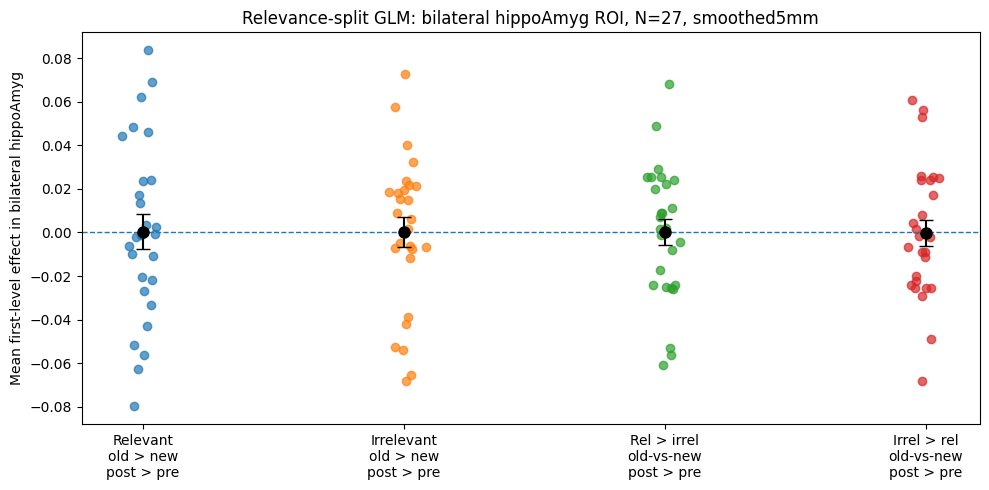

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/roi_analyses/figures/pre_post_relevance_old_new_bilateral_hippoAmyg_key_contrasts_smoothed5mm.png

Key bilateral hippoAmyg ROI summary:


,contrast,priority,roi,n_subjects,mean_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive
0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,bilateral_hippoAmyg,27,0.000303,0.006815,0.044413,0.964914,0.482457,15,0.555556
3,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,bilateral_hippoAmyg,27,-0.000116,0.005939,-0.019596,0.984516,0.507742,12,0.444444
24,rel_old_vs_new_post_gt_pre,primary_relevance_specific,bilateral_hippoAmyg,27,0.000419,0.007962,0.052629,0.958430,0.479215,12,0.444444
27,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,bilateral_hippoAmyg,27,0.000116,0.005939,0.019596,0.984516,0.492258,15,0.555556


In [22]:
# ============================================================
# 21. Group statistics for hippoAmyg ROI
# ============================================================

hippoamyg_summary_rows = []

for (contrast_name, roi_name), df in hippoamyg_roi_effects.groupby(["contrast", "roi"]):
    effects = df["mean_effect"].dropna().values
    
    t_stat, p_two = stats.ttest_1samp(effects, popmean=0.0)
    
    if np.isfinite(t_stat):
        if t_stat > 0:
            p_one_pos = p_two / 2
        else:
            p_one_pos = 1 - (p_two / 2)
    else:
        p_one_pos = np.nan
    
    hippoamyg_summary_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "roi": roi_name,
        "n_subjects": len(effects),
        "mean_effect": float(np.mean(effects)),
        "sd_effect": float(np.std(effects, ddof=1)),
        "sem_effect": float(stats.sem(effects)),
        "t_stat": float(t_stat),
        "p_two_sided": float(p_two),
        "p_one_sided_positive": float(p_one_pos),
        "n_positive": int(np.sum(effects > 0)),
        "proportion_positive": float(np.mean(effects > 0)),
    })

hippoamyg_roi_summary = pd.DataFrame(hippoamyg_summary_rows)

hippoamyg_roi_summary_path = (
    ROI_TABLE_DIR
    / f"pre_post_relevance_old_new_hippoAmyg_roi_summary_{SMOOTHING_LABEL}.csv"
)

hippoamyg_roi_summary.to_csv(hippoamyg_roi_summary_path, index=False)

display(
    hippoamyg_roi_summary.sort_values(
        ["contrast", "roi"]
    )
)

print("Saved:", hippoamyg_roi_summary_path)


# ------------------------------------------------------------
# Plot key contrasts in bilateral hippoAmyg
# ------------------------------------------------------------

plot_contrasts = [
    "rel_old_vs_new_post_gt_pre",
    "irrel_old_vs_new_post_gt_pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
]

plot_df = hippoamyg_roi_effects.loc[
    (hippoamyg_roi_effects["roi"] == "bilateral_hippoAmyg")
    & (hippoamyg_roi_effects["contrast"].isin(plot_contrasts))
].copy()

label_map = {
    "rel_old_vs_new_post_gt_pre": "Relevant\nold > new\npost > pre",
    "irrel_old_vs_new_post_gt_pre": "Irrelevant\nold > new\npost > pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre": "Rel > irrel\nold-vs-new\npost > pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre": "Irrel > rel\nold-vs-new\npost > pre",
}

plot_df["contrast_label"] = plot_df["contrast"].map(label_map)

fig, ax = plt.subplots(figsize=(10, 5))

x_positions = np.arange(len(plot_contrasts))

rng = np.random.default_rng(42)

for i, contrast_name in enumerate(plot_contrasts):
    values = plot_df.loc[
        plot_df["contrast"] == contrast_name,
        "mean_effect",
    ].values
    
    jitter = rng.normal(0, 0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), i) + jitter,
        values,
        alpha=0.7,
    )
    
    mean_val = np.mean(values)
    sem_val = stats.sem(values)
    
    ax.errorbar(
        i,
        mean_val,
        yerr=sem_val,
        fmt="o",
        markersize=8,
        capsize=5,
        color="black",
    )

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x_positions)
ax.set_xticklabels([label_map[c] for c in plot_contrasts])
ax.set_ylabel("Mean first-level effect in bilateral hippoAmyg")
ax.set_title(
    f"Relevance-split GLM: bilateral hippoAmyg ROI, N={len(subjects)}, {SMOOTHING_LABEL}"
)

plt.tight_layout()

hippoamyg_plot_path = (
    ROI_FIG_DIR
    / f"pre_post_relevance_old_new_bilateral_hippoAmyg_key_contrasts_{SMOOTHING_LABEL}.png"
)

fig.savefig(hippoamyg_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", hippoamyg_plot_path)


print("\nKey bilateral hippoAmyg ROI summary:")
display(
    hippoamyg_roi_summary.loc[
        (hippoamyg_roi_summary["roi"] == "bilateral_hippoAmyg")
        & (hippoamyg_roi_summary["contrast"].isin(plot_contrasts))
    ][
        [
            "contrast",
            "priority",
            "roi",
            "n_subjects",
            "mean_effect",
            "sem_effect",
            "t_stat",
            "p_two_sided",
            "p_one_sided_positive",
            "n_positive",
            "proportion_positive",
        ]
    ]
)

In [23]:
# ============================================================
# 22. Extract relevance effects in right anterior PHC 6 mm sphere
# ============================================================

from nilearn.maskers import NiftiSpheresMasker

SPHERE_ROI_DIR = OUT_DIR / "sphere_roi_analyses"
SPHERE_ROI_TABLE_DIR = SPHERE_ROI_DIR / "tables"
SPHERE_ROI_FIG_DIR = SPHERE_ROI_DIR / "figures"

for path in [SPHERE_ROI_DIR, SPHERE_ROI_TABLE_DIR, SPHERE_ROI_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RIGHT_ANTERIOR_PHC_PEAK = (19.0, -14.5, -28.0)
SPHERE_RADIUS_MM = 6.0

sphere_roi_rows = []

for subject in subjects:
    for contrast_name in ROI_CONTRASTS:
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        assert effect_path.exists(), f"Missing effect map: {effect_path}"
        
        effect_img = load_img(str(effect_path))
        
        sphere_masker = NiftiSpheresMasker(
            seeds=[RIGHT_ANTERIOR_PHC_PEAK],
            radius=SPHERE_RADIUS_MM,
            detrend=False,
            standardize=False,
        )
        
        values = sphere_masker.fit_transform(effect_img)
        values = np.asarray(values)
        
        # Robust extraction: can be shape (1, 1) or (1,)
        mean_effect = float(values.ravel()[0])
        
        sphere_roi_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "formula": CONTRAST_FORMULAS[contrast_name],
            "roi": "right_anterior_phc_sphere_6mm",
            "mean_effect": mean_effect,
            "sphere_x": RIGHT_ANTERIOR_PHC_PEAK[0],
            "sphere_y": RIGHT_ANTERIOR_PHC_PEAK[1],
            "sphere_z": RIGHT_ANTERIOR_PHC_PEAK[2],
            "sphere_radius_mm": SPHERE_RADIUS_MM,
            "effect_map_path": str(effect_path),
        })

phc_sphere_effects = pd.DataFrame(sphere_roi_rows)

phc_sphere_effects_path = (
    SPHERE_ROI_TABLE_DIR
    / f"pre_post_relevance_old_new_right_anterior_phc_sphere_subject_effects_{SMOOTHING_LABEL}.csv"
)

phc_sphere_effects.to_csv(phc_sphere_effects_path, index=False)

display(phc_sphere_effects.head())

print("Saved:", phc_sphere_effects_path)

,subject,contrast,priority,formula,roi,mean_effect,sphere_x,sphere_y,sphere_z,sphere_radius_mm,effect_map_path
0,sub-P10,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",right_anterior_phc_sphere_6mm,0.017900,19.0,-14.5,-28.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P10,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",right_anterior_phc_sphere_6mm,0.047225,19.0,-14.5,-28.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P10,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",right_anterior_phc_sphere_6mm,-0.029325,19.0,-14.5,-28.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P10,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",right_anterior_phc_sphere_6mm,0.029325,19.0,-14.5,-28.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P10,oldRel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{...",right_anterior_phc_sphere_6mm,0.107987,19.0,-14.5,-28.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/sphere_roi_analyses/tables/pre_post_relevance_old_new_right_anterior_phc_sphere_subject_effects_smoothed5mm.csv


,contrast,priority,formula,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive,sphere_x,sphere_y,sphere_z,sphere_radius_mm
0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",right_anterior_phc_sphere_6mm,27,0.035204,0.059635,0.011477,3.067385,0.004994,0.002497,19,0.703704,19.0,-14.5,-28.0,6.0
1,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",right_anterior_phc_sphere_6mm,27,0.010135,0.046099,0.008872,1.142344,0.263722,0.131861,16,0.592593,19.0,-14.5,-28.0,6.0
2,oldIrrel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",right_anterior_phc_sphere_6mm,27,0.030378,0.131570,0.025321,1.199733,0.241062,0.120531,12,0.444444,19.0,-14.5,-28.0,6.0
3,oldRel_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{...",right_anterior_phc_sphere_6mm,27,0.020244,0.142045,0.027337,0.740530,0.465614,0.232807,11,0.407407,19.0,-14.5,-28.0,6.0
4,post_oldIrrel_gt_new,descriptive_post_only,"$$\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathr...",right_anterior_phc_sphere_6mm,27,0.038351,0.082628,0.015902,2.411738,0.023235,0.011618,17,0.629630,19.0,-14.5,-28.0,6.0
5,post_oldRel_gt_new,descriptive_post_only,"$$\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{...",right_anterior_phc_sphere_6mm,27,0.046830,0.092321,0.017767,2.635761,0.013968,0.006984,17,0.629630,19.0,-14.5,-28.0,6.0
6,pre_oldIrrel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldIrrel}}-\beta_{\mathrm...",right_anterior_phc_sphere_6mm,27,-0.032057,0.092210,0.017746,-1.806431,0.082440,0.958780,11,0.407407,19.0,-14.5,-28.0,6.0
7,pre_oldRel_gt_new,baseline_pre_only,"$$\beta_{\mathrm{pre,oldRel}}-\beta_{\mathrm{p...",right_anterior_phc_sphere_6mm,27,-0.003308,0.096480,0.018568,-0.178177,0.859965,0.570017,13,0.481481,19.0,-14.5,-28.0,6.0
8,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",right_anterior_phc_sphere_6mm,27,0.025069,0.067339,0.012959,1.934445,0.064011,0.032005,16,0.592593,19.0,-14.5,-28.0,6.0
9,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",right_anterior_phc_sphere_6mm,27,-0.010135,0.046099,0.008872,-1.142344,0.263722,0.868139,11,0.407407,19.0,-14.5,-28.0,6.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/sphere_roi_analyses/tables/pre_post_relevance_old_new_right_anterior_phc_sphere_summary_smoothed5mm.csv


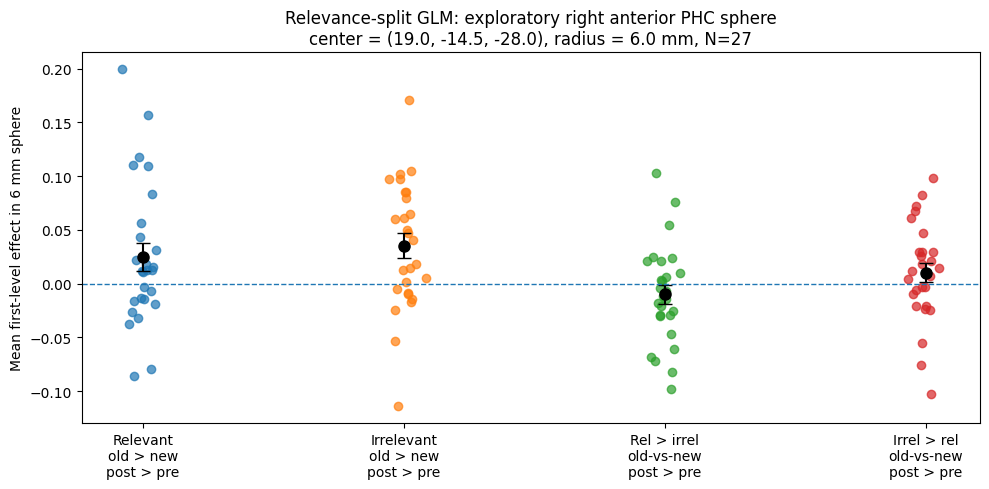

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/sphere_roi_analyses/figures/pre_post_relevance_old_new_right_anterior_phc_sphere_key_contrasts_smoothed5mm.png

Key right anterior PHC sphere summary:


,contrast,priority,roi,n_subjects,mean_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive
0,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,right_anterior_phc_sphere_6mm,27,0.035204,0.011477,3.067385,0.004994,0.002497,19,0.703704
1,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,right_anterior_phc_sphere_6mm,27,0.010135,0.008872,1.142344,0.263722,0.131861,16,0.592593
8,rel_old_vs_new_post_gt_pre,primary_relevance_specific,right_anterior_phc_sphere_6mm,27,0.025069,0.012959,1.934445,0.064011,0.032005,16,0.592593
9,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,right_anterior_phc_sphere_6mm,27,-0.010135,0.008872,-1.142344,0.263722,0.868139,11,0.407407


In [24]:
# ============================================================
# 23. Group statistics for right anterior PHC sphere
# ============================================================

phc_sphere_summary_rows = []

for contrast_name, df in phc_sphere_effects.groupby("contrast"):
    effects = df["mean_effect"].dropna().values
    
    t_stat, p_two = stats.ttest_1samp(effects, popmean=0.0)
    
    if np.isfinite(t_stat):
        if t_stat > 0:
            p_one_pos = p_two / 2
        else:
            p_one_pos = 1 - (p_two / 2)
    else:
        p_one_pos = np.nan
    
    phc_sphere_summary_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "roi": "right_anterior_phc_sphere_6mm",
        "n_subjects": len(effects),
        "mean_effect": float(np.mean(effects)),
        "sd_effect": float(np.std(effects, ddof=1)),
        "sem_effect": float(stats.sem(effects)),
        "t_stat": float(t_stat),
        "p_two_sided": float(p_two),
        "p_one_sided_positive": float(p_one_pos),
        "n_positive": int(np.sum(effects > 0)),
        "proportion_positive": float(np.mean(effects > 0)),
        "sphere_x": RIGHT_ANTERIOR_PHC_PEAK[0],
        "sphere_y": RIGHT_ANTERIOR_PHC_PEAK[1],
        "sphere_z": RIGHT_ANTERIOR_PHC_PEAK[2],
        "sphere_radius_mm": SPHERE_RADIUS_MM,
    })

phc_sphere_summary = pd.DataFrame(phc_sphere_summary_rows)

phc_sphere_summary_path = (
    SPHERE_ROI_TABLE_DIR
    / f"pre_post_relevance_old_new_right_anterior_phc_sphere_summary_{SMOOTHING_LABEL}.csv"
)

phc_sphere_summary.to_csv(phc_sphere_summary_path, index=False)

display(
    phc_sphere_summary.sort_values("contrast")
)

print("Saved:", phc_sphere_summary_path)


# ------------------------------------------------------------
# Plot key relevance contrasts in PHC sphere
# ------------------------------------------------------------

plot_contrasts = [
    "rel_old_vs_new_post_gt_pre",
    "irrel_old_vs_new_post_gt_pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
]

plot_df = phc_sphere_effects.loc[
    phc_sphere_effects["contrast"].isin(plot_contrasts)
].copy()

label_map = {
    "rel_old_vs_new_post_gt_pre": "Relevant\nold > new\npost > pre",
    "irrel_old_vs_new_post_gt_pre": "Irrelevant\nold > new\npost > pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre": "Rel > irrel\nold-vs-new\npost > pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre": "Irrel > rel\nold-vs-new\npost > pre",
}

fig, ax = plt.subplots(figsize=(10, 5))

x_positions = np.arange(len(plot_contrasts))
rng = np.random.default_rng(42)

for i, contrast_name in enumerate(plot_contrasts):
    values = plot_df.loc[
        plot_df["contrast"] == contrast_name,
        "mean_effect",
    ].values
    
    jitter = rng.normal(0, 0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), i) + jitter,
        values,
        alpha=0.7,
    )
    
    mean_val = np.mean(values)
    sem_val = stats.sem(values)
    
    ax.errorbar(
        i,
        mean_val,
        yerr=sem_val,
        fmt="o",
        markersize=8,
        capsize=5,
        color="black",
    )

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x_positions)
ax.set_xticklabels([label_map[c] for c in plot_contrasts])
ax.set_ylabel("Mean first-level effect in 6 mm sphere")
ax.set_title(
    "Relevance-split GLM: exploratory right anterior PHC sphere\n"
    f"center = {RIGHT_ANTERIOR_PHC_PEAK}, radius = {SPHERE_RADIUS_MM} mm, N={len(subjects)}"
)

plt.tight_layout()

phc_sphere_plot_path = (
    SPHERE_ROI_FIG_DIR
    / f"pre_post_relevance_old_new_right_anterior_phc_sphere_key_contrasts_{SMOOTHING_LABEL}.png"
)

fig.savefig(phc_sphere_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", phc_sphere_plot_path)


print("\nKey right anterior PHC sphere summary:")
display(
    phc_sphere_summary.loc[
        phc_sphere_summary["contrast"].isin(plot_contrasts)
    ][
        [
            "contrast",
            "priority",
            "roi",
            "n_subjects",
            "mean_effect",
            "sem_effect",
            "t_stat",
            "p_two_sided",
            "p_one_sided_positive",
            "n_positive",
            "proportion_positive",
        ]
    ]
)

The right anterior PHC sphere showed a positive old-vs-new post-pre effect for irrelevant images:

$$
C_{\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

This contrast was positive in the PHC sphere:

$$
t(26)=3.07,\quad p_{\mathrm{two-sided}}=.00499.
$$

The corresponding relevant contrast was weaker:

$$
C_{\mathrm{rel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}),
$$

with:

$$
t(26)=1.93,\quad p_{\mathrm{two-sided}}=.064.
$$

The direct relevance interaction was not significant:

$$
C_{\mathrm{rel>irrel}}
=
C_{\mathrm{rel-vs-new}} - C_{\mathrm{irrel-vs-new}},
$$

with:

$$
t(26)=-1.14,\quad p_{\mathrm{two-sided}}=.264.
$$

In [26]:
# ============================================================
# 24. Find strongest peaks inside group hippoAmyg mask
# ============================================================

from nilearn.image import load_img, resample_to_img, new_img_like
from scipy import stats
import numpy as np
import pandas as pd
import nibabel as nib

HIPPOAMYG_ROOT = DATA_DIR / "rois" / "hippoAmyg_02022024"
assert HIPPOAMYG_ROOT.exists(), f"Missing ROI directory: {HIPPOAMYG_ROOT}"

SVC_DIR = OUT_DIR / "small_volume_correction"
SVC_MASK_DIR = SVC_DIR / "masks"
SVC_TABLE_DIR = SVC_DIR / "tables"
SVC_FIG_DIR = SVC_DIR / "figures"

for path in [SVC_DIR, SVC_MASK_DIR, SVC_TABLE_DIR, SVC_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

KEY_RELEVANCE_CONTRASTS = [
    "rel_old_vs_new_post_gt_pre",
    "irrel_old_vs_new_post_gt_pre",
    "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
    "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
]

GROUP_ROI_PROB_THRESHOLD = 0.25

reference_img = load_img(str(get_group_z_map_path("rel_old_vs_new_post_gt_pre")))


def find_subject_hippoamyg_mask(subject, hemi):
    pattern = (
        f"{subject}/ses-01/anat/"
        f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-{hemi}_label-hippoAmyg*.nii.gz"
    )
    matches = sorted(HIPPOAMYG_ROOT.glob(pattern))
    assert len(matches) == 1, f"{subject}, hemi-{hemi}: found {len(matches)} masks"
    return matches[0]


# ------------------------------------------------------------
# Build group probability mask from all subject-specific masks
# ------------------------------------------------------------

subject_mask_arrays = []

for subject in subjects:
    left_mask_path = find_subject_hippoamyg_mask(subject, "L")
    right_mask_path = find_subject_hippoamyg_mask(subject, "R")
    
    left_img = load_img(str(left_mask_path))
    right_img = load_img(str(right_mask_path))
    
    left_resampled = resample_to_img(
        left_img,
        reference_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    right_resampled = resample_to_img(
        right_img,
        reference_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    bilateral_data = (
        (left_resampled.get_fdata() > 0)
        | (right_resampled.get_fdata() > 0)
    ).astype(float)
    
    subject_mask_arrays.append(bilateral_data)

group_probability_data = np.mean(subject_mask_arrays, axis=0)

group_probability_img = new_img_like(
    reference_img,
    group_probability_data,
)

group_probability_path = (
    SVC_MASK_DIR
    / f"group_bilateral_hippoAmyg_probability_map_{SMOOTHING_LABEL}.nii.gz"
)

group_probability_img.to_filename(str(group_probability_path))

group_mask_data = (group_probability_data >= GROUP_ROI_PROB_THRESHOLD).astype(np.uint8)

group_mask_img = new_img_like(
    reference_img,
    group_mask_data,
)

group_mask_path = (
    SVC_MASK_DIR
    / f"group_bilateral_hippoAmyg_probability_threshold_{GROUP_ROI_PROB_THRESHOLD}_{SMOOTHING_LABEL}.nii.gz"
)

group_mask_img.to_filename(str(group_mask_path))

print("Saved group probability map:", group_probability_path)
print("Saved group binary mask:", group_mask_path)
print("Group mask voxels:", int(group_mask_data.sum()))


# ------------------------------------------------------------
# Find strongest z peak inside the group hippoAmyg mask
# ------------------------------------------------------------

peak_rows = []

mask_bool = group_mask_data.astype(bool)
voxel_indices = np.argwhere(mask_bool)

for contrast_name in KEY_RELEVANCE_CONTRASTS:
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    z_data = z_img.get_fdata()
    
    z_inside = z_data[mask_bool]
    
    finite_mask = np.isfinite(z_inside)
    z_inside_finite = z_inside[finite_mask]
    
    if len(z_inside_finite) == 0:
        peak_rows.append({
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "n_mask_voxels": int(mask_bool.sum()),
            "max_z_inside_hippoAmyg": np.nan,
            "peak_x": np.nan,
            "peak_y": np.nan,
            "peak_z": np.nan,
            "peak_voxel_i": np.nan,
            "peak_voxel_j": np.nan,
            "peak_voxel_k": np.nan,
            "note": "No finite z values inside mask",
        })
        continue
    
    # Index of maximum positive z inside mask
    finite_voxel_indices = voxel_indices[finite_mask]
    max_idx = int(np.argmax(z_inside_finite))
    
    peak_voxel = finite_voxel_indices[max_idx]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_voxel)
    max_z = float(z_inside_finite[max_idx])
    
    peak_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "n_mask_voxels": int(mask_bool.sum()),
        "max_z_inside_hippoAmyg": max_z,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z": float(peak_mni[2]),
        "peak_voxel_i": int(peak_voxel[0]),
        "peak_voxel_j": int(peak_voxel[1]),
        "peak_voxel_k": int(peak_voxel[2]),
        "note": "Peak selected inside group hippoAmyg mask",
    })

hippoamyg_within_mask_peaks = pd.DataFrame(peak_rows)

within_mask_peaks_path = (
    SVC_TABLE_DIR
    / f"within_group_hippoAmyg_peak_search_key_relevance_contrasts_{SMOOTHING_LABEL}.csv"
)

hippoamyg_within_mask_peaks.to_csv(within_mask_peaks_path, index=False)

display(
    hippoamyg_within_mask_peaks.sort_values(
        "max_z_inside_hippoAmyg",
        ascending=False,
    )
)

print("Saved:", within_mask_peaks_path)

Saved group probability map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/masks/group_bilateral_hippoAmyg_probability_map_smoothed5mm.nii.gz
Saved group binary mask: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/masks/group_bilateral_hippoAmyg_probability_threshold_0.25_smoothed5mm.nii.gz
Group mask voxels: 1113


,contrast,priority,formula,n_mask_voxels,max_z_inside_hippoAmyg,peak_x,peak_y,peak_z,peak_voxel_i,peak_voxel_j,peak_voxel_k,note
1,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",1113,3.878252,34.0,-12.0,-18.0,44,40,23,Peak selected inside group hippoAmyg mask
2,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",1113,3.432898,-18.5,-39.5,2.0,23,29,31,Peak selected inside group hippoAmyg mask
0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",1113,2.607225,-18.5,-39.5,-0.5,23,29,30,Peak selected inside group hippoAmyg mask
3,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",1113,2.505158,34.0,-12.0,-18.0,44,40,23,Peak selected inside group hippoAmyg mask


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/tables/within_group_hippoAmyg_peak_search_key_relevance_contrasts_smoothed5mm.csv


In [27]:
# ============================================================
# 25. Anatomical SVC inside group hippoAmyg mask
# ============================================================

from scipy.stats import norm

svc_rows = []

mask_bool = group_mask_data.astype(bool)
n_svc_voxels = int(mask_bool.sum())

for contrast_name in KEY_RELEVANCE_CONTRASTS:
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    z_data = z_img.get_fdata()
    
    z_inside = z_data[mask_bool]
    finite = np.isfinite(z_inside)
    z_inside = z_inside[finite]
    
    if len(z_inside) == 0:
        continue
    
    max_idx_inside = int(np.argmax(z_inside))
    peak_stat_z = float(z_inside[max_idx_inside])
    
    # Need original voxel coordinate of the peak
    finite_voxel_indices = voxel_indices[finite]
    peak_voxel = finite_voxel_indices[max_idx_inside]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_voxel)
    
    # One-sided p-values
    p_unc = float(norm.sf(peak_stat_z))
    
    # Bonferroni SVC over anatomical ROI voxels
    p_bonf_svc = min(p_unc * n_svc_voxels, 1.0)
    bonf_z_threshold = float(norm.isf(0.05 / n_svc_voxels))
    
    # FDR SVC over anatomical ROI voxels
    p_values = norm.sf(z_inside)
    order = np.argsort(p_values)
    ranked_p = p_values[order]
    ranks = np.arange(1, len(ranked_p) + 1)
    q_values_sorted = ranked_p * len(ranked_p) / ranks
    q_values_sorted = np.minimum.accumulate(q_values_sorted[::-1])[::-1]
    
    q_values = np.empty_like(q_values_sorted)
    q_values[order] = q_values_sorted
    
    peak_q_fdr = float(q_values[max_idx_inside])
    
    svc_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "svc_type": "anatomical_group_hippoAmyg_mask",
        "group_mask_probability_threshold": GROUP_ROI_PROB_THRESHOLD,
        "n_svc_voxels": n_svc_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_stat_z": peak_stat_z,
        "peak_p_uncorrected_one_sided": p_unc,
        "peak_p_bonferroni_svc_one_sided": p_bonf_svc,
        "peak_q_fdr_svc_one_sided": peak_q_fdr,
        "bonferroni_svc_z_threshold_p05": bonf_z_threshold,
        "survives_bonferroni_svc_p05": bool(peak_stat_z >= bonf_z_threshold),
        "survives_fdr_svc_q05": bool(peak_q_fdr <= 0.05),
        "interpretation": "Anatomical SVC inside group hippoAmyg mask.",
    })

anatomical_hippoamyg_svc = pd.DataFrame(svc_rows)

anatomical_hippoamyg_svc_path = (
    SVC_TABLE_DIR
    / f"anatomical_group_hippoAmyg_svc_key_relevance_contrasts_{SMOOTHING_LABEL}.csv"
)

anatomical_hippoamyg_svc.to_csv(anatomical_hippoamyg_svc_path, index=False)

display(
    anatomical_hippoamyg_svc.sort_values(
        "peak_stat_z",
        ascending=False,
    )
)

print("Saved:", anatomical_hippoamyg_svc_path)

,contrast,priority,formula,svc_type,group_mask_probability_threshold,n_svc_voxels,peak_x,peak_y,peak_z_coord,peak_stat_z,peak_p_uncorrected_one_sided,peak_p_bonferroni_svc_one_sided,peak_q_fdr_svc_one_sided,bonferroni_svc_z_threshold_p05,survives_bonferroni_svc_p05,survives_fdr_svc_q05,interpretation
1,irrel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldIrrel}}-\beta_{\math...",anatomical_group_hippoAmyg_mask,0.25,1113,34.0,-12.0,-18.0,3.878252,0.000053,0.058549,0.058549,3.916491,False,False,Anatomical SVC inside group hippoAmyg mask.
2,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",anatomical_group_hippoAmyg_mask,0.25,1113,-18.5,-39.5,2.0,3.432898,0.000299,0.332324,0.332324,3.916491,False,False,Anatomical SVC inside group hippoAmyg mask.
0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",anatomical_group_hippoAmyg_mask,0.25,1113,-18.5,-39.5,-0.5,2.607225,0.004564,1.000000,0.851027,3.916491,False,False,Anatomical SVC inside group hippoAmyg mask.
3,irrel_vs_new_gt_rel_vs_new_post_gt_pre,reverse_interaction,"$$[(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mat...",anatomical_group_hippoAmyg_mask,0.25,1113,34.0,-12.0,-18.0,2.505158,0.006120,1.000000,0.975363,3.916491,False,False,Anatomical SVC inside group hippoAmyg mask.


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/tables/anatomical_group_hippoAmyg_svc_key_relevance_contrasts_smoothed5mm.csv


Best within-hippoAmyg peak:
Contrast: irrel_old_vs_new_post_gt_pre
Peak: (34.0, -12.0, -18.0)
Peak z: 3.8782522678375244
Saved sphere: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/masks/within_hippoAmyg_peak_sphere_6mm_irrel_old_vs_new_post_gt_pre_34p0_m12p0_m18p0_smoothed5mm.nii.gz
Sphere voxels: 57


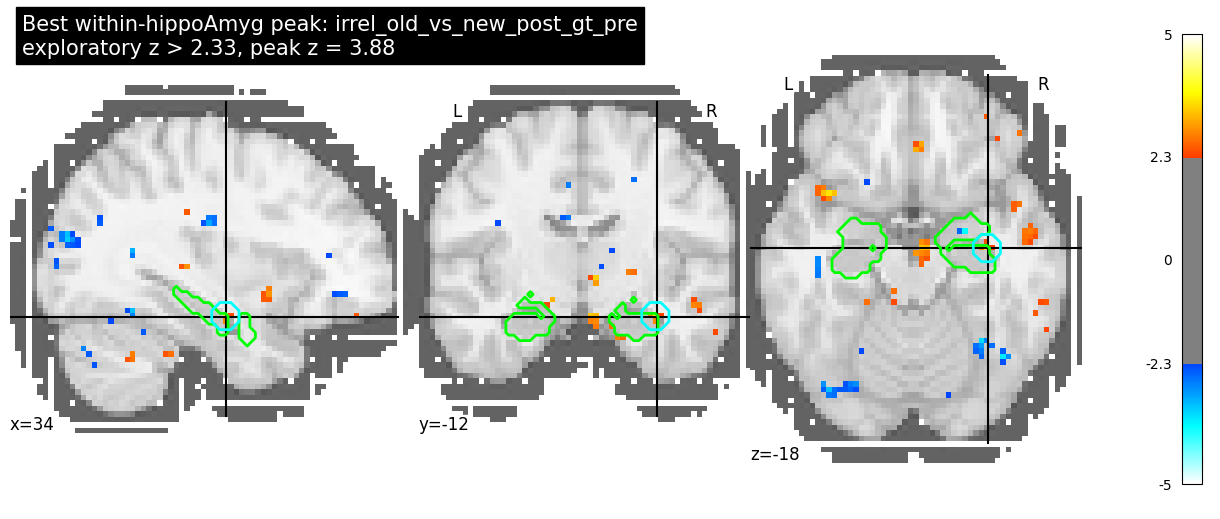

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/figures/within_hippoAmyg_peak_sphere_6mm_irrel_old_vs_new_post_gt_pre_smoothed5mm.png


In [28]:
# ============================================================
# 26. Build and plot sphere around best within-hippoAmyg peak
# ============================================================

from nilearn.plotting import plot_stat_map
from nilearn.datasets import load_mni152_template

SPHERE_RADIUS_MM = 6.0

# Choose best peak from anatomical SVC table
best_peak = anatomical_hippoamyg_svc.sort_values(
    "peak_stat_z",
    ascending=False,
).iloc[0]

BEST_HIPPOAMYG_CONTRAST = best_peak["contrast"]
BEST_HIPPOAMYG_PEAK = (
    float(best_peak["peak_x"]),
    float(best_peak["peak_y"]),
    float(best_peak["peak_z_coord"]),
)

print("Best within-hippoAmyg peak:")
print("Contrast:", BEST_HIPPOAMYG_CONTRAST)
print("Peak:", BEST_HIPPOAMYG_PEAK)
print("Peak z:", best_peak["peak_stat_z"])

z_img = load_img(str(get_group_z_map_path(BEST_HIPPOAMYG_CONTRAST)))

shape = z_img.shape
affine = z_img.affine

voxel_coords = np.indices(shape).reshape(3, -1).T
world_coords = nib.affines.apply_affine(affine, voxel_coords)

distances = np.sqrt(
    np.sum(
        (world_coords - np.array(BEST_HIPPOAMYG_PEAK)) ** 2,
        axis=1,
    )
)

sphere_data = (distances <= SPHERE_RADIUS_MM).reshape(shape).astype(np.uint8)

sphere_img = nib.Nifti1Image(
    sphere_data,
    affine=affine,
    header=z_img.header,
)

safe_peak_name = (
    f"{BEST_HIPPOAMYG_PEAK[0]:.1f}_{BEST_HIPPOAMYG_PEAK[1]:.1f}_{BEST_HIPPOAMYG_PEAK[2]:.1f}"
    .replace("-", "m")
    .replace(".", "p")
)

sphere_path = (
    SVC_MASK_DIR
    / f"within_hippoAmyg_peak_sphere_6mm_{BEST_HIPPOAMYG_CONTRAST}_{safe_peak_name}_{SMOOTHING_LABEL}.nii.gz"
)

sphere_img.to_filename(str(sphere_path))

print("Saved sphere:", sphere_path)
print("Sphere voxels:", int(sphere_data.sum()))

# Plot on MNI template
mni_template = load_mni152_template(resolution=2)

mni_template_resampled = resample_to_img(
    mni_template,
    z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

fig = plt.figure(figsize=(12, 5))

display_obj = plot_stat_map(
    z_img,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=BEST_HIPPOAMYG_PEAK,
    threshold=2.33,
    vmax=5.0,
    cmap="cold_hot",
    black_bg=False,
    title=(
        f"Best within-hippoAmyg peak: {BEST_HIPPOAMYG_CONTRAST}\n"
        f"exploratory z > 2.33, peak z = {best_peak['peak_stat_z']:.2f}"
    ),
    figure=fig,
)

display_obj.add_contours(
    group_mask_img,
    levels=[0.5],
    colors=["lime"],
    linewidths=2.0,
)

display_obj.add_contours(
    sphere_img,
    levels=[0.5],
    colors=["cyan"],
    linewidths=2.0,
)

sphere_plot_path = (
    SVC_FIG_DIR
    / f"within_hippoAmyg_peak_sphere_6mm_{BEST_HIPPOAMYG_CONTRAST}_{SMOOTHING_LABEL}.png"
)

fig.savefig(sphere_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", sphere_plot_path)

Main relevance contrast:
rel_vs_new_gt_irrel_vs_new_post_gt_pre
Strongest peak inside group hippoAmyg mask:
MNI: (-18.5, -39.5, 2.0)
Peak z: 3.4328978061676025
Voxel: (23, 29, 31)


,contrast,priority,formula,svc_type,group_mask_probability_threshold,n_svc_voxels,peak_x,peak_y,peak_z_coord,peak_stat_z,peak_p_uncorrected_one_sided,peak_p_bonferroni_svc_one_sided,peak_q_fdr_svc_one_sided,bonferroni_svc_z_threshold_p05,survives_bonferroni_svc_p05,survives_fdr_svc_q05,sphere_radius_mm,interpretation
0,rel_vs_new_gt_irrel_vs_new_post_gt_pre,primary_interaction,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",forced_main_contrast_inside_group_hippoAmyg_mask,0.25,1113,-18.5,-39.5,2.0,3.432898,0.000299,0.332324,0.332324,3.916491,False,False,6.0,Forced anatomical SVC for the main relevance i...


Saved SVC table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/tables/main_relevance_contrast_within_group_hippoAmyg_svc_smoothed5mm.csv
Saved sphere mask: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/masks/main_relevance_within_hippoAmyg_peak_sphere_6mm_m18p5_m39p5_2p0_smoothed5mm.nii.gz
Sphere voxels: 57


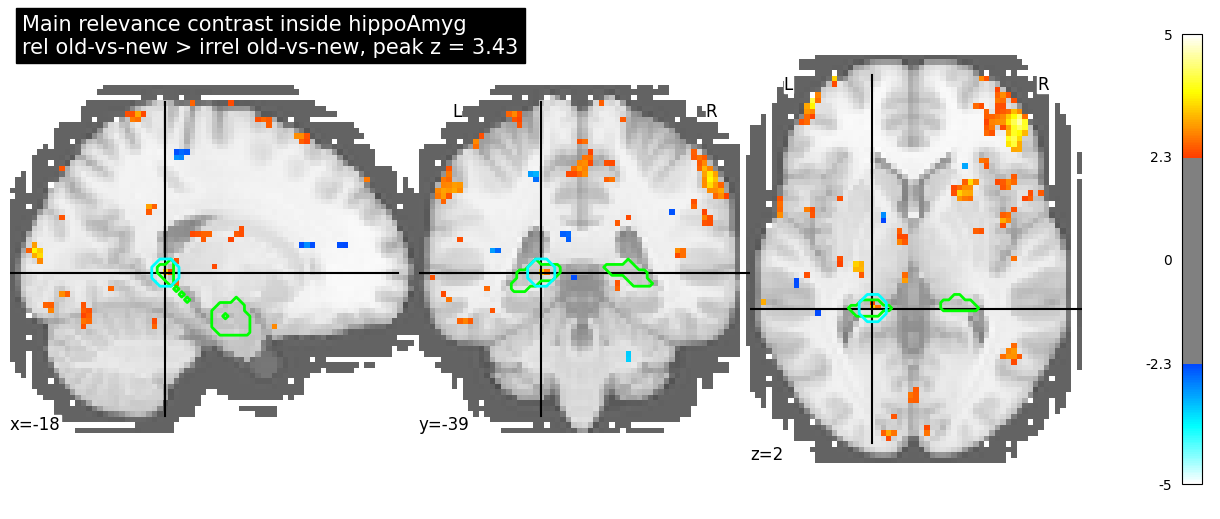

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/figures/main_relevance_within_hippoAmyg_peak_sphere_6mm_smoothed5mm.png


In [29]:
# ============================================================
# 26b. Force within-hippoAmyg peak search for MAIN relevance contrast
# ============================================================

from nilearn.plotting import plot_stat_map
from nilearn.datasets import load_mni152_template
from nilearn.image import load_img, resample_to_img
from scipy.stats import norm
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

MAIN_RELEVANCE_CONTRAST = "rel_vs_new_gt_irrel_vs_new_post_gt_pre"
SPHERE_RADIUS_MM = 6.0

assert "group_mask_data" in globals(), "Run the group hippoAmyg mask cell first."
assert "group_mask_img" in globals(), "Run the group hippoAmyg mask cell first."
assert "GROUP_ROI_PROB_THRESHOLD" in globals(), "Run the group hippoAmyg mask cell first."

z_img = load_img(str(get_group_z_map_path(MAIN_RELEVANCE_CONTRAST)))
z_data = z_img.get_fdata()

mask_bool = group_mask_data.astype(bool)
voxel_indices = np.argwhere(mask_bool)

z_inside = z_data[mask_bool]
finite = np.isfinite(z_inside)

z_inside_finite = z_inside[finite]
finite_voxel_indices = voxel_indices[finite]

assert len(z_inside_finite) > 0, "No finite z-values inside group hippoAmyg mask."

# Find strongest positive peak inside hippoAmyg for the MAIN contrast
max_idx = int(np.argmax(z_inside_finite))
main_peak_z = float(z_inside_finite[max_idx])
main_peak_voxel = finite_voxel_indices[max_idx]
main_peak_mni = nib.affines.apply_affine(z_img.affine, main_peak_voxel)

MAIN_HIPPOAMYG_PEAK = tuple(float(v) for v in main_peak_mni)

print("Main relevance contrast:")
print(MAIN_RELEVANCE_CONTRAST)
print("Strongest peak inside group hippoAmyg mask:")
print("MNI:", MAIN_HIPPOAMYG_PEAK)
print("Peak z:", main_peak_z)
print("Voxel:", tuple(int(v) for v in main_peak_voxel))

# ------------------------------------------------------------
# Anatomical SVC inside group hippoAmyg mask for this contrast
# ------------------------------------------------------------

n_svc_voxels = int(mask_bool.sum())

p_unc = float(norm.sf(main_peak_z))
p_bonf_svc = min(p_unc * n_svc_voxels, 1.0)
bonf_z_threshold = float(norm.isf(0.05 / n_svc_voxels))

p_values = norm.sf(z_inside_finite)
order = np.argsort(p_values)
ranked_p = p_values[order]
ranks = np.arange(1, len(ranked_p) + 1)

q_values_sorted = ranked_p * len(ranked_p) / ranks
q_values_sorted = np.minimum.accumulate(q_values_sorted[::-1])[::-1]

q_values = np.empty_like(q_values_sorted)
q_values[order] = q_values_sorted

main_peak_q_fdr = float(q_values[max_idx])

main_contrast_svc_row = pd.DataFrame([{
    "contrast": MAIN_RELEVANCE_CONTRAST,
    "priority": CONTRAST_PRIORITY[MAIN_RELEVANCE_CONTRAST],
    "formula": CONTRAST_FORMULAS[MAIN_RELEVANCE_CONTRAST],
    "svc_type": "forced_main_contrast_inside_group_hippoAmyg_mask",
    "group_mask_probability_threshold": GROUP_ROI_PROB_THRESHOLD,
    "n_svc_voxels": n_svc_voxels,
    "peak_x": MAIN_HIPPOAMYG_PEAK[0],
    "peak_y": MAIN_HIPPOAMYG_PEAK[1],
    "peak_z_coord": MAIN_HIPPOAMYG_PEAK[2],
    "peak_stat_z": main_peak_z,
    "peak_p_uncorrected_one_sided": p_unc,
    "peak_p_bonferroni_svc_one_sided": p_bonf_svc,
    "peak_q_fdr_svc_one_sided": main_peak_q_fdr,
    "bonferroni_svc_z_threshold_p05": bonf_z_threshold,
    "survives_bonferroni_svc_p05": bool(main_peak_z >= bonf_z_threshold),
    "survives_fdr_svc_q05": bool(main_peak_q_fdr <= 0.05),
    "sphere_radius_mm": SPHERE_RADIUS_MM,
    "interpretation": (
        "Forced anatomical SVC for the main relevance interaction "
        "inside the group hippoAmyg mask."
    ),
}])

main_contrast_svc_path = (
    SVC_TABLE_DIR
    / f"main_relevance_contrast_within_group_hippoAmyg_svc_{SMOOTHING_LABEL}.csv"
)

main_contrast_svc_row.to_csv(main_contrast_svc_path, index=False)

display(main_contrast_svc_row)

print("Saved SVC table:", main_contrast_svc_path)

# ------------------------------------------------------------
# Build a 6 mm sphere around this MAIN-contrast within-mask peak
# ------------------------------------------------------------

shape = z_img.shape
affine = z_img.affine

voxel_coords = np.indices(shape).reshape(3, -1).T
world_coords = nib.affines.apply_affine(affine, voxel_coords)

distances = np.sqrt(
    np.sum(
        (world_coords - np.array(MAIN_HIPPOAMYG_PEAK)) ** 2,
        axis=1,
    )
)

sphere_data = (distances <= SPHERE_RADIUS_MM).reshape(shape).astype(np.uint8)

sphere_img = nib.Nifti1Image(
    sphere_data,
    affine=affine,
    header=z_img.header,
)

safe_peak_name = (
    f"{MAIN_HIPPOAMYG_PEAK[0]:.1f}_{MAIN_HIPPOAMYG_PEAK[1]:.1f}_{MAIN_HIPPOAMYG_PEAK[2]:.1f}"
    .replace("-", "m")
    .replace(".", "p")
)

sphere_path = (
    SVC_MASK_DIR
    / f"main_relevance_within_hippoAmyg_peak_sphere_6mm_{safe_peak_name}_{SMOOTHING_LABEL}.nii.gz"
)

sphere_img.to_filename(str(sphere_path))

print("Saved sphere mask:", sphere_path)
print("Sphere voxels:", int(sphere_data.sum()))

# ------------------------------------------------------------
# Plot main contrast with group hippoAmyg mask and sphere
# ------------------------------------------------------------

mni_template = load_mni152_template(resolution=2)

mni_template_resampled = resample_to_img(
    mni_template,
    z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

fig = plt.figure(figsize=(12, 5))

display_obj = plot_stat_map(
    z_img,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=MAIN_HIPPOAMYG_PEAK,
    threshold=2.33,
    vmax=5.0,
    cmap="cold_hot",
    black_bg=False,
    title=(
        "Main relevance contrast inside hippoAmyg\n"
        f"rel old-vs-new > irrel old-vs-new, peak z = {main_peak_z:.2f}"
    ),
    figure=fig,
)

# Lime = anatomical group hippoAmyg mask
display_obj.add_contours(
    group_mask_img,
    levels=[0.5],
    colors=["lime"],
    linewidths=2.0,
)

# Cyan = 6 mm sphere around main-contrast within-mask peak
display_obj.add_contours(
    sphere_img,
    levels=[0.5],
    colors=["cyan"],
    linewidths=2.0,
)

main_sphere_plot_path = (
    SVC_FIG_DIR
    / f"main_relevance_within_hippoAmyg_peak_sphere_6mm_{SMOOTHING_LABEL}.png"
)

fig.savefig(main_sphere_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", main_sphere_plot_path)

In [30]:
# ============================================================
# 26c. Statistical test for MAIN relevance peak inside hippoAmyg SVC
# ============================================================

from scipy.stats import norm
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.image import load_img

MAIN_RELEVANCE_CONTRAST = "rel_vs_new_gt_irrel_vs_new_post_gt_pre"

# Load group z-map
z_img = load_img(str(get_group_z_map_path(MAIN_RELEVANCE_CONTRAST)))
z_data = z_img.get_fdata()

# Use group hippoAmyg mask already built in previous cells
assert "group_mask_data" in globals(), "Run the group hippoAmyg mask cell first."
assert "GROUP_ROI_PROB_THRESHOLD" in globals(), "Run the group hippoAmyg mask cell first."

mask_bool = group_mask_data.astype(bool)
voxel_indices = np.argwhere(mask_bool)

# Extract z-values inside mask
z_inside = z_data[mask_bool]
finite = np.isfinite(z_inside)

z_inside_finite = z_inside[finite]
finite_voxel_indices = voxel_indices[finite]

assert len(z_inside_finite) > 0, "No finite z-values inside group hippoAmyg mask."

# Find strongest positive peak inside mask
max_idx = int(np.argmax(z_inside_finite))
peak_z = float(z_inside_finite[max_idx])
peak_voxel = finite_voxel_indices[max_idx]
peak_mni = nib.affines.apply_affine(z_img.affine, peak_voxel)

# Number of voxels in the small volume
n_svc_voxels = int(len(z_inside_finite))

# One-sided p-value for positive effect
p_uncorrected_one_sided = float(norm.sf(peak_z))

# Bonferroni correction across voxels in the small volume
p_bonferroni_svc = min(p_uncorrected_one_sided * n_svc_voxels, 1.0)
bonferroni_z_threshold_p05 = float(norm.isf(0.05 / n_svc_voxels))

# FDR correction across voxels in the small volume
p_values = norm.sf(z_inside_finite)

order = np.argsort(p_values)
ranked_p = p_values[order]
ranks = np.arange(1, len(ranked_p) + 1)

q_sorted = ranked_p * len(ranked_p) / ranks
q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]

q_values = np.empty_like(q_sorted)
q_values[order] = q_sorted

peak_q_fdr_svc = float(q_values[max_idx])

svc_test_main_peak = pd.DataFrame([{
    "contrast": MAIN_RELEVANCE_CONTRAST,
    "formula": CONTRAST_FORMULAS[MAIN_RELEVANCE_CONTRAST],
    "svc_type": "main_relevance_peak_inside_group_hippoAmyg",
    "group_mask_probability_threshold": GROUP_ROI_PROB_THRESHOLD,
    "n_svc_voxels": n_svc_voxels,
    "peak_x": float(peak_mni[0]),
    "peak_y": float(peak_mni[1]),
    "peak_z_coord": float(peak_mni[2]),
    "peak_stat_z": peak_z,
    "p_uncorrected_one_sided": p_uncorrected_one_sided,
    "p_bonferroni_svc_one_sided": p_bonferroni_svc,
    "q_fdr_svc_one_sided": peak_q_fdr_svc,
    "bonferroni_z_threshold_p05": bonferroni_z_threshold_p05,
    "survives_uncorrected_p001": bool(p_uncorrected_one_sided < 0.001),
    "survives_bonferroni_svc_p05": bool(p_bonferroni_svc < 0.05),
    "survives_fdr_svc_q05": bool(peak_q_fdr_svc < 0.05),
}])

svc_test_main_peak_path = (
    SVC_TABLE_DIR
    / f"main_relevance_peak_inside_group_hippoAmyg_statistical_test_{SMOOTHING_LABEL}.csv"
)

svc_test_main_peak.to_csv(svc_test_main_peak_path, index=False)

display(svc_test_main_peak)

print("Saved:", svc_test_main_peak_path)

,contrast,formula,svc_type,group_mask_probability_threshold,n_svc_voxels,peak_x,peak_y,peak_z_coord,peak_stat_z,p_uncorrected_one_sided,p_bonferroni_svc_one_sided,q_fdr_svc_one_sided,bonferroni_z_threshold_p05,survives_uncorrected_p001,survives_bonferroni_svc_p05,survives_fdr_svc_q05
0,rel_vs_new_gt_irrel_vs_new_post_gt_pre,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",main_relevance_peak_inside_group_hippoAmyg,0.25,1113,-18.5,-39.5,2.0,3.432898,0.000299,0.332324,0.332324,3.916491,True,False,False


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/tables/main_relevance_peak_inside_group_hippoAmyg_statistical_test_smoothed5mm.csv


,contrast,formula,roi,n_subjects,sphere_x,sphere_y,sphere_z,sphere_radius_mm,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive,interpretation
0,rel_vs_new_gt_irrel_vs_new_post_gt_pre,"$$[(\beta_{\mathrm{post,oldRel}}-\beta_{\mathr...",main_relevance_within_hippoAmyg_peak_sphere_6mm,27,-18.5,-39.5,2.0,6.0,0.015195,0.035755,0.006881,2.208307,0.036244,0.018122,18,0.666667,Post-hoc sphere centered on strongest main-rel...


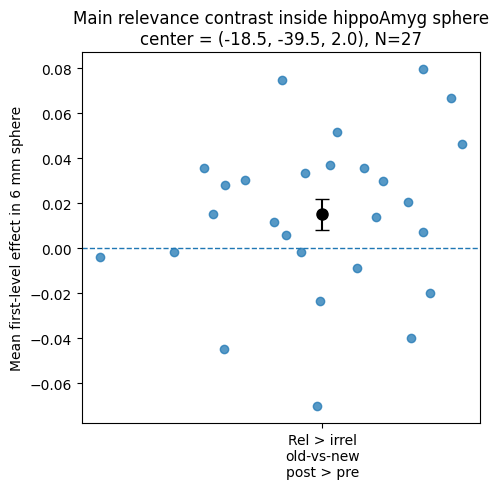

Saved subject effects: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/tables/main_relevance_within_hippoAmyg_sphere_subject_effects_smoothed5mm.csv
Saved summary: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/tables/main_relevance_within_hippoAmyg_sphere_subject_level_test_smoothed5mm.csv
Saved plot: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/small_volume_correction/figures/main_relevance_within_hippoAmyg_sphere_subject_effects_smoothed5mm.png


In [31]:
# ============================================================
# 26d. Subject-level test in 6 mm sphere around main hippoAmyg peak
# ============================================================

from nilearn.maskers import NiftiSpheresMasker
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAIN_RELEVANCE_CONTRAST = "rel_vs_new_gt_irrel_vs_new_post_gt_pre"

# Use the peak from the previous SVC test
MAIN_HIPPOAMYG_PEAK = (
    float(svc_test_main_peak.loc[0, "peak_x"]),
    float(svc_test_main_peak.loc[0, "peak_y"]),
    float(svc_test_main_peak.loc[0, "peak_z_coord"]),
)

SPHERE_RADIUS_MM = 6.0

sphere_subject_rows = []

sphere_masker = NiftiSpheresMasker(
    seeds=[MAIN_HIPPOAMYG_PEAK],
    radius=SPHERE_RADIUS_MM,
    detrend=False,
    standardize=False,
)

for subject in subjects:
    effect_path = get_first_level_effect_map_path(subject, MAIN_RELEVANCE_CONTRAST)
    assert effect_path.exists(), f"Missing effect map: {effect_path}"
    
    effect_img = load_img(str(effect_path))
    values = sphere_masker.fit_transform(effect_img)
    
    mean_effect = float(np.asarray(values).ravel()[0])
    
    sphere_subject_rows.append({
        "subject": subject,
        "contrast": MAIN_RELEVANCE_CONTRAST,
        "sphere_x": MAIN_HIPPOAMYG_PEAK[0],
        "sphere_y": MAIN_HIPPOAMYG_PEAK[1],
        "sphere_z": MAIN_HIPPOAMYG_PEAK[2],
        "sphere_radius_mm": SPHERE_RADIUS_MM,
        "mean_effect": mean_effect,
        "effect_map_path": str(effect_path),
    })

main_hippoamyg_sphere_effects = pd.DataFrame(sphere_subject_rows)

effects = main_hippoamyg_sphere_effects["mean_effect"].values

t_stat, p_two = stats.ttest_1samp(effects, popmean=0.0)

if t_stat > 0:
    p_one_positive = p_two / 2
else:
    p_one_positive = 1 - (p_two / 2)

main_hippoamyg_sphere_summary = pd.DataFrame([{
    "contrast": MAIN_RELEVANCE_CONTRAST,
    "formula": CONTRAST_FORMULAS[MAIN_RELEVANCE_CONTRAST],
    "roi": "main_relevance_within_hippoAmyg_peak_sphere_6mm",
    "n_subjects": len(effects),
    "sphere_x": MAIN_HIPPOAMYG_PEAK[0],
    "sphere_y": MAIN_HIPPOAMYG_PEAK[1],
    "sphere_z": MAIN_HIPPOAMYG_PEAK[2],
    "sphere_radius_mm": SPHERE_RADIUS_MM,
    "mean_effect": float(np.mean(effects)),
    "sd_effect": float(np.std(effects, ddof=1)),
    "sem_effect": float(stats.sem(effects)),
    "t_stat": float(t_stat),
    "p_two_sided": float(p_two),
    "p_one_sided_positive": float(p_one_positive),
    "n_positive": int(np.sum(effects > 0)),
    "proportion_positive": float(np.mean(effects > 0)),
    "interpretation": "Post-hoc sphere centered on strongest main-relevance peak inside group hippoAmyg mask.",
}])

main_hippoamyg_sphere_effects_path = (
    SVC_TABLE_DIR
    / f"main_relevance_within_hippoAmyg_sphere_subject_effects_{SMOOTHING_LABEL}.csv"
)

main_hippoamyg_sphere_summary_path = (
    SVC_TABLE_DIR
    / f"main_relevance_within_hippoAmyg_sphere_subject_level_test_{SMOOTHING_LABEL}.csv"
)

main_hippoamyg_sphere_effects.to_csv(main_hippoamyg_sphere_effects_path, index=False)
main_hippoamyg_sphere_summary.to_csv(main_hippoamyg_sphere_summary_path, index=False)

display(main_hippoamyg_sphere_summary)

# Plot subject effects
fig, ax = plt.subplots(figsize=(5, 5))

rng = np.random.default_rng(42)
jitter = rng.normal(0, 0.04, size=len(effects))

ax.scatter(
    np.zeros(len(effects)) + jitter,
    effects,
    alpha=0.75,
)

ax.errorbar(
    0,
    np.mean(effects),
    yerr=stats.sem(effects),
    fmt="o",
    color="black",
    markersize=8,
    capsize=5,
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks([0])
ax.set_xticklabels(["Rel > irrel\nold-vs-new\npost > pre"])
ax.set_ylabel("Mean first-level effect in 6 mm sphere")
ax.set_title(
    "Main relevance contrast inside hippoAmyg sphere\n"
    f"center = {MAIN_HIPPOAMYG_PEAK}, N={len(subjects)}"
)

plt.tight_layout()

main_hippoamyg_sphere_plot_path = (
    SVC_FIG_DIR
    / f"main_relevance_within_hippoAmyg_sphere_subject_effects_{SMOOTHING_LABEL}.png"
)

fig.savefig(main_hippoamyg_sphere_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved subject effects:", main_hippoamyg_sphere_effects_path)
print("Saved summary:", main_hippoamyg_sphere_summary_path)
print("Saved plot:", main_hippoamyg_sphere_plot_path)

In [35]:
# ============================================================
# Select GLM 2 relevance-split clusters for slides
# ============================================================

import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from nilearn.image import load_img
from nilearn.datasets import fetch_atlas_harvard_oxford

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

SLIDE_CLUSTER_DIR = FIG_DIR / "selected_glm2_relevance_clusters_for_slides"
SLIDE_CLUSTER_TABLE_DIR = TABLE_DIR / "selected_glm2_relevance_clusters_for_slides"

SLIDE_CLUSTER_DIR.mkdir(parents=True, exist_ok=True)
SLIDE_CLUSTER_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load cluster table if not already loaded
# ------------------------------------------------------------

# Adjust this path only if your cluster-details file has another name.
cluster_details_path = (
    TABLE_DIR
    / f"pre_post_relevance_old_new_cluster_details_from_{SMOOTHING_LABEL}.csv"
)

if not cluster_details_path.exists():
    # fallback: search for likely cluster file
    candidates = sorted(TABLE_DIR.glob("*cluster*details*.csv"))
    print("Cluster detail candidates:")
    for candidate in candidates:
        print(candidate)
    assert len(candidates) > 0, "Could not find cluster-details CSV."
    cluster_details_path = candidates[0]

cluster_details = pd.read_csv(cluster_details_path)

print("Loaded cluster details:")
print(cluster_details_path)
print(cluster_details.shape)

display(cluster_details.head())

Cluster detail candidates:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_cluster_details_z233_z300_from_smoothed5mm.csv
Loaded cluster details:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/pre_post_relevance_old_new_cluster_details_z233_z300_from_smoothed5mm.csv
(404, 12)


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,4.0,-17.0,-15.5,4.887609,765.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
1,2,6.5,35.5,29.5,3.983903,1125.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
2,3,46.5,3.0,-43.0,3.946142,171.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
3,4,46.5,25.5,44.5,3.879742,531.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10
4,5,41.5,-54.5,4.5,3.811980,515.0,rel_old_vs_new_post_gt_pre,primary_relevance_specific,"$$(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm...",z_gt_2.33,2.33,10


In [36]:
# ============================================================
# Harvard-Oxford atlas labeling helper
# ============================================================

from nilearn.image import resample_to_img

# Fetch Harvard-Oxford atlases
ho_cort = fetch_atlas_harvard_oxford(
    atlas_name="cort-maxprob-thr25-2mm",
    symmetric_split=False,
)

ho_sub = fetch_atlas_harvard_oxford(
    atlas_name="sub-maxprob-thr25-2mm",
    symmetric_split=False,
)

ho_cort_img = load_img(ho_cort.maps)
ho_sub_img = load_img(ho_sub.maps)

ho_cort_labels = list(ho_cort.labels)
ho_sub_labels = list(ho_sub.labels)

# Use one relevance z-map as reference
reference_img = load_img(str(get_group_z_map_path("rel_vs_new_gt_irrel_vs_new_post_gt_pre")))

ho_cort_resampled = resample_to_img(
    ho_cort_img,
    reference_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

ho_sub_resampled = resample_to_img(
    ho_sub_img,
    reference_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

ho_cort_data = ho_cort_resampled.get_fdata().astype(int)
ho_sub_data = ho_sub_resampled.get_fdata().astype(int)


def label_coordinate_harvard_oxford(x, y, z, reference_img):
    """Return Harvard-Oxford cortical/subcortical labels at a coordinate."""
    
    voxel = nib.affines.apply_affine(
        np.linalg.inv(reference_img.affine),
        [x, y, z],
    )
    
    voxel = np.round(voxel).astype(int)
    
    in_bounds = (
        0 <= voxel[0] < reference_img.shape[0]
        and 0 <= voxel[1] < reference_img.shape[1]
        and 0 <= voxel[2] < reference_img.shape[2]
    )
    
    if not in_bounds:
        return {
            "harvard_oxford_cortical_label": "out_of_bounds",
            "harvard_oxford_cortical_value": np.nan,
            "harvard_oxford_subcortical_label": "out_of_bounds",
            "harvard_oxford_subcortical_value": np.nan,
        }
    
    cort_value = int(ho_cort_data[tuple(voxel)])
    sub_value = int(ho_sub_data[tuple(voxel)])
    
    cort_label = (
        ho_cort_labels[cort_value]
        if cort_value < len(ho_cort_labels)
        else "unknown"
    )
    
    sub_label = (
        ho_sub_labels[sub_value]
        if sub_value < len(ho_sub_labels)
        else "unknown"
    )
    
    return {
        "harvard_oxford_cortical_label": cort_label,
        "harvard_oxford_cortical_value": cort_value,
        "harvard_oxford_subcortical_label": sub_label,
        "harvard_oxford_subcortical_value": sub_value,
    }


print("Atlas helper ready.")

[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
Atlas helper ready.


In [37]:
# ============================================================
# Corrected GLM 2 slide-cluster selection
# Use the SAME thresholds as the plotted figures
# ============================================================

import numpy as np
import pandas as pd
import nibabel as nib

# These are the exact peaks / thresholds used in the figures you showed.
selected_glm2_peak_specs = [
    {
        "slide_label": "relevant_old_vs_new_post_gt_pre",
        "contrast": "rel_old_vs_new_post_gt_pre",
        "threshold_label": "z_gt_3.00",
        "target_x": 4.0,
        "target_y": -17.0,
        "target_z": -15.5,
        "short_title": "Relevant old > new, post > pre",
        "presentation_label": "ventral medial temporal / memory-related peak",
        "reason": "strongest relevant old-vs-new post-pre peak, shown at z > 3.00",
    },
    {
        "slide_label": "irrelevant_old_vs_new_post_gt_pre",
        "contrast": "irrel_old_vs_new_post_gt_pre",
        "threshold_label": "z_gt_2.33",
        "target_x": 21.5,
        "target_y": -32.0,
        "target_z": -40.5,
        "short_title": "Irrelevant old > new, post > pre",
        "presentation_label": "ventral posterior / MTL-adjacent exploratory peak",
        "reason": "strongest irrelevant old-vs-new post-pre peak, shown at z > 2.33 because no clusters survived z > 3.00 cluster reporting",
    },
    {
        "slide_label": "relevant_gt_irrelevant_old_vs_new",
        "contrast": "rel_vs_new_gt_irrel_vs_new_post_gt_pre",
        "threshold_label": "z_gt_3.00",
        "target_x": 49.0,
        "target_y": 45.5,
        "target_z": 2.0,
        "short_title": "Relevant old-vs-new > irrelevant old-vs-new",
        "presentation_label": "right frontal pole",
        "reason": "strongest main relevance-interaction peak, shown at z > 3.00",
    },
    {
        "slide_label": "irrelevant_gt_relevant_old_vs_new",
        "contrast": "irrel_vs_new_gt_rel_vs_new_post_gt_pre",
        "threshold_label": "z_gt_2.33",
        "target_x": 6.5,
        "target_y": -47.0,
        "target_z": -38.0,
        "short_title": "Irrelevant old-vs-new > relevant old-vs-new",
        "presentation_label": "ventral posterior exploratory reverse peak",
        "reason": "strongest reverse-interaction exploratory peak, shown at z > 2.33 because no clusters survived z > 3.00 cluster reporting",
    },
]

selected_rows = []

for spec in selected_glm2_peak_specs:
    subset = cluster_details[
        (cluster_details["contrast"] == spec["contrast"])
        & (cluster_details["threshold_label"] == spec["threshold_label"])
    ].copy()
    
    assert len(subset) > 0, (
        f"No clusters found for {spec['contrast']} / {spec['threshold_label']}. "
        "Check whether the cluster-details table contains this threshold."
    )
    
    coords = subset[["X", "Y", "Z"]].astype(float).values
    target = np.array([spec["target_x"], spec["target_y"], spec["target_z"]], dtype=float)
    distances = np.sqrt(((coords - target) ** 2).sum(axis=1))
    
    best_idx = subset.index[np.argmin(distances)]
    row = subset.loc[best_idx].copy()
    
    atlas_labels = label_coordinate_harvard_oxford(
        float(row["X"]),
        float(row["Y"]),
        float(row["Z"]),
        reference_img,
    )
    
    selected_rows.append({
        "slide_label": spec["slide_label"],
        "contrast": spec["contrast"],
        "short_title": spec["short_title"],
        "presentation_label": spec["presentation_label"],
        "reason": spec["reason"],
        "threshold_label": spec["threshold_label"],
        "cluster_id": row["Cluster ID"],
        "x": float(row["X"]),
        "y": float(row["Y"]),
        "z": float(row["Z"]),
        "peak_z": float(row["Peak Stat"]),
        "cluster_size_mm3": row["Cluster Size (mm3)"],
        "priority": row.get("priority", ""),
        "formula": row.get("formula", ""),
        **atlas_labels,
    })

selected_glm2_clusters = pd.DataFrame(selected_rows)

selected_glm2_clusters_path = (
    SLIDE_CLUSTER_TABLE_DIR
    / f"selected_glm2_relevance_clusters_for_slides_matched_to_figures_{SMOOTHING_LABEL}.csv"
)

selected_glm2_clusters.to_csv(selected_glm2_clusters_path, index=False)

display(
    selected_glm2_clusters[
        [
            "slide_label",
            "short_title",
            "presentation_label",
            "threshold_label",
            "cluster_id",
            "x", "y", "z",
            "peak_z",
            "cluster_size_mm3",
            "harvard_oxford_cortical_label",
            "harvard_oxford_subcortical_label",
            "reason",
        ]
    ]
)

print("Saved:", selected_glm2_clusters_path)

,slide_label,short_title,presentation_label,threshold_label,cluster_id,x,y,z,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,reason
0,relevant_old_vs_new_post_gt_pre,"Relevant old > new, post > pre",ventral medial temporal / memory-related peak,z_gt_3.00,1,4.0,-17.0,-15.5,4.887609,375.0,Background,Background,"strongest relevant old-vs-new post-pre peak, s..."
1,irrelevant_old_vs_new_post_gt_pre,"Irrelevant old > new, post > pre",ventral posterior / MTL-adjacent exploratory peak,z_gt_2.33,1,21.5,-32.0,-40.5,4.265341,156.0,Background,Background,"strongest irrelevant old-vs-new post-pre peak,..."
2,relevant_gt_irrelevant_old_vs_new,Relevant old-vs-new > irrelevant old-vs-new,right frontal pole,z_gt_3.00,1,49.0,45.5,2.0,4.567430,2718.0,Frontal Pole,Right Cerebral Cortex,"strongest main relevance-interaction peak, sho..."
3,irrelevant_gt_relevant_old_vs_new,Irrelevant old-vs-new > relevant old-vs-new,ventral posterior exploratory reverse peak,z_gt_2.33,1,6.5,-47.0,-38.0,3.931434,437.0,Background,Background,strongest reverse-interaction exploratory peak...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/selected_glm2_relevance_clusters_for_slides/selected_glm2_relevance_clusters_for_slides_matched_to_figures_smoothed5mm.csv


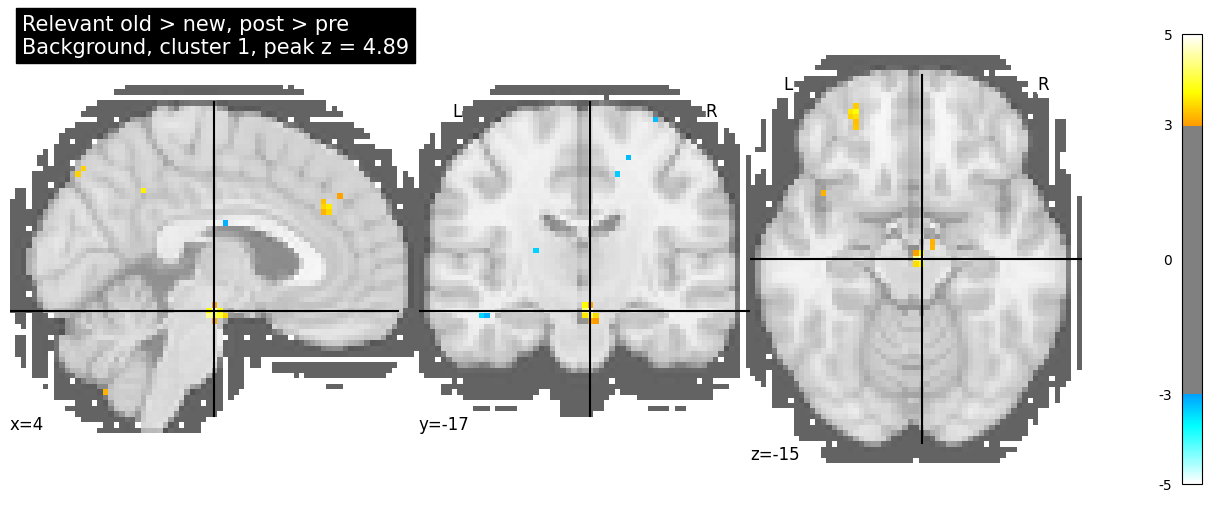

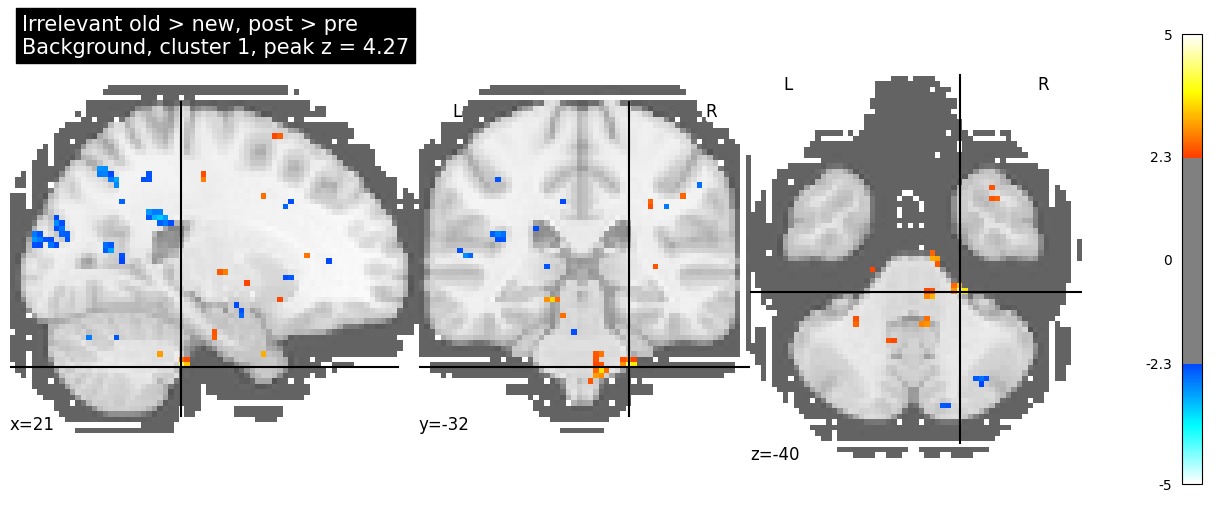

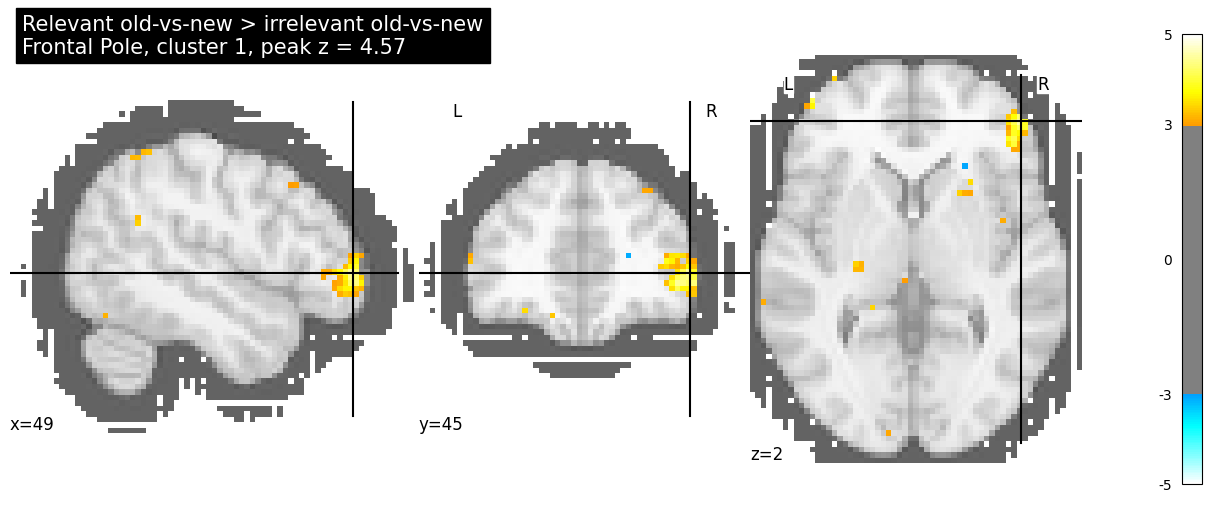

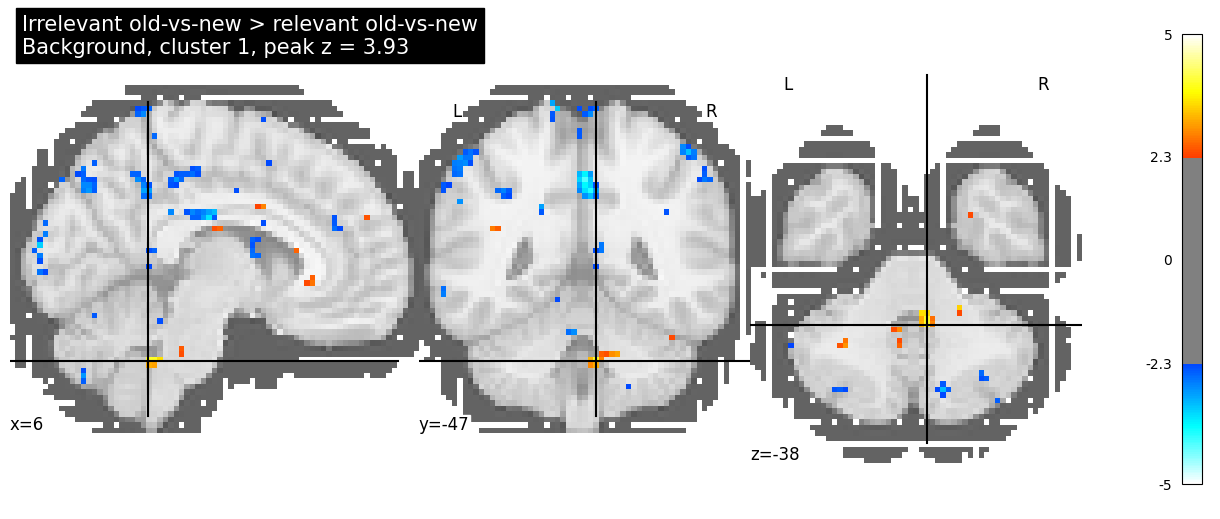

,slide_label,contrast,short_title,threshold,threshold_text,cut_coords,cluster_id,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,figure_path
0,relevant_old_vs_new_post_gt_pre,rel_old_vs_new_post_gt_pre,"Relevant old > new, post > pre",3.00,exploratory z > 3.0,"(4.0, -17.0, -15.5)",1,4.887609,375.0,Background,Background,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,irrelevant_old_vs_new_post_gt_pre,irrel_old_vs_new_post_gt_pre,"Irrelevant old > new, post > pre",2.33,exploratory z > 2.33,"(21.5, -32.0, -40.5)",1,4.265341,156.0,Background,Background,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,relevant_gt_irrelevant_old_vs_new,rel_vs_new_gt_irrel_vs_new_post_gt_pre,Relevant old-vs-new > irrelevant old-vs-new,3.00,exploratory z > 3.0,"(49.0, 45.5, 2.0)",1,4.567430,2718.0,Frontal Pole,Right Cerebral Cortex,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,irrelevant_gt_relevant_old_vs_new,irrel_vs_new_gt_rel_vs_new_post_gt_pre,Irrelevant old-vs-new > relevant old-vs-new,2.33,exploratory z > 2.33,"(6.5, -47.0, -38.0)",1,3.931434,437.0,Background,Background,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/selected_glm2_relevance_clusters_for_slides/selected_glm2_relevance_cluster_figures_smoothed5mm.csv


In [38]:
# ============================================================
# Plot selected GLM 2 clusters for slides
# ============================================================

import matplotlib.pyplot as plt
from nilearn.plotting import plot_stat_map
from nilearn.datasets import load_mni152_template
from nilearn.image import resample_to_img, load_img

mni_template = load_mni152_template(resolution=2)

plot_rows = []

for _, row in selected_glm2_clusters.iterrows():
    contrast_name = row["contrast"]
    
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    
    mni_template_resampled = resample_to_img(
        mni_template,
        z_img,
        interpolation="continuous",
        force_resample=True,
        copy_header=True,
    )
    
    cut_coords = (
        float(row["x"]),
        float(row["y"]),
        float(row["z"]),
    )
    
    # Use stricter z > 3.0 for the main/relevant figures when possible,
    # but keep z > 2.33 for weaker exploratory reverse/irrelevant plots.
    if row["threshold_label"] == "z_gt_3.00":
        plot_threshold = 3.0
        threshold_text = "exploratory z > 3.0"
    else:
        plot_threshold = 2.33
        threshold_text = "exploratory z > 2.33"
    
    title = (
        f"{row['short_title']}\n"
        f"{row['harvard_oxford_cortical_label']}, "
        f"cluster {row['cluster_id']}, peak z = {row['peak_z']:.2f}"
    )
    
    fig = plt.figure(figsize=(12, 5))
    
    display_obj = plot_stat_map(
        z_img,
        bg_img=mni_template_resampled,
        display_mode="ortho",
        cut_coords=cut_coords,
        threshold=plot_threshold,
        vmax=5.0,
        cmap="cold_hot",
        black_bg=False,
        title=title,
        figure=fig,
    )
    
    safe_label = str(row["slide_label"]).replace(" ", "_")
    
    figure_path = (
        SLIDE_CLUSTER_DIR
        / f"glm2_{safe_label}_{contrast_name}_{SMOOTHING_LABEL}.png"
    )
    
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    plot_rows.append({
        "slide_label": row["slide_label"],
        "contrast": contrast_name,
        "short_title": row["short_title"],
        "threshold": plot_threshold,
        "threshold_text": threshold_text,
        "cut_coords": cut_coords,
        "cluster_id": row["cluster_id"],
        "peak_z": row["peak_z"],
        "cluster_size_mm3": row["cluster_size_mm3"],
        "harvard_oxford_cortical_label": row["harvard_oxford_cortical_label"],
        "harvard_oxford_subcortical_label": row["harvard_oxford_subcortical_label"],
        "figure_path": str(figure_path),
    })

glm2_slide_cluster_figures = pd.DataFrame(plot_rows)

glm2_slide_cluster_figures_path = (
    SLIDE_CLUSTER_TABLE_DIR
    / f"selected_glm2_relevance_cluster_figures_{SMOOTHING_LABEL}.csv"
)

glm2_slide_cluster_figures.to_csv(glm2_slide_cluster_figures_path, index=False)

display(glm2_slide_cluster_figures)

print("Saved:", glm2_slide_cluster_figures_path)

In [39]:
# ============================================================
# Presentation-friendly labels for GLM 2 clusters
# ============================================================

presentation_label_map = {
    "relevant_old_vs_new_post_gt_pre": {
        "presentation_label": "medial temporal / ventral memory-related peak",
        "slide_caption": (
            "Relevant old images showed stronger post-pre old-vs-new responses, "
            "with the strongest exploratory peak in a medial temporal / ventral region."
        ),
    },
    "irrelevant_old_vs_new_post_gt_pre": {
        "presentation_label": "ventral medial temporal / cerebellar-adjacent peak",
        "slide_caption": (
            "Irrelevant old images also showed exploratory old-vs-new post-pre effects, "
            "but the pattern was weaker and less coherent than the relevance interaction."
        ),
    },
    "relevant_gt_irrelevant_old_vs_new": {
        "presentation_label": "right frontal pole",
        "slide_caption": (
            "The main relevance interaction peaked in right frontal pole, consistent with "
            "goal-directed control, relevance evaluation, and strategic retrieval."
        ),
    },
    "irrelevant_gt_relevant_old_vs_new": {
        "presentation_label": "ventral posterior / exploratory reverse peak",
        "slide_caption": (
            "The reverse interaction was weaker and should be interpreted as a secondary "
            "exploratory control effect."
        ),
    },
}

glm2_slide_summary = selected_glm2_clusters.copy()

glm2_slide_summary["presentation_label"] = glm2_slide_summary["slide_label"].map(
    lambda x: presentation_label_map[x]["presentation_label"]
)

glm2_slide_summary["slide_caption"] = glm2_slide_summary["slide_label"].map(
    lambda x: presentation_label_map[x]["slide_caption"]
)

glm2_slide_summary_path = (
    SLIDE_CLUSTER_TABLE_DIR
    / f"selected_glm2_relevance_clusters_slide_summary_{SMOOTHING_LABEL}.csv"
)

glm2_slide_summary.to_csv(glm2_slide_summary_path, index=False)

display(
    glm2_slide_summary[
        [
            "slide_label",
            "short_title",
            "presentation_label",
            "x",
            "y",
            "z",
            "peak_z",
            "cluster_size_mm3",
            "harvard_oxford_cortical_label",
            "harvard_oxford_subcortical_label",
            "slide_caption",
        ]
    ]
)

print("Saved:", glm2_slide_summary_path)

,slide_label,short_title,presentation_label,x,y,z,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,slide_caption
0,relevant_old_vs_new_post_gt_pre,"Relevant old > new, post > pre",medial temporal / ventral memory-related peak,4.0,-17.0,-15.5,4.887609,375.0,Background,Background,Relevant old images showed stronger post-pre o...
1,irrelevant_old_vs_new_post_gt_pre,"Irrelevant old > new, post > pre",ventral medial temporal / cerebellar-adjacent ...,21.5,-32.0,-40.5,4.265341,156.0,Background,Background,Irrelevant old images also showed exploratory ...
2,relevant_gt_irrelevant_old_vs_new,Relevant old-vs-new > irrelevant old-vs-new,right frontal pole,49.0,45.5,2.0,4.567430,2718.0,Frontal Pole,Right Cerebral Cortex,The main relevance interaction peaked in right...
3,irrelevant_gt_relevant_old_vs_new,Irrelevant old-vs-new > relevant old-vs-new,ventral posterior / exploratory reverse peak,6.5,-47.0,-38.0,3.931434,437.0,Background,Background,The reverse interaction was weaker and should ...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/selected_glm2_relevance_clusters_for_slides/selected_glm2_relevance_clusters_slide_summary_smoothed5mm.csv


In [40]:
# ============================================================
# Manual presentation labels for GLM 2 selected peaks
# ============================================================

manual_glm2_labels = {
    "relevant_old_vs_new_post_gt_pre": {
        "clean_label": "ventral medial temporal / midbrain-adjacent peak",
        "slide_title": "Relevant old > new, post > pre",
        "interpretation": (
            "Exploratory peak near ventral medial temporal / midbrain-adjacent territory. "
            "This may reflect memory/context-related reactivation for relevant old images, "
            "but the anatomical label should be interpreted cautiously because the exact "
            "peak voxel is labelled as Background by Harvard-Oxford."
        ),
    },
    "irrelevant_old_vs_new_post_gt_pre": {
        "clean_label": "right ventral posterior MTL / cerebellar-adjacent peak",
        "slide_title": "Irrelevant old > new, post > pre",
        "interpretation": (
            "Exploratory ventral posterior peak. This effect is weaker and less central "
            "to the relevance story; it can be shown as a control/comparison map."
        ),
    },
    "relevant_gt_irrelevant_old_vs_new": {
        "clean_label": "right frontal pole",
        "slide_title": "Relevant old-vs-new > irrelevant old-vs-new",
        "interpretation": (
            "Main relevance-interaction peak. This is the cleanest GLM 2 result and is "
            "consistent with goal-directed control, relevance evaluation, and strategic "
            "memory retrieval."
        ),
    },
    "irrelevant_gt_relevant_old_vs_new": {
        "clean_label": "ventral posterior exploratory reverse peak",
        "slide_title": "Irrelevant old-vs-new > relevant old-vs-new",
        "interpretation": (
            "Secondary reverse-interaction control. The reverse contrast is weaker and "
            "should be interpreted cautiously."
        ),
    },
}

glm2_slide_labels_clean = selected_glm2_clusters.copy()

glm2_slide_labels_clean["clean_anatomical_label"] = glm2_slide_labels_clean["slide_label"].map(
    lambda x: manual_glm2_labels[x]["clean_label"]
)

glm2_slide_labels_clean["clean_slide_title"] = glm2_slide_labels_clean["slide_label"].map(
    lambda x: manual_glm2_labels[x]["slide_title"]
)

glm2_slide_labels_clean["interpretation_for_slide_notes"] = glm2_slide_labels_clean["slide_label"].map(
    lambda x: manual_glm2_labels[x]["interpretation"]
)

clean_label_path = (
    SLIDE_CLUSTER_TABLE_DIR
    / f"selected_glm2_relevance_clusters_clean_labels_{SMOOTHING_LABEL}.csv"
)

glm2_slide_labels_clean.to_csv(clean_label_path, index=False)

display(
    glm2_slide_labels_clean[
        [
            "slide_label",
            "clean_slide_title",
            "clean_anatomical_label",
            "threshold_label",
            "cluster_id",
            "x", "y", "z",
            "peak_z",
            "cluster_size_mm3",
            "harvard_oxford_cortical_label",
            "harvard_oxford_subcortical_label",
            "interpretation_for_slide_notes",
        ]
    ]
)

print("Saved:", clean_label_path)

,slide_label,clean_slide_title,clean_anatomical_label,threshold_label,cluster_id,x,y,z,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,interpretation_for_slide_notes
0,relevant_old_vs_new_post_gt_pre,"Relevant old > new, post > pre",ventral medial temporal / midbrain-adjacent peak,z_gt_3.00,1,4.0,-17.0,-15.5,4.887609,375.0,Background,Background,Exploratory peak near ventral medial temporal ...
1,irrelevant_old_vs_new_post_gt_pre,"Irrelevant old > new, post > pre",right ventral posterior MTL / cerebellar-adjac...,z_gt_2.33,1,21.5,-32.0,-40.5,4.265341,156.0,Background,Background,Exploratory ventral posterior peak. This effec...
2,relevant_gt_irrelevant_old_vs_new,Relevant old-vs-new > irrelevant old-vs-new,right frontal pole,z_gt_3.00,1,49.0,45.5,2.0,4.567430,2718.0,Frontal Pole,Right Cerebral Cortex,Main relevance-interaction peak. This is the c...
3,irrelevant_gt_relevant_old_vs_new,Irrelevant old-vs-new > relevant old-vs-new,ventral posterior exploratory reverse peak,z_gt_2.33,1,6.5,-47.0,-38.0,3.931434,437.0,Background,Background,Secondary reverse-interaction control. The rev...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/selected_glm2_relevance_clusters_for_slides/selected_glm2_relevance_clusters_clean_labels_smoothed5mm.csv


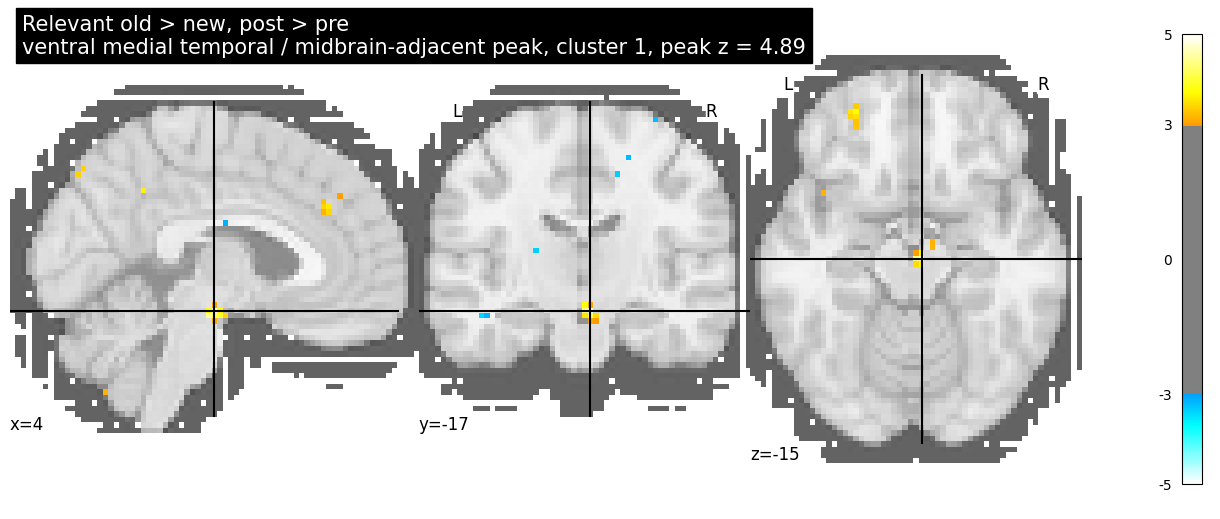

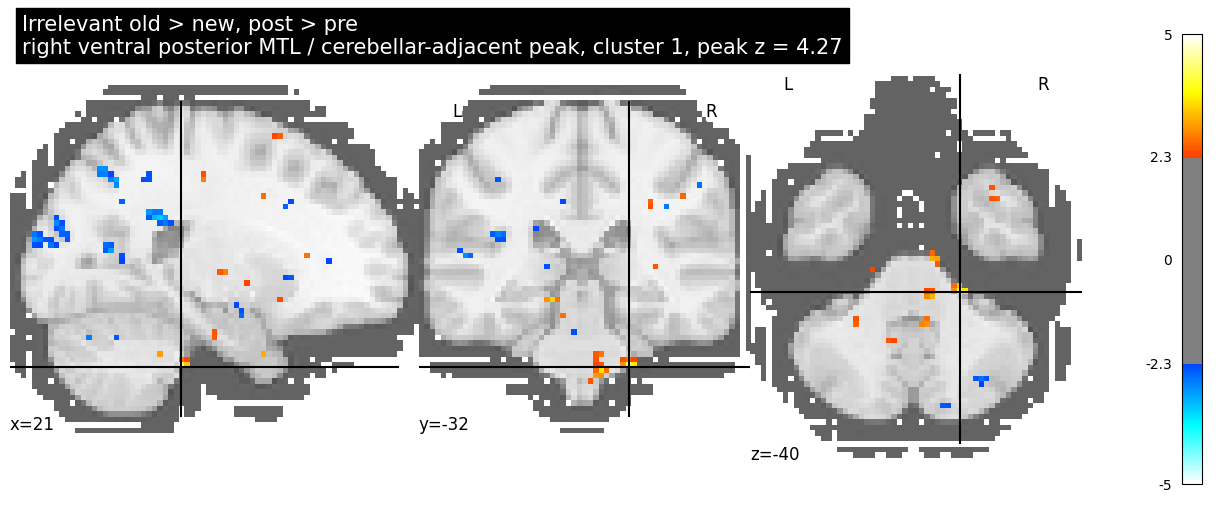

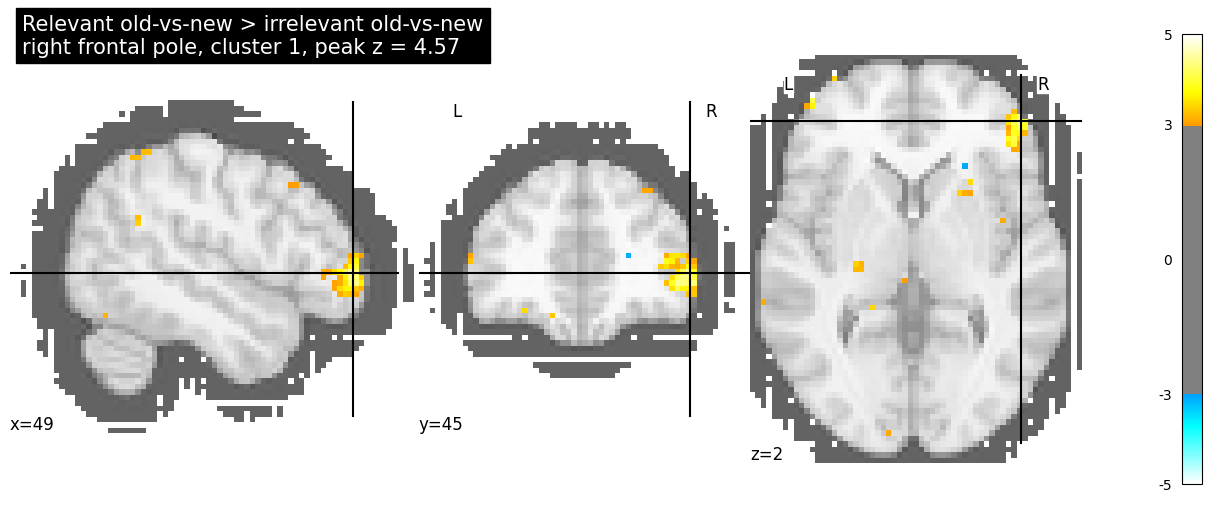

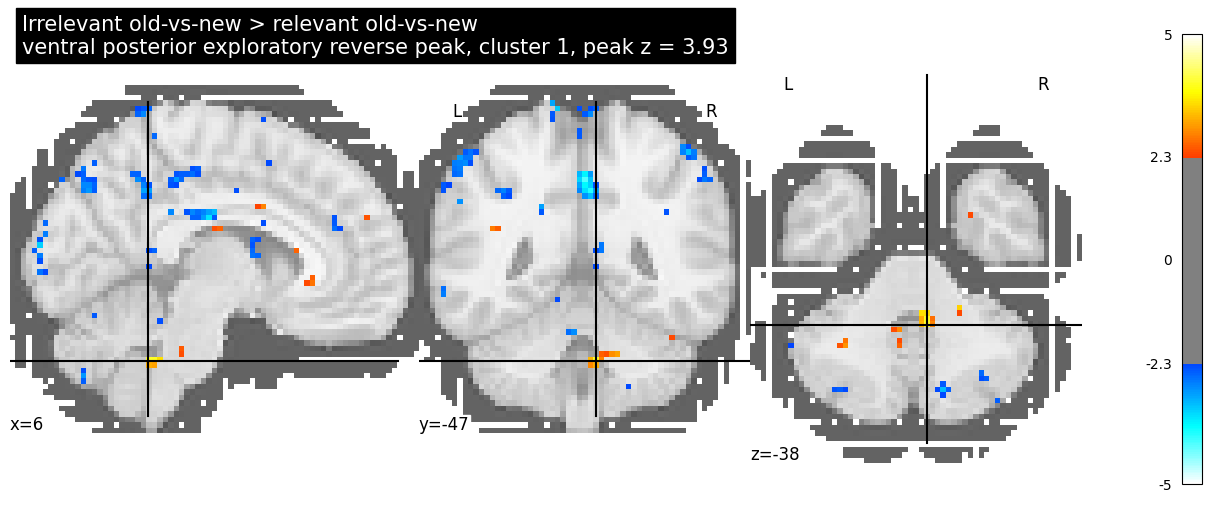

,slide_label,contrast,clean_slide_title,clean_anatomical_label,threshold_label,plot_threshold,threshold_text,cut_coords,cluster_id,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,interpretation_for_slide_notes,figure_path
0,relevant_old_vs_new_post_gt_pre,rel_old_vs_new_post_gt_pre,"Relevant old > new, post > pre",ventral medial temporal / midbrain-adjacent peak,z_gt_3.00,3.00,exploratory z > 3.00,"(4.0, -17.0, -15.5)",1,4.887609,375.0,Background,Background,Exploratory peak near ventral medial temporal ...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,irrelevant_old_vs_new_post_gt_pre,irrel_old_vs_new_post_gt_pre,"Irrelevant old > new, post > pre",right ventral posterior MTL / cerebellar-adjac...,z_gt_2.33,2.33,exploratory z > 2.33,"(21.5, -32.0, -40.5)",1,4.265341,156.0,Background,Background,Exploratory ventral posterior peak. This effec...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,relevant_gt_irrelevant_old_vs_new,rel_vs_new_gt_irrel_vs_new_post_gt_pre,Relevant old-vs-new > irrelevant old-vs-new,right frontal pole,z_gt_3.00,3.00,exploratory z > 3.00,"(49.0, 45.5, 2.0)",1,4.567430,2718.0,Frontal Pole,Right Cerebral Cortex,Main relevance-interaction peak. This is the c...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,irrelevant_gt_relevant_old_vs_new,irrel_vs_new_gt_rel_vs_new_post_gt_pre,Irrelevant old-vs-new > relevant old-vs-new,ventral posterior exploratory reverse peak,z_gt_2.33,2.33,exploratory z > 2.33,"(6.5, -47.0, -38.0)",1,3.931434,437.0,Background,Background,Secondary reverse-interaction control. The rev...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved figure index:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_relevance_old_new_viewing_glm/tables/selected_glm2_relevance_clusters_for_slides/selected_glm2_relevance_cluster_figures_clean_labels_smoothed5mm.csv


In [41]:
# ============================================================
# Plot selected GLM 2 clusters for slides using clean labels
# ============================================================

import matplotlib.pyplot as plt
from nilearn.plotting import plot_stat_map
from nilearn.datasets import load_mni152_template
from nilearn.image import resample_to_img, load_img

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

SLIDE_CLUSTER_DIR = FIG_DIR / "selected_glm2_relevance_clusters_for_slides"
SLIDE_CLUSTER_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load MNI template
# ------------------------------------------------------------

mni_template = load_mni152_template(resolution=2)

plot_rows = []

# ------------------------------------------------------------
# Plot each selected GLM 2 cluster
# ------------------------------------------------------------

for _, row in glm2_slide_labels_clean.iterrows():
    
    contrast_name = row["contrast"]
    
    # Load group-level z-map for this contrast
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    
    # Resample template to z-map space
    mni_template_resampled = resample_to_img(
        mni_template,
        z_img,
        interpolation="continuous",
        force_resample=True,
        copy_header=True,
    )
    
    # Center plot on selected peak
    cut_coords = (
        float(row["x"]),
        float(row["y"]),
        float(row["z"]),
    )
    
    # Match the figure threshold to the selected cluster table
    if row["threshold_label"] == "z_gt_3.00":
        plot_threshold = 3.0
        threshold_text = "exploratory z > 3.00"
    elif row["threshold_label"] == "z_gt_2.33":
        plot_threshold = 2.33
        threshold_text = "exploratory z > 2.33"
    else:
        raise ValueError(f"Unknown threshold label: {row['threshold_label']}")
    
    # Clean slide title
    title = (
        f"{row['clean_slide_title']}\n"
        f"{row['clean_anatomical_label']}, "
        f"cluster {row['cluster_id']}, peak z = {row['peak_z']:.2f}"
    )
    
    # Plot
    fig = plt.figure(figsize=(12, 5))
    
    display_obj = plot_stat_map(
        z_img,
        bg_img=mni_template_resampled,
        display_mode="ortho",
        cut_coords=cut_coords,
        threshold=plot_threshold,
        vmax=5.0,
        cmap="cold_hot",
        black_bg=False,
        title=title,
        figure=fig,
    )
    
    # Save figure
    safe_label = str(row["slide_label"]).replace(" ", "_")
    
    figure_path = (
        SLIDE_CLUSTER_DIR
        / f"glm2_{safe_label}_{contrast_name}_{row['threshold_label']}_{SMOOTHING_LABEL}_clean_label.png"
    )
    
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    plot_rows.append({
        "slide_label": row["slide_label"],
        "contrast": contrast_name,
        "clean_slide_title": row["clean_slide_title"],
        "clean_anatomical_label": row["clean_anatomical_label"],
        "threshold_label": row["threshold_label"],
        "plot_threshold": plot_threshold,
        "threshold_text": threshold_text,
        "cut_coords": cut_coords,
        "cluster_id": row["cluster_id"],
        "peak_z": row["peak_z"],
        "cluster_size_mm3": row["cluster_size_mm3"],
        "harvard_oxford_cortical_label": row["harvard_oxford_cortical_label"],
        "harvard_oxford_subcortical_label": row["harvard_oxford_subcortical_label"],
        "interpretation_for_slide_notes": row["interpretation_for_slide_notes"],
        "figure_path": str(figure_path),
    })

# ------------------------------------------------------------
# Save figure index table
# ------------------------------------------------------------

glm2_slide_cluster_figures_clean = pd.DataFrame(plot_rows)

glm2_slide_cluster_figures_clean_path = (
    SLIDE_CLUSTER_TABLE_DIR
    / f"selected_glm2_relevance_cluster_figures_clean_labels_{SMOOTHING_LABEL}.csv"
)

glm2_slide_cluster_figures_clean.to_csv(
    glm2_slide_cluster_figures_clean_path,
    index=False,
)

display(glm2_slide_cluster_figures_clean)

print("Saved figure index:")
print(glm2_slide_cluster_figures_clean_path)